# Figure1 

## Overlay 2D keypoint trajectories on the first frame of a time interval


In [ ]:
"""
Overlay 2D keypoint trajectories on the first frame of a time interval
for each camera/view.

Assumptions for camera CSV format (CamXXXX.csv):
- Line 0: path to skeleton JSON (with "node_names").
- Line 1+:
    frame_id, kp_id, x, y, kp_id, x, y, ...

We assume:
- frame_id corresponds to video frame index (same numbering).
- Unassigned points are stored as a large value (e.g. 1e7); we
  convert those to NaN so they don't get plotted.
"""

from pathlib import Path
import csv
import json
from typing import List, Dict, Tuple
from matplotlib.collections import LineCollection
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import cv2


# ========= CSV & skeleton loading =========

def load_skeleton_from_csv_header(csv_path: Path):
    """
    Read the first line of the CSV to get the skeleton JSON path
    and load its node_names list.

    Returns
    -------
    skel_path : Path or None
    node_names : list[str] or None
    """
    with csv_path.open("r", encoding="utf-8") as f:
        first_line = f.readline().strip()

    raw_path = first_line
    skel_path = Path(raw_path).expanduser()

    # Try relative to CSV folder if not found
    if not skel_path.is_file():
        skel_path = (csv_path.parent / raw_path).resolve()
        if not skel_path.is_file():
            print(f"[WARNING] Could not find skeleton JSON at '{raw_path}' "
                  f"or '{skel_path}'. Continuing without names.")
            return None, None

    try:
        with skel_path.open("r", encoding="utf-8") as f:
            skel = json.load(f)
        node_names = skel.get("node_names", None)
        if not isinstance(node_names, list):
            print(f"[WARNING] Skeleton {skel_path} has no 'node_names' list.")
            return skel_path, None
        return skel_path, node_names
    except Exception as e:
        print(f"[WARNING] Failed to load skeleton JSON: {e}")
        return skel_path, None


def load_keypoints2d(csv_path: Path, not_assigned_threshold: float = 1e6):
    """
    Load a 2D camera CSV into arrays.

    Parameters
    ----------
    csv_path : Path
        Path to CamXXXX.csv.
    not_assigned_threshold : float
        Any coordinate >= this is treated as "not assigned" and
        replaced with NaN.

    Returns
    -------
    frames : np.ndarray, shape (n_frames,)
        Frame indices.
    points : np.ndarray, shape (n_frames, n_keypoints, 2)
        X,Y coordinates (NaN where unassigned).
    skel_path : Path or None
    node_names : list[str] or None
    """
    skel_path, node_names = load_skeleton_from_csv_header(csv_path)

    with csv_path.open("r", encoding="utf-8") as f:
        lines = f.read().splitlines()

    if len(lines) < 2:
        raise ValueError(f"{csv_path} has no data rows (only header).")

    # Use first data row to infer number of keypoints
    first_data_row = next(csv.reader([lines[1]]))
    total_fields = len(first_data_row)

    # Expected format: frame_id, kp_id, x, y, kp_id, x, y, ...
    # => total_fields = 1 + n_keypoints * 3
    if (total_fields - 1) % 3 != 0:
        raise ValueError(
            f"Unexpected number of columns ({total_fields}) in first data row.\n"
            f"Expected: frame_id, kp, x, y, kp, x, y, ..."
        )
    n_keypoints = (total_fields - 1) // 3

    frames = []
    all_points = []

    for raw in lines[1:]:
        if not raw.strip():
            continue
        row = next(csv.reader([raw]))

        frame_id = int(row[0])
        frames.append(frame_id)

        kp_frame = np.full((n_keypoints, 2), np.nan, dtype=float)

        for i in range(n_keypoints):
            base = 1 + 3 * i
            kp_id = int(row[base])
            x = float(row[base + 1])
            y = float(row[base + 2])

            # Treat large values as "not assigned"
            if abs(x) >= not_assigned_threshold or abs(y) >= not_assigned_threshold:
                x, y = np.nan, np.nan

            if 0 <= kp_id < n_keypoints:
                kp_frame[kp_id, :] = [x, y]
            else:
                print(f"[WARNING] kp_id {kp_id} out of range in frame {frame_id}")

        all_points.append(kp_frame)

    frames = np.array(frames)
    points = np.stack(all_points, axis=0)  # (n_frames, n_keypoints, 2)

    return frames, points, skel_path, node_names


# ========= selection helpers =========

def resolve_keypoint_indices(node_names, kp_names=None) -> Tuple[List[int], List[str]]:
    """
    Resolve a list of keypoint indices from names and/or indices.

    Returns
    -------
    kp_labels : list[str]
    """
    kp_names = kp_names or []
    
    kp_idxs: List[int] = []
    labels: List[str] = []

    # Names first
    if kp_names:
        if node_names is None:
            raise ValueError("Keypoint names provided but skeleton node_names are not available.")
        for name in kp_names:
            try:
                idx = node_names.index(name)
            except ValueError:
                raise ValueError(f"Keypoint name '{name}' not found in skeleton node_names.")
            if idx not in kp_idxs:
                kp_idxs.append(idx)
                labels.append(name)

    return kp_idxs, labels


def get_frame_mask(frames: np.ndarray, frame_start: int, frame_end: int) -> np.ndarray:
    """
    Build a boolean mask for frames between frame_start and frame_end (inclusive).
    """
    mask = (frames >= frame_start) & (frames <= frame_end)
    if not np.any(mask):
        raise ValueError(
            f"No frames in the interval [{frame_start}, {frame_end}]. "
            f"Available frames are from {frames.min()} to {frames.max()}."
        )
    return mask


# ========= video helper =========

def read_frame(video_path: Path, frame_index: int):
    """
    Read a single frame from a video using OpenCV.

    Returns frame as RGB np.ndarray (H, W, 3).
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok or frame_bgr is None:
        raise RuntimeError(
            f"Could not read frame {frame_index} from video {video_path}"
        )

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frame_rgb


# ========= main overlay for one camera =========
def plot_time_gradient_trajectory(
    ax,
    x,
    y,
    *,
    label: str,
    cmap_name: str = "viridis",
    lw: float = 1.2,
    fade_tail: bool = True,
    marker_size: float = 1.5,
):
    """
    Draw a trajectory where line color reflects time progression.

    Parameters
    ----------
    x, y : lists or 1D arrays
    label : legend label
    cmap_name : matplotlib colormap name
    lw : linewidth
    fade_tail : if True, older segments fade slightly
    marker_size : size of start/end markers
    """
    # Remove NaNs first
    valid = ~np.isnan(x) & ~np.isnan(y)
    x = np.asarray(x)[valid]
    y = np.asarray(y)[valid]
    if len(x) < 2:
        return

    # Build segments
    pts = np.column_stack((x, y))
    segs = np.stack([pts[:-1], pts[1:]], axis=1)  # (N-1, 2, 2)

    # Time values 0→1
    t = np.linspace(0, 1, len(segs))
    cmap = mpl.cm.get_cmap(cmap_name)

    # Fade tail?
    if fade_tail:
        # fade from alpha=0.35 at start to alpha=1.0 at end
        alphas = 0.35 + 0.65 * t
        colors = cmap(t)
        for i, a in enumerate(alphas):
            colors[i, -1] = a  # modify alpha channel
    else:
        colors = cmap(t)

    lc = LineCollection(segs, colors=colors, linewidths=lw, capstyle='round')
    ax.add_collection(lc)

    # Start and end markers
    ax.plot(x[0],  y[0],  marker='o', ms=marker_size, color=colors[0])
    ax.plot(x[-1], y[-1], marker='o', ms=marker_size, color=colors[-1], label=label)

def plot_overlay_for_camera(
    cam_name: str,
    video_path: Path,
    csv_path: Path,
    fig_path: Path,
    frame_start: int,
    frame_end: int,
    kp_names: List[str],
    ):
    """
    For one camera/view:
      - load its 2D keypoints CSV
      - select frames in [frame_start, frame_end]
      - read frame_start from the video
      - overlay trajectories of selected keypoints on that image
        with thin, time-colored lines.
    """
    print(f"\n=== Camera: {cam_name} ===")
    print(f"Video: {video_path}")
    print(f"CSV  : {csv_path}")

    frames, points, skel_path, node_names = load_keypoints2d(csv_path)

    print(f"  Loaded {len(frames)} frames, {points.shape[1]} keypoints.")
    if skel_path is not None:
        print(f"  Skeleton: {skel_path}")

    # Resolve which keypoints to plot
    kp_idxs, kp_labels = resolve_keypoint_indices(
        node_names=node_names,
        kp_names=kp_names,
    )
    print("  Keypoints to plot:")
    for idx, label in zip(kp_idxs, kp_labels):
        print(f"    index {idx}: {label}")

    # Select frame interval
    mask = get_frame_mask(frames, frame_start, frame_end)
    interval_frames = frames[mask]
    print(f"  CSV frame interval: {interval_frames.min()}–{interval_frames.max()} "
          f"({interval_frames.size} frames).")

    # Use FRAME_START as background frame index (assuming CSV & video aligned)
    background_frame_idx = frame_start
    frame_rgb = read_frame(video_path, background_frame_idx)
    img_h, img_w = frame_rgb.shape[:2]

    # Plot background image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame_rgb, origin="upper")
    ax.set_title(f"{cam_name} | frames {frame_start}–{frame_end}")
    ax.axis("off")

    # Overlay time-colored trajectories
    for idx, label in zip(kp_idxs, kp_labels):
        xy = points[mask, idx, :]   # (n_selected_frames, 2)
        x = xy[:, 0]
        y = xy[:, 1]

        # Convert to image coordinate system (origin top-left)
        y_img = img_h - 1 - y

        # Thinner lines + time gradient
        plot_time_gradient_trajectory(
            ax,
            x,
            y_img,
            label=label,
            lw=1.2,   # thinner line
            cmap_name="viridis",  # or "viridis", "cividis", etc.
        )

    # Make axes match image size
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)

    # Legend off to the side so it doesn’t cover the fly
    ax.legend(title="Keypoints", bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(fig_path/f'{cam_name}.pdf', dpi=300)



# ========= match cameras & CSVs =========

def find_camera_pairs(video_dir: Path, csv_dir: Path) -> List[Tuple[str, Path, Path]]:
    """
    Find matching (camera_name, video_path, csv_path) triples by stem.

    E.g. Cam2012862.avi ↔ Cam2012862.csv
    """
    video_exts = {".avi", ".mp4", ".mov", ".mkv"}

    video_map: Dict[str, Path] = {}
    for p in video_dir.iterdir():
        if p.is_file() and p.suffix.lower() in video_exts:
            video_map[p.stem] = p

    csv_map: Dict[str, Path] = {}
    for p in csv_dir.iterdir():
        if p.is_file() and p.suffix.lower() == ".csv":
            csv_map[p.stem] = p

    common_stems = sorted(set(video_map.keys()) & set(csv_map.keys()))
    if not common_stems:
        print("[WARNING] No matching video/CSV pairs found.")
        return []

    pairs = [(stem, video_map[stem], csv_map[stem]) for stem in common_stems]
    return pairs


# ========= CONFIG BLOCK (edit this in VS Code) =========

if __name__ == "__main__":
    # 1) Where are your videos and 2D camera CSVs?
    VIDEO_DIR = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/")
    CSV_DIR   = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/predictions/2025_12_12_15_05_35/")
    FIG_DIR   = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/figures")
    # 2) Frame interval you want to visualize (inclusive)
    FRAME_START = 107610# e.g. 1000
    FRAME_END   = 108410 # e.g. 1300

    # 3) Keypoints to plot (by name or index).
    KP_NAMES   = ["T1L_TaTip", "T1R_TaTip"]  # e.g. ["L_fore_tarsus", "R_mid_claw"]

    # 4) Match cameras and plot
    pairs = find_camera_pairs(VIDEO_DIR, CSV_DIR)

    if not pairs:
        print("No camera/video pairs found. Check VIDEO_DIR and CSV_DIR.")
    else:
        print("Found camera pairs:")
        for cam_name, vpath, cpath in pairs:
            print(f"  {cam_name}: video={vpath.name}, csv={cpath.name}")

        for cam_name, vpath, cpath in pairs:
            plot_overlay_for_camera(
                cam_name=cam_name,
                video_path=vpath,
                csv_path=cpath,
                fig_path=FIG_DIR,
                frame_start=FRAME_START,
                frame_end=FRAME_END,
                kp_names=KP_NAMES,
                )

        plt.show()
        


## Extract same frame from different cameras


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

def read_frame(video_path: Path, frame_index: int) -> np.ndarray:
    """Read a frame (BGR→RGB) from a video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()
    cap.release()

    if not ok or frame_bgr is None:
        raise RuntimeError(
            f"Could not read frame {frame_index} from video {video_path}"
        )
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def get_video_files(video_dir: Path):
    """Return sorted list of video files."""
    video_exts = {".avi", ".mp4", ".mov", ".mkv"}
    files = [
        p for p in video_dir.iterdir()
        if p.is_file() and p.suffix.lower() in video_exts
    ]
    files.sort(key=lambda p: p.name)
    return files


def make_rainbow_colors(n: int):
    """Rainbow colormap for borders."""
    cmap = plt.get_cmap("rainbow")
    if n <= 1:
        return [cmap(0.0)]
    return [cmap(i / (n - 1)) for i in range(n)]


def export_stacked_frame(
    frame_index: int,
    video_dir: Path,
    output_path: Path,
    border_width: float = 3.0,
):
    """
    Extract the same frame from each video in folder,
    stack vertically, draw rainbow borders, save as Illustrator-compatible PDF.
    """
    video_files = get_video_files(video_dir)
    if not video_files:
        raise RuntimeError(f"No videos found in: {video_dir}")

    print("Found videos:")
    for v in video_files:
        print(" •", v.name)

    # Read frames
    frames = [read_frame(v, frame_index) for v in video_files]

    # assume size consistency
    h, w = frames[0].shape[:2]

    colors = make_rainbow_colors(len(frames))

    # determine figure size in inches
    base_width = 8
    base_height = base_width * (h / w)
    fig_height = base_height * len(frames)

    fig, axes = plt.subplots(
        len(frames), 1,
        figsize=(base_width, fig_height),
        squeeze=False
    )
    axes = axes[:, 0]

    for ax, frame, color, vpath in zip(axes, frames, colors, video_files):
        ax.imshow(frame, origin="upper")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylabel(vpath.stem, rotation=90, va="center")

        rect = Rectangle(
            (0, 0), w, h,
            linewidth=border_width,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)

    fig.suptitle(f"Frame {frame_index}", y=0.995)
    output_path.parent.mkdir(exist_ok=True, parents=True)
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("\nSaved to:", output_path)
# === USER INPUTS ===
FRAME_INDEX = 107610  # <-- change here
VIDEO_DIR   = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos")  # <-- change here
OUTPUT_PATH = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/figures.pdf")  # <-- change here

# === Run ===
export_stacked_frame(FRAME_INDEX, VIDEO_DIR, OUTPUT_PATH)


## 3D Egocentric Tarsus Tip Trajectories (mm)

In [ ]:
"""
3D Egocentric Tarsus Tip Trajectories
======================================
Visualize step cycles of all 6 legs in body-centered coordinates.
Outputs vector PDF for editing in Inkscape.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib as mpl
from pathlib import Path
import cv2

# ============================================================
# USER CONFIGURATION - EDIT THESE VALUES
# ============================================================

# Path to 3D predictions CSV
DATA_3D_PATH = Path("/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260114-145343/data3D.csv")

# Frame interval to visualize (inclusive)
FRAME_START = 107610
FRAME_END = 108410
JARVIS_SCALE = 10.0  # JARVIS outputs are 10x actual mm
# Video for background frame (optional - set to None to skip)
VIDEO_PATH = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/videos/Cam2012630.mp4")
BACKGROUND_FRAME = FRAME_START  # Which frame to use as background

# Output path for PDF
OUTPUT_DIR = Path("/mnt/lemebel/happyhouse_102025/session6/2025_10_12_15_06_46/figures")
OUTPUT_FILENAME = "egocentric_tarsus_trajectories.pdf"

# Visualization options
SHOW_BACKGROUND_IMAGE = True  # Set False for cleaner vector output
LINE_WIDTH = 1.5
COLORMAP = "viridis"  # Options: "viridis", "plasma", "coolwarm", "rainbow"
FADE_TAIL = True  # Fade older parts of trajectory

print("Configuration loaded.")

In [ ]:
# ============================================================
# DATA LOADING AND PROCESSING FUNCTIONS
# ============================================================

def load_3d_data(csv_path: Path, frame_start: int, frame_end: int):
    """
    Load 3D keypoint data from JARVIS CSV format.
    """
    print(f"Loading 3D data from {csv_path}...")
    print(f"  Frame range: {frame_start} to {frame_end}")
    
    # Read header to get keypoint names
    header_df = pd.read_csv(csv_path, nrows=0)
    all_cols = header_df.columns.tolist()
    
    # Get unique keypoint names (each appears 4 times: x, y, z, confidence)
    keypoint_names = []
    for i in range(0, len(all_cols), 4):
        keypoint_names.append(all_cols[i])
    
    print(f"  Found {len(keypoint_names)} keypoints")
    
    # Load only the rows we need (skip header rows, then select frame range)
    df = pd.read_csv(csv_path, skiprows=[1], nrows=frame_end + 1)
    df = df.iloc[frame_start:frame_end + 1].reset_index(drop=True)
    
    print(f"  Loaded {len(df)} frames")
    return df, keypoint_names


def extract_keypoint_xyz(df, keypoint_name):
    """Extract x, y, z coordinates for a specific keypoint."""
    cols = df.columns.tolist()
    
    try:
        start_idx = cols.index(keypoint_name)
    except ValueError:
        raise ValueError(f"Keypoint '{keypoint_name}' not found in data")
    
    x = df.iloc[:, start_idx].values.astype(float)/JARVIS_SCALE
    y = df.iloc[:, start_idx + 1].values.astype(float)/JARVIS_SCALE
    z = df.iloc[:, start_idx + 2].values.astype(float)/JARVIS_SCALE

    return np.column_stack([x, y, z])


def compute_egocentric_transform(thorax_pos, head_pos, abd_pos):
    """
    Compute transformation to egocentric (body-centered) coordinates.
    """
    N = thorax_pos.shape[0]
    
    # Body axis: from abdomen to head (forward direction)
    forward = head_pos - abd_pos
    forward = forward / (np.linalg.norm(forward, axis=1, keepdims=True) + 1e-10)
    
    # Up direction (approximate - we'll use world Z and orthogonalize)
    world_up = np.array([0, 0, 1])
    
    # Right vector = forward × up
    right = np.cross(forward, world_up)
    right = right / (np.linalg.norm(right, axis=1, keepdims=True) + 1e-10)
    
    # Recompute up to be orthogonal
    up = np.cross(right, forward)
    up = up / (np.linalg.norm(up, axis=1, keepdims=True) + 1e-10)
    
    # Build rotation matrices (columns are right, forward, up in body frame)
    R = np.zeros((N, 3, 3))
    R[:, :, 0] = right      # X-axis (right)
    R[:, :, 1] = forward    # Y-axis (forward)  
    R[:, :, 2] = up         # Z-axis (up)
    
    return R, thorax_pos


def transform_to_egocentric(points, R, origin):
    """Transform points to egocentric coordinates."""
    centered = points - origin
    ego_points = np.einsum('nij,nj->ni', R.transpose(0, 2, 1), centered)
    return ego_points


def read_video_frame(video_path: Path, frame_index: int):
    """Read a single frame from video."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()
    cap.release()
    
    if not ok or frame_bgr is None:
        raise RuntimeError(f"Could not read frame {frame_index}")
    
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


def compute_velocity(xyz, fps=800):
    """
    Compute instantaneous velocity from position data.
    
    Args:
        xyz: (N, 3) array of positions
        fps: frame rate in Hz
        
    Returns:
        velocity: (N, 3) velocity vectors (first frame = 0)
        speed: (N,) magnitude of velocity
    """
    velocity = np.zeros_like(xyz)
    velocity[1:] = (xyz[1:] - xyz[:-1]) * fps  # mm/s or BL/s depending on input
    speed = np.linalg.norm(velocity, axis=1)
    return velocity, speed


def plot_3d_trajectory_gradient(ax, xyz, label, cmap_name="viridis", lw=1.5, 
                                 fade_tail=True, color_override=None):
    """Plot a 3D trajectory with time-gradient coloring."""
    valid = ~np.any(np.isnan(xyz), axis=1)
    xyz = xyz[valid]
    
    if len(xyz) < 2:
        return
    
    points = xyz.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    t = np.linspace(0, 1, len(segments))
    
    if color_override is not None:
        colors = np.zeros((len(segments), 4))
        colors[:, :3] = mpl.colors.to_rgb(color_override)
        if fade_tail:
            colors[:, 3] = 0.3 + 0.7 * t
        else:
            colors[:, 3] = 1.0
    else:
        cmap = mpl.cm.get_cmap(cmap_name)
        colors = cmap(t)
        if fade_tail:
            colors[:, 3] = 0.3 + 0.7 * t
    
    lc = Line3DCollection(segments, colors=colors, linewidths=lw)
    ax.add_collection3d(lc)
    
    ax.scatter(*xyz[0], s=20, c=[colors[0]], marker='o', edgecolors='k', linewidths=0.5)
    ax.scatter(*xyz[-1], s=30, c=[colors[-1]], marker='o', edgecolors='k', linewidths=0.5, label=label)


def create_multi_view_figure(ego_trajectories, leg_names, leg_colors,
                             output_path, frame_rgb=None, 
                             title="Egocentric Tarsus Tip Trajectories",
                             cmap_name="viridis", lw=1.5, fade_tail=True):
    """Create a multi-panel figure with 3D view and 2D projections."""
    if frame_rgb is not None:
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], height_ratios=[1, 1])
        
        ax_img = fig.add_subplot(gs[0, 0])
        ax_img.imshow(frame_rgb)
        ax_img.set_title("Reference Frame", fontsize=11)
        ax_img.axis('off')
        
        ax_3d = fig.add_subplot(gs[0, 1:], projection='3d')
        ax_xy = fig.add_subplot(gs[1, 0])
        ax_xz = fig.add_subplot(gs[1, 1])
        ax_yz = fig.add_subplot(gs[1, 2])
    else:
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], height_ratios=[1.2, 1])
        
        ax_3d = fig.add_subplot(gs[0, :], projection='3d')
        ax_xy = fig.add_subplot(gs[1, 0])
        ax_xz = fig.add_subplot(gs[1, 1])
        ax_yz = fig.add_subplot(gs[1, 2])
    
    # Plot 3D trajectories
    for traj, name, color in zip(ego_trajectories, leg_names, leg_colors):
        plot_3d_trajectory_gradient(ax_3d, traj, name, cmap_name=cmap_name,
                                    lw=lw, fade_tail=fade_tail, color_override=color)
    
    ax_3d.set_xlabel('Right-Left (mm)')
    ax_3d.set_ylabel('Anterior-Posterior (mm)')
    ax_3d.set_zlabel('Dorsal-Ventral (mm)')
    ax_3d.set_title(title, fontsize=12, fontweight='bold')
    ax_3d.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    
    # 2D projections
    for traj, name, color in zip(ego_trajectories, leg_names, leg_colors):
        valid = ~np.any(np.isnan(traj), axis=1)
        t = traj[valid]
        if len(t) < 2:
            continue
        
        for ax, xi, yi, xlabel, ylabel, proj_title in [
            (ax_xy, 0, 1, 'Right-Left', 'Anterior-Posterior', 'Top View (X-Y)'),
            (ax_xz, 0, 2, 'Right-Left', 'Dorsal-Ventral', 'Side View (X-Z)'),
            (ax_yz, 1, 2, 'Anterior-Posterior', 'Dorsal-Ventral', 'Front View (Y-Z)')
        ]:
            pts = np.column_stack([t[:, xi], t[:, yi]])
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            
            time_vals = np.linspace(0, 1, len(segments))
            colors = np.zeros((len(segments), 4))
            colors[:, :3] = mpl.colors.to_rgb(color)
            colors[:, 3] = 0.3 + 0.7 * time_vals if fade_tail else 1.0
            
            lc = LineCollection(segments, colors=colors, linewidths=lw)
            ax.add_collection(lc)
            ax.autoscale()
            ax.set_xlabel(xlabel, fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_title(proj_title, fontsize=11)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
    
    # Equal axis limits
    all_points = np.vstack([t[~np.any(np.isnan(t), axis=1)] for t in ego_trajectories])
    max_range = np.max(np.ptp(all_points, axis=0)) / 2 * 1.1
    mid = np.mean(all_points, axis=0)
    
    ax_3d.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_3d.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_3d.set_zlim(mid[2] - max_range, mid[2] + max_range)
    
    ax_xy.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xy.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_xz.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    ax_yz.set_xlim(mid[1] - max_range, mid[1] + max_range)
    ax_yz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    
    plt.tight_layout()
    return fig

print("Functions loaded.")

In [ ]:
# ============================================================
# MAIN EXECUTION - Generate the figure
# ============================================================

# Tarsus tip keypoint names
TARSUS_TIP_NAMES = [
    "T1L_TaTip",  # Front left
    "T1R_TaTip",  # Front right
    "T2L_TaTip",  # Middle left
    "T2R_TaTip",  # Middle right
    "T3L_TaTip",  # Hind left
    "T3R_TaTip",  # Hind right
]

LEG_DISPLAY_NAMES = [
    "Front Left (T1L)",
    "Front Right (T1R)", 
    "Middle Left (T2L)",
    "Middle Right (T2R)",
    "Hind Left (T3L)",
    "Hind Right (T3R)",
]

LEG_COLORS = [
    "#E63946",  # T1L - red
    "#457B9D",  # T1R - blue
    "#F4A261",  # T2L - orange
    "#2A9D8F",  # T2R - teal
    "#9B2226",  # T3L - dark red
    "#1D3557",  # T3R - dark blue
]

THORAX_KP = "Scutellum"
HEAD_KP = "Antenna_Base"
ABDOMEN_KP = "Abd_tip"

# Load 3D data
df, keypoint_names = load_3d_data(DATA_3D_PATH, FRAME_START, FRAME_END)

print(f"\nAvailable keypoints: {keypoint_names[:10]}... ({len(keypoint_names)} total)")

In [ ]:
# Extract body reference positions
thorax_pos = extract_keypoint_xyz(df, THORAX_KP)
head_pos = extract_keypoint_xyz(df, HEAD_KP)
abd_pos = extract_keypoint_xyz(df, ABDOMEN_KP)

print(f"Computing egocentric transformation...")
R, origin = compute_egocentric_transform(thorax_pos, head_pos, abd_pos)

# Extract and transform tarsus tip trajectories
ego_trajectories = []
for kp_name in TARSUS_TIP_NAMES:
    world_pos = extract_keypoint_xyz(df, kp_name)
    ego_pos = transform_to_egocentric(world_pos, R, origin)
    ego_trajectories.append(ego_pos)
    print(f"  {kp_name}: {ego_pos.shape[0]} frames, range: "
          f"X[{ego_pos[:,0].min():.1f}, {ego_pos[:,0].max():.1f}] "
          f"Y[{ego_pos[:,1].min():.1f}, {ego_pos[:,1].max():.1f}] "
          f"Z[{ego_pos[:,2].min():.1f}, {ego_pos[:,2].max():.1f}]")

In [ ]:
# Load background frame if requested
frame_rgb = None
if SHOW_BACKGROUND_IMAGE and VIDEO_PATH is not None:
    try:
        frame_rgb = read_video_frame(VIDEO_PATH, BACKGROUND_FRAME)
        print(f"Loaded background frame {BACKGROUND_FRAME} from {VIDEO_PATH.name}")
    except Exception as e:
        print(f"Warning: Could not load video frame: {e}")
        frame_rgb = None

# Create the figure
print(f"Generating figure...")
title = f"Egocentric Tarsus Trajectories (Frames {FRAME_START}-{FRAME_END})"

fig = create_multi_view_figure(
    ego_trajectories, 
    LEG_DISPLAY_NAMES, 
    LEG_COLORS,
    OUTPUT_DIR / OUTPUT_FILENAME,
    frame_rgb=frame_rgb,
    title=title,
    cmap_name=COLORMAP,
    lw=LINE_WIDTH,
    fade_tail=FADE_TAIL
)

# Save as vector PDF
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUTPUT_DIR / OUTPUT_FILENAME

fig.savefig(
    output_path, 
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    metadata={'Creator': 'Matplotlib', 'Title': title}
)

print(f"\n✅ Saved vector PDF to: {output_path}")
print("   Open in Inkscape to edit line styles, colors, and layout.")

plt.show()

## 3D Egocentric Tarsus Tip Trajectories (bl)

In [ ]:
# Calculate body length (distance from Abd_tip to Antenna_Base)
body_lengths = np.linalg.norm(head_pos - abd_pos, axis=1)
BODY_LENGTH = np.mean(body_lengths)
body_length_std = np.std(body_lengths)

print(f"Body length calculation:")
print(f"  Mean: {BODY_LENGTH:.2f} (raw units)")
print(f"  Std:  {body_length_std:.2f}")
print(f"  Range: [{body_lengths.min():.2f}, {body_lengths.max():.2f}]")

# Normalize trajectories by body length
ego_trajectories_bl = [traj / BODY_LENGTH for traj in ego_trajectories]

print(f"\nNormalized trajectory ranges (in BL):")
for kp_name, traj_bl in zip(TARSUS_TIP_NAMES, ego_trajectories_bl):
    print(f"  {kp_name}: "
          f"X[{traj_bl[:,0].min():.2f}, {traj_bl[:,0].max():.2f}] "
          f"Y[{traj_bl[:,1].min():.2f}, {traj_bl[:,1].max():.2f}] "
          f"Z[{traj_bl[:,2].min():.2f}, {traj_bl[:,2].max():.2f}] BL")

In [ ]:
# Create updated figure with BL units
def create_multi_view_figure_bl(ego_trajectories, leg_names, leg_colors,
                                frame_rgb=None, title="Egocentric Tarsus Tip Trajectories",
                                cmap_name="viridis", lw=1.5, fade_tail=True,
                                units="BL"):
    """
    Create a multi-panel figure with 3D view and 2D projections.
    Units parameter controls axis labels (default: BL for body length).
    """
    if frame_rgb is not None:
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], height_ratios=[1, 1])
        
        ax_img = fig.add_subplot(gs[0, 0])
        ax_img.imshow(frame_rgb)
        ax_img.set_title("Reference Frame", fontsize=11)
        ax_img.axis('off')
        
        ax_3d = fig.add_subplot(gs[0, 1:], projection='3d')
        ax_xy = fig.add_subplot(gs[1, 0])
        ax_xz = fig.add_subplot(gs[1, 1])
        ax_yz = fig.add_subplot(gs[1, 2])
    else:
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 3, width_ratios=[1.2, 1, 1], height_ratios=[1.2, 1])
        
        ax_3d = fig.add_subplot(gs[0, :], projection='3d')
        ax_xy = fig.add_subplot(gs[1, 0])
        ax_xz = fig.add_subplot(gs[1, 1])
        ax_yz = fig.add_subplot(gs[1, 2])
    
    # Plot 3D trajectories
    for traj, name, color in zip(ego_trajectories, leg_names, leg_colors):
        plot_3d_trajectory_gradient(ax_3d, traj, name, cmap_name=cmap_name,
                                    lw=lw, fade_tail=fade_tail, color_override=color)
    
    # Updated axis labels with units parameter
    ax_3d.set_xlabel(f'Right-Left ({units})')
    ax_3d.set_ylabel(f'Anterior-Posterior ({units})')
    ax_3d.set_zlabel(f'Dorsal-Ventral ({units})')
    ax_3d.set_title(title, fontsize=12, fontweight='bold')
    ax_3d.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    
    # 2D projections with time gradient
    for traj, name, color in zip(ego_trajectories, leg_names, leg_colors):
        valid = ~np.any(np.isnan(traj), axis=1)
        t = traj[valid]
        if len(t) < 2:
            continue
        
        for ax, xi, yi, xlabel, ylabel, proj_title in [
            (ax_xy, 0, 1, f'Right-Left ({units})', f'Anterior-Posterior ({units})', 'Top View (X-Y)'),
            (ax_xz, 0, 2, f'Right-Left ({units})', f'Dorsal-Ventral ({units})', 'Side View (X-Z)'),
            (ax_yz, 1, 2, f'Anterior-Posterior ({units})', f'Dorsal-Ventral ({units})', 'Front View (Y-Z)')
        ]:
            pts = np.column_stack([t[:, xi], t[:, yi]])
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            
            time_vals = np.linspace(0, 1, len(segments))
            colors = np.zeros((len(segments), 4))
            colors[:, :3] = mpl.colors.to_rgb(color)
            colors[:, 3] = 0.3 + 0.7 * time_vals if fade_tail else 1.0
            
            lc = LineCollection(segments, colors=colors, linewidths=lw)
            ax.add_collection(lc)
            ax.autoscale()
            ax.set_xlabel(xlabel, fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_title(proj_title, fontsize=11)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.3)
    
    # Equal axis limits
    all_points = np.vstack([t[~np.any(np.isnan(t), axis=1)] for t in ego_trajectories])
    max_range = np.max(np.ptp(all_points, axis=0)) / 2 * 1.1
    mid = np.mean(all_points, axis=0)
    
    ax_3d.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_3d.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_3d.set_zlim(mid[2] - max_range, mid[2] + max_range)
    
    ax_xy.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xy.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_xz.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    ax_yz.set_xlim(mid[1] - max_range, mid[1] + max_range)
    ax_yz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    
    plt.tight_layout()
    return fig

# Generate the figure with BL-normalized data
title_bl = f"Egocentric Tarsus Trajectories (Frames {FRAME_START}-{FRAME_END}, BL = {BODY_LENGTH:.1f})"

fig_bl = create_multi_view_figure_bl(
    ego_trajectories_bl,  # Use normalized trajectories
    LEG_DISPLAY_NAMES, 
    LEG_COLORS,
    frame_rgb=frame_rgb,
    title=title_bl,
    cmap_name=COLORMAP,
    lw=LINE_WIDTH,
    fade_tail=FADE_TAIL,
    units="BL"
)

# Save as vector PDF
output_path_bl = OUTPUT_DIR / "egocentric_tarsus_trajectories_BL.pdf"

fig_bl.savefig(
    output_path_bl, 
    format='pdf',
    dpi=300,
    bbox_inches='tight',
    metadata={'Creator': 'Matplotlib', 'Title': title_bl}
)

print(f"\n✅ Saved normalized figure to: {output_path_bl}")
print(f"   Body length: {BODY_LENGTH:.2f} raw units")
print("   All axes now in body length (BL) units")

plt.show()

## Trajectory + vel visualization


In [ ]:
# ============================================================
# TRAJECTORY + VELOCITY VISUALIZATION
# ============================================================

def create_trajectory_velocity_figure(
    ego_trajectories,
    velocities,
    speeds,
    leg_names,
    leg_colors,
    fps=800,
    arrow_every=50,
    arrow_scale=0.1,
    speed_cmap='plasma',
    frame_rgb=None,
    title="Trajectory with Velocity",
    units="mm",
    lw=1.5
):
    """
    Create multi-panel figure with trajectories colored by speed and velocity arrows.
    
    Layout (2 rows x 4 cols):
    [ 3D Trajectory (speed colormap) ][ Top View (X-Y) ][ Side View (X-Z) ][ Speed vs Time ]
    [        Reference Frame         ][ Front View (Y-Z) with velocity arrows             ]
    
    Args:
        ego_trajectories: list of (N, 3) position arrays
        velocities: list of (N, 3) velocity arrays
        speeds: list of (N,) speed arrays
        leg_names: list of names for legend
        leg_colors: list of colors for each trajectory
        fps: frame rate in Hz
        arrow_every: show velocity arrow every N frames
        arrow_scale: scale factor for arrow length
        speed_cmap: colormap for speed coloring
        frame_rgb: optional reference frame image
        title: figure title
        units: units string for axis labels (e.g., "mm" or "BL")
        lw: line width
        
    Returns:
        fig: matplotlib Figure object
    """
    # Compute global speed range for consistent colormap
    all_speeds = np.concatenate([s[~np.isnan(s)] for s in speeds])
    vmin, vmax = np.percentile(all_speeds, [2, 98])  # Use percentiles to avoid outliers
    
    # Create figure with 2x4 layout
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, width_ratios=[1.2, 1, 1, 1], height_ratios=[1, 1],
                          hspace=0.25, wspace=0.3)
    
    # Row 1: 3D trajectory, Top view, Side view, Speed plot
    ax_3d = fig.add_subplot(gs[0, 0], projection='3d')
    ax_xy = fig.add_subplot(gs[0, 1])
    ax_xz = fig.add_subplot(gs[0, 2])
    ax_speed = fig.add_subplot(gs[0, 3])
    
    # Row 2: Reference frame (or empty), Front view with arrows spanning 3 cols
    if frame_rgb is not None:
        ax_img = fig.add_subplot(gs[1, 0])
        ax_img.imshow(frame_rgb)
        ax_img.set_title("Reference Frame", fontsize=11)
        ax_img.axis('off')
    else:
        ax_img = fig.add_subplot(gs[1, 0])
        ax_img.axis('off')
    
    ax_yz = fig.add_subplot(gs[1, 1:])  # Front view spans remaining columns
    
    cmap = plt.cm.get_cmap(speed_cmap)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    # Plot each trajectory
    for traj, vel, spd, name, base_color in zip(ego_trajectories, velocities, speeds, 
                                                 leg_names, leg_colors):
        valid = ~np.any(np.isnan(traj), axis=1)
        traj_v = traj[valid]
        vel_v = vel[valid]
        spd_v = spd[valid]
        
        if len(traj_v) < 2:
            continue
        
        # --- 3D trajectory colored by speed ---
        points_3d = traj_v.reshape(-1, 1, 3)
        segments_3d = np.concatenate([points_3d[:-1], points_3d[1:]], axis=1)
        colors_3d = cmap(norm(spd_v[:-1]))
        lc_3d = Line3DCollection(segments_3d, colors=colors_3d, linewidths=lw)
        ax_3d.add_collection3d(lc_3d)
        
        # Start/end markers
        ax_3d.scatter(*traj_v[0], s=30, c='green', marker='o', edgecolors='k', 
                      linewidths=0.5, zorder=10)
        ax_3d.scatter(*traj_v[-1], s=30, c='red', marker='s', edgecolors='k', 
                      linewidths=0.5, zorder=10, label=name)
        
        # --- 2D projections colored by speed ---
        for ax, xi, yi in [(ax_xy, 0, 1), (ax_xz, 0, 2), (ax_yz, 1, 2)]:
            pts_2d = np.column_stack([traj_v[:, xi], traj_v[:, yi]])
            segs_2d = np.stack([pts_2d[:-1], pts_2d[1:]], axis=1)
            colors_2d = cmap(norm(spd_v[:-1]))
            lc_2d = LineCollection(segs_2d, colors=colors_2d, linewidths=lw)
            ax.add_collection(lc_2d)
        
        # --- Velocity arrows on Front view (Y-Z) ---
        arrow_indices = np.arange(0, len(traj_v), arrow_every)
        for idx in arrow_indices:
            if idx < len(vel_v):
                # Y-Z projection of velocity
                y, z = traj_v[idx, 1], traj_v[idx, 2]
                vy, vz = vel_v[idx, 1] * arrow_scale, vel_v[idx, 2] * arrow_scale
                if np.linalg.norm([vy, vz]) > 1e-6:  # Skip near-zero velocities
                    ax_yz.arrow(y, z, vy, vz, head_width=0.02, head_length=0.01,
                               fc=base_color, ec=base_color, alpha=0.7, zorder=5)
        
        # --- Speed vs Time plot ---
        time_s = np.arange(len(spd_v)) / fps
        ax_speed.plot(time_s, spd_v, color=base_color, lw=1.0, alpha=0.8, label=name)
    
    # Configure 3D axis
    ax_3d.set_xlabel(f'Right-Left ({units})', fontsize=9)
    ax_3d.set_ylabel(f'Anterior-Posterior ({units})', fontsize=9)
    ax_3d.set_zlabel(f'Dorsal-Ventral ({units})', fontsize=9)
    ax_3d.set_title("3D Trajectory (colored by speed)", fontsize=11, fontweight='bold')
    
    # Set equal axis limits for 3D
    all_points = np.vstack([t[~np.any(np.isnan(t), axis=1)] for t in ego_trajectories])
    max_range = np.max(np.ptp(all_points, axis=0)) / 2 * 1.1
    mid = np.mean(all_points, axis=0)
    ax_3d.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_3d.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_3d.set_zlim(mid[2] - max_range, mid[2] + max_range)
    
    # Configure 2D projection axes
    proj_configs = [
        (ax_xy, 0, 1, f'Right-Left ({units})', f'Anterior-Posterior ({units})', 'Top View (X-Y)'),
        (ax_xz, 0, 2, f'Right-Left ({units})', f'Dorsal-Ventral ({units})', 'Side View (X-Z)'),
        (ax_yz, 1, 2, f'Anterior-Posterior ({units})', f'Dorsal-Ventral ({units})', 
         'Front View (Y-Z) + Velocity Arrows')
    ]
    
    for ax, xi, yi, xlabel, ylabel, ax_title in proj_configs:
        ax.autoscale()
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(ax_title, fontsize=11)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    # Set equal limits for 2D projections
    ax_xy.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xy.set_ylim(mid[1] - max_range, mid[1] + max_range)
    ax_xz.set_xlim(mid[0] - max_range, mid[0] + max_range)
    ax_xz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    ax_yz.set_xlim(mid[1] - max_range, mid[1] + max_range)
    ax_yz.set_ylim(mid[2] - max_range, mid[2] + max_range)
    
    # Configure speed plot
    ax_speed.set_xlabel('Time (s)', fontsize=9)
    speed_unit = f'{units}/s' if units != 'BL' else 'BL/s'
    ax_speed.set_ylabel(f'Speed ({speed_unit})', fontsize=9)
    ax_speed.set_title('Instantaneous Speed', fontsize=11)
    ax_speed.legend(fontsize=8, loc='upper right')
    ax_speed.grid(True, alpha=0.3)
    ax_speed.set_xlim(0, None)
    ax_speed.set_ylim(0, None)
    
    # Add colorbar for speed
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_3d, ax_xy, ax_xz], shrink=0.6, pad=0.02, 
                        location='right', aspect=30)
    cbar.set_label(f'Speed ({speed_unit})', fontsize=9)
    
    # Overall title
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


print("Trajectory + velocity visualization function loaded.")

In [ ]:
# --- USER CONFIGURATION ---
# Select leg pairs to plot (contralateral pairs)
leg_pairs = [
    ("T1L_TaTip", "T1R_TaTip"),  # Front legs
    ("T2L_TaTip", "T2R_TaTip"),  # Mid legs
    ("T3L_TaTip", "T3R_TaTip"),  # Hind legs
]

# Frame range to PLOT (relative to loaded data, or absolute frame numbers)
# Set to None to use full loaded range
PLOT_FRAME_START = None  # e.g., 107600 for absolute, or None for start of loaded data
PLOT_FRAME_END = None    # e.g., 108400 for absolute, or None for end of loaded data

# JARVIS scale factor (JARVIS outputs are 10x actual mm)
JARVIS_SCALE = 10.0

# Frame rate for velocity computation
FPS = 800

# Colors: left = warm, right = cool
COLORS = {
    "T1L_TaTip": "#E63946",  "T1R_TaTip": "#457B9D",
    "T2L_TaTip": "#F4A261",  "T2R_TaTip": "#2A9D8F", 
    "T3L_TaTip": "#9B2226",  "T3R_TaTip": "#1D3557",
}

PAIR_LABELS = ["T1 (Front)", "T2 (Mid)", "T3 (Hind)"]
# --------------------------

# Extract data for all legs (full loaded range)
leg_data = {}
for left, right in leg_pairs:
    for kp in [left, right]:
        if kp not in keypoint_names:
            print(f"Warning: '{kp}' not found, skipping.")
            continue
        pos = extract_keypoint_xyz(df, kp) / JARVIS_SCALE
        vel, spd = compute_velocity(pos, fps=FPS)
        acc = np.zeros_like(vel)
        acc[1:] = (vel[1:] - vel[:-1]) * FPS  # mm/s^2
        acc_z = acc[:, 2]
        leg_data[kp] = {'pos': pos, 'vel': vel, 'spd': spd, 'acc': acc, 'acc_z': acc_z}

# Compute frame indices for plotting
n_frames_total = list(leg_data.values())[0]['pos'].shape[0]
all_frames = np.arange(FRAME_START, FRAME_START + n_frames_total)

# Determine plot range (convert absolute frame numbers to indices)
if PLOT_FRAME_START is None:
    plot_start_idx = 0
else:
    plot_start_idx = max(0, PLOT_FRAME_START - FRAME_START)

if PLOT_FRAME_END is None:
    plot_end_idx = n_frames_total
else:
    plot_end_idx = min(n_frames_total, PLOT_FRAME_END - FRAME_START)

# Slice for plotting
plot_slice = slice(plot_start_idx, plot_end_idx)
frames = all_frames[plot_slice]

print(f"Loaded data: frames {FRAME_START} to {FRAME_START + n_frames_total - 1}")
print(f"Plotting: frames {frames[0]} to {frames[-1]} ({len(frames)} frames)")

# ============================================================
# FIGURE: Z trajectories + Speed + Acceleration, both by pairs
# ============================================================
fig, axes = plt.subplots(9, 1, figsize=(14, 18), sharex=True)

# Plot Z, Speed, Acceleration for each leg pair
for i, ((left, right), label) in enumerate(zip(leg_pairs, PAIR_LABELS)):
    ax_z = axes[i]
    ax_spd = axes[i + 3]
    ax_acc = axes[i + 6]
    
    # Z trajectory (sliced to plot range)
    if left in leg_data:
        ax_z.plot(frames, leg_data[left]['pos'][plot_slice, 2], 
                  color=COLORS[left], lw=1.2, alpha=0.9, label='Left')
    if right in leg_data:
        ax_z.plot(frames, leg_data[right]['pos'][plot_slice, 2], 
                  color=COLORS[right], lw=1.2, alpha=0.9, label='Right')
    
    ax_z.set_ylabel(f'{label} Z (mm)', fontsize=10)
    ax_z.legend(loc='upper right', fontsize=9, ncol=2)
    ax_z.grid(True, alpha=0.3)
    
    # Speed (sliced to plot range)
    if left in leg_data:
        ax_spd.plot(frames, leg_data[left]['spd'][plot_slice], 
                    color=COLORS[left], lw=1.0, alpha=0.8, label='Left')
    if right in leg_data:
        ax_spd.plot(frames, leg_data[right]['spd'][plot_slice], 
                    color=COLORS[right], lw=1.0, alpha=0.8, label='Right')
    
    ax_spd.set_ylabel(f'{label} Speed (mm/s)', fontsize=10)
    ax_spd.legend(loc='upper right', fontsize=9, ncol=2)
    ax_spd.grid(True, alpha=0.3)
    ax_spd.set_ylim(0, None)

    # Acceleration (sliced to plot range)
    if left in leg_data:
        ax_acc.plot(frames, leg_data[left]['acc_z'][plot_slice], 
                    color=COLORS[left], lw=1.0, alpha=0.8, label='Left')
    if right in leg_data:
        ax_acc.plot(frames, leg_data[right]['acc_z'][plot_slice], 
                    color=COLORS[right], lw=1.0, alpha=0.8, label='Right')

    ax_acc.set_ylabel(f'{label} Accel (mm/s^2)', fontsize=10)
    ax_acc.legend(loc='upper right', fontsize=9, ncol=2)
    ax_acc.grid(True, alpha=0.3)
    ax_acc.set_ylim(0, None)

axes[0].set_title(f"Tarsus Tip Z Trajectories (Frames {frames[0]}-{frames[-1]})", 
                  fontsize=13, fontweight='bold')
axes[3].set_title('Instantaneous Speed by Leg Pair', fontsize=13, fontweight='bold')
axes[6].set_title('Instantaneous Acceleration by Leg Pair', fontsize=13, fontweight='bold')
axes[8].set_xlabel('Frame', fontsize=11)

plt.tight_layout()

# Save
output_path = OUTPUT_DIR / "z_trajectory_speed_by_pair.pdf"
fig.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Saved to: {output_path}")

plt.show()


## PHASE DETECTION: Velocity Threshold Method (Pratt et al. 2024)

In [ ]:
# ============================================================
# PHASE DETECTION: Velocity Threshold Method (Pratt et al. 2024)
# ============================================================
# Method: velocity > threshold = SWING, velocity < threshold = STANCE
# Reference: https://github.com/Prattbuw/Treadmill_Paper

from scipy.ndimage import gaussian_filter1d

# --- CONFIGURATION ---
VELOCITY_THRESHOLD = 25  # mm/s - adjust based on your data (Pratt uses 5-15)
GAUSSIAN_SIGMA = 1.5     # Smoothing parameter
# ---------------------

def detect_swing_stance(speed, threshold=25, sigma=1.5):
    """
    Detect swing/stance phases using velocity threshold.
    
    Args:
        speed: (N,) array of speed values (mm/s)
        threshold: velocity threshold - above = swing, below = stance
        sigma: Gaussian smoothing parameter
        
    Returns:
        phase: (N,) array - 1 = swing, 0 = stance
        smoothed_speed: (N,) smoothed speed values
    """
    # Smooth the speed signal
    smoothed = gaussian_filter1d(speed, sigma)
    
    # Threshold: swing = 1, stance = 0
    phase = (smoothed > threshold).astype(int)
    
    return phase, smoothed


def detect_phase_transitions(phase):
    """
    Find swing onset and stance onset frames.
    
    Returns:
        swing_onsets: frames where stance -> swing (foot up)
        stance_onsets: frames where swing -> stance (foot down)
    """
    diff = np.diff(phase)
    swing_onsets = np.where(diff == 1)[0] + 1   # 0->1 transition
    stance_onsets = np.where(diff == -1)[0] + 1  # 1->0 transition
    return swing_onsets, stance_onsets


# Compute phase for all legs
leg_phases = {}
leg_smoothed_speeds = {}

for kp, data in leg_data.items():
    phase, smoothed = detect_swing_stance(data['spd'], VELOCITY_THRESHOLD, GAUSSIAN_SIGMA)
    leg_phases[kp] = phase
    leg_smoothed_speeds[kp] = smoothed
    
    swing_on, stance_on = detect_phase_transitions(phase)
    print(f"{kp}: {len(swing_on)} swings, {len(stance_on)} stances detected")

print(f"\nUsing velocity threshold: {VELOCITY_THRESHOLD} mm/s")

In [ ]:
# ============================================================
# VISUALIZE PHASE DETECTION - Verify threshold is working
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, ((left, right), label) in enumerate(zip(leg_pairs, PAIR_LABELS)):
    ax = axes[i]
    
    # Plot Z trajectory
    if left in leg_data:
        z_left = leg_data[left]['pos'][:, 2]
        phase_left = leg_phases[left]
        ax.plot(frames, z_left, color=COLORS[left], lw=1.2, alpha=0.9, label=f'{left[:-7]}L Z')
        # Shade swing periods
        ax.fill_between(frames, ax.get_ylim()[0], ax.get_ylim()[1], 
                        where=phase_left==1, alpha=0.2, color=COLORS[left], 
                        transform=ax.get_xaxis_transform())
    
    if right in leg_data:
        z_right = leg_data[right]['pos'][:, 2]
        phase_right = leg_phases[right]
        ax.plot(frames, z_right, color=COLORS[right], lw=1.2, alpha=0.9, label=f'{left[:-7]}R Z')
        ax.fill_between(frames, 0, 1, where=phase_right==1, alpha=0.2, color=COLORS[right],
                        transform=ax.get_xaxis_transform())
    
    ax.set_ylabel(f'{label}\nZ (mm)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Phase Detection Verification (shaded = SWING, threshold={VELOCITY_THRESHOLD} mm/s)', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Frame', fontsize=11)

plt.tight_layout()
plt.show()

print("Shaded regions = SWING phase (velocity > threshold)")
print("Adjust VELOCITY_THRESHOLD in previous cell if detection doesn't match Z peaks")

In [ ]:
# ============================================================
# INTER-LEG PHASE RELATIONSHIPS
# ============================================================
# Compute which legs are in phase (swing together) vs anti-phase (alternating)

def compute_phase_correlation(phase1, phase2):
    """
    Compute correlation between two phase signals.
    +1 = perfectly in phase (swing together)
    -1 = perfectly anti-phase (alternating)
     0 = no relationship
    """
    # Convert to -1/+1 for correlation
    p1 = 2 * phase1 - 1
    p2 = 2 * phase2 - 1
    return np.corrcoef(p1, p2)[0, 1]


def compute_overlap_fraction(phase1, phase2):
    """
    Compute fraction of time both legs are in same phase.
    """
    same = np.sum(phase1 == phase2) / len(phase1)
    return same


# Define leg pair comparisons
leg_comparisons = [
    # Contralateral pairs (left vs right, same segment)
    ("T1L_TaTip", "T1R_TaTip", "T1 L-R (contralateral)"),
    ("T2L_TaTip", "T2R_TaTip", "T2 L-R (contralateral)"),
    ("T3L_TaTip", "T3R_TaTip", "T3 L-R (contralateral)"),
    # Ipsilateral pairs (same side, different segments)
    ("T1L_TaTip", "T2L_TaTip", "T1-T2 Left (ipsilateral)"),
    ("T2L_TaTip", "T3L_TaTip", "T2-T3 Left (ipsilateral)"),
    ("T1R_TaTip", "T2R_TaTip", "T1-T2 Right (ipsilateral)"),
    ("T2R_TaTip", "T3R_TaTip", "T2-T3 Right (ipsilateral)"),
    # Diagonal pairs
    ("T1L_TaTip", "T2R_TaTip", "T1L-T2R (diagonal)"),
    ("T1R_TaTip", "T2L_TaTip", "T1R-T2L (diagonal)"),
    ("T2L_TaTip", "T3R_TaTip", "T2L-T3R (diagonal)"),
    ("T2R_TaTip", "T3L_TaTip", "T2R-T3L (diagonal)"),
    # Tripod groups
    ("T1L_TaTip", "T3L_TaTip", "T1L-T3L (same tripod)"),
    ("T1R_TaTip", "T3R_TaTip", "T1R-T3R (same tripod)"),
]

print("=" * 60)
print("INTER-LEG PHASE RELATIONSHIPS")
print("=" * 60)
print(f"{'Leg Pair':<30} {'Correlation':>12} {'Same Phase %':>14}")
print("-" * 60)

results = []
for leg1, leg2, name in leg_comparisons:
    if leg1 in leg_phases and leg2 in leg_phases:
        corr = compute_phase_correlation(leg_phases[leg1], leg_phases[leg2])
        overlap = compute_overlap_fraction(leg_phases[leg1], leg_phases[leg2])
        results.append((name, corr, overlap))
        
        # Interpret
        if corr > 0.5:
            interp = "IN PHASE"
        elif corr < -0.5:
            interp = "ANTI-PHASE"
        else:
            interp = "mixed"
        
        print(f"{name:<30} {corr:>+10.3f}   {overlap*100:>10.1f}%  ({interp})")

print("-" * 60)
print("\nInterpretation:")
print("  Correlation > +0.5: legs swing TOGETHER (in phase)")
print("  Correlation < -0.5: legs ALTERNATE (anti-phase)")
print("  Typical tripod gait: contralateral legs are anti-phase,")
print("                       diagonal pairs (T1L-T2R, T2L-T3R) are in phase")

## TRIPOD ANALYSIS: Scutellum peaks at mid-swing, troughs at transitions?


In [ ]:
# ============================================================
# TRIPOD ANALYSIS: Scutellum peaks at mid-swing, troughs at transitions?
# ============================================================
# Hypothesis: Body height peaks during mid-swing of each tripod,
#             and dips during tripod transitions

# Define tripods
LEFT_TRIPOD = ["T1L_TaTip", "T2R_TaTip", "T3L_TaTip"]   # L1, R2, L3
RIGHT_TRIPOD = ["T1R_TaTip", "T2L_TaTip", "T3R_TaTip"]  # R1, L2, R3

def compute_tripod_swing_signal(leg_phases, tripod_legs):
    """
    Compute how many legs in the tripod are in swing (0-3).
    """
    signals = [leg_phases[leg] for leg in tripod_legs if leg in leg_phases]
    return np.sum(signals, axis=0)

# Compute tripod swing counts
left_tripod_swing = compute_tripod_swing_signal(leg_phases, LEFT_TRIPOD)
right_tripod_swing = compute_tripod_swing_signal(leg_phases, RIGHT_TRIPOD)

# Identify tripod state at each frame
# "left" = left tripod in swing (>= 2 legs), "right" = right tripod in swing, "transition" = unclear
def get_tripod_state(left_count, right_count):
    """Determine which tripod is in swing or if transitioning."""
    states = []
    for l, r in zip(left_count, right_count):
        if l >= 2 and r <= 1:
            states.append('left_swing')
        elif r >= 2 and l <= 1:
            states.append('right_swing')
        else:
            states.append('transition')
    return np.array(states)

tripod_state = get_tripod_state(left_tripod_swing, right_tripod_swing)

# Find transitions (state changes)
state_changes = np.where(tripod_state[:-1] != tripod_state[1:])[0] + 1

# Find mid-points of each swing bout
def find_swing_midpoints(tripod_state, swing_label):
    """Find the center frame of each continuous swing bout."""
    in_swing = (tripod_state == swing_label)
    midpoints = []
    
    # Find contiguous swing regions
    diff = np.diff(in_swing.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    
    # Handle edge cases
    if in_swing[0]:
        starts = np.concatenate([[0], starts])
    if in_swing[-1]:
        ends = np.concatenate([ends, [len(in_swing)]])
    
    for s, e in zip(starts, ends):
        midpoints.append((s + e) // 2)
    
    return np.array(midpoints)

left_swing_midpoints = find_swing_midpoints(tripod_state, 'left_swing')
right_swing_midpoints = find_swing_midpoints(tripod_state, 'right_swing')
all_swing_midpoints = np.sort(np.concatenate([left_swing_midpoints, right_swing_midpoints]))

# Find transition midpoints (center of transition periods)
transition_midpoints = find_swing_midpoints(tripod_state, 'transition')

print(f"Found {len(left_swing_midpoints)} left tripod swings, {len(right_swing_midpoints)} right tripod swings")
print(f"Found {len(transition_midpoints)} transition periods")

# ============================================================
# ANALYSIS: Compare scutellum Z at swing midpoints vs transitions
# ============================================================

scutellum_at_swing_mid = scutellum_smooth[all_swing_midpoints] if len(all_swing_midpoints) > 0 else []
scutellum_at_transitions = scutellum_smooth[transition_midpoints] if len(transition_midpoints) > 0 else []

print("\n" + "=" * 60)
print("SCUTELLUM HEIGHT AT TRIPOD EVENTS")
print("=" * 60)
if len(scutellum_at_swing_mid) > 0:
    print(f"At SWING MIDPOINTS:  mean = {np.mean(scutellum_at_swing_mid):.4f} mm")
if len(scutellum_at_transitions) > 0:
    print(f"At TRANSITIONS:      mean = {np.mean(scutellum_at_transitions):.4f} mm")
if len(scutellum_at_swing_mid) > 0 and len(scutellum_at_transitions) > 0:
    diff = np.mean(scutellum_at_swing_mid) - np.mean(scutellum_at_transitions)
    print(f"DIFFERENCE:          {diff:+.4f} mm")
    print(f"\n{'HYPOTHESIS SUPPORTED' if diff > 0.005 else 'HYPOTHESIS NOT CLEARLY SUPPORTED'}: ", end="")
    print("Body is HIGHER at swing midpoints" if diff > 0.005 else "No clear difference")

In [ ]:
# ============================================================
# VISUALIZATION: Gait Phase Diagram + Scutellum with Tripod Events
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.5, 1.5]})

# --- TOP: Gait Phase Diagram (like the image) ---
ax_gait = axes[0]

leg_order = ["T1L_TaTip", "T2L_TaTip", "T3L_TaTip", "T1R_TaTip", "T2R_TaTip", "T3R_TaTip"]
leg_labels = ["L1", "L2", "L3", "R1", "R2", "R3"]

for i, (leg, label) in enumerate(zip(leg_order, leg_labels)):
    if leg not in leg_phases:
        continue
    phase = leg_phases[leg]
    y_pos = len(leg_order) - i - 1  # Reverse order so L1 is at top
    
    # Draw stance periods as black bars
    stance = (phase == 0)
    diff = np.diff(stance.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1
    
    if stance[0]:
        starts = np.concatenate([[0], starts])
    if stance[-1]:
        ends = np.concatenate([ends, [len(stance)]])
    
    for s, e in zip(starts, ends):
        ax_gait.barh(y_pos, frames[e-1] - frames[s], left=frames[s], height=0.7, 
                    color='black', alpha=0.9)

ax_gait.set_yticks(range(len(leg_labels)))
ax_gait.set_yticklabels(leg_labels[::-1], fontsize=11)
ax_gait.set_ylabel('Leg', fontsize=11)
ax_gait.set_title('Gait Phase Diagram (black = STANCE, white = SWING)', fontsize=12, fontweight='bold')
ax_gait.set_ylim(-0.5, len(leg_labels) - 0.5)

# Add vertical lines at swing midpoints and transitions
for mid in all_swing_midpoints:
    ax_gait.axvline(frames[mid], color='green', alpha=0.5, lw=1, ls='-')
for trans in transition_midpoints:
    ax_gait.axvline(frames[trans], color='orange', alpha=0.5, lw=1, ls='--')

# --- MIDDLE: Tripod state ---
ax_tripod = axes[1]

# Color-code tripod state
tripod_colors = {'left_swing': 'coral', 'right_swing': 'steelblue', 'transition': 'gray'}
for state_label, color in tripod_colors.items():
    mask = tripod_state == state_label
    ax_tripod.fill_between(frames, 0, 1, where=mask, color=color, alpha=0.5, 
                           transform=ax_tripod.get_xaxis_transform())

ax_tripod.plot(frames, left_tripod_swing / 3, 'coral', lw=1.5, label='Left tripod (L1,R2,L3)')
ax_tripod.plot(frames, right_tripod_swing / 3, 'steelblue', lw=1.5, label='Right tripod (R1,L2,R3)')
ax_tripod.axhline(0.67, color='gray', ls=':', lw=1, alpha=0.5)  # 2/3 threshold
ax_tripod.set_ylabel('Tripod\nSwing Fraction', fontsize=10)
ax_tripod.set_ylim(0, 1)
ax_tripod.legend(loc='upper right', fontsize=9)
ax_tripod.set_title('Tripod Coordination (shaded = dominant tripod)', fontsize=11)

# --- BOTTOM: Scutellum height with markers ---
ax_scut = axes[2]

ax_scut.fill_between(frames, scutellum_smooth.min(), scutellum_smooth, color='gray', alpha=0.3)
ax_scut.plot(frames, scutellum_smooth, 'k-', lw=1.5, label='Scutellum Z')
ax_scut.axhline(np.mean(scutellum_smooth), color='red', ls='--', lw=1, 
                label=f'Mean: {np.mean(scutellum_smooth):.2f} mm')

# Mark swing midpoints (should be at peaks)
ax_scut.scatter(frames[all_swing_midpoints], scutellum_smooth[all_swing_midpoints], 
               c='green', s=80, zorder=5, marker='^', label='Swing midpoint')

# Mark transitions (should be at troughs)
if len(transition_midpoints) > 0:
    ax_scut.scatter(frames[transition_midpoints], scutellum_smooth[transition_midpoints], 
                   c='orange', s=80, zorder=5, marker='v', label='Tripod transition')

ax_scut.set_ylabel('Scutellum Z (mm)', fontsize=10)
ax_scut.set_xlabel('Frame', fontsize=11)
ax_scut.legend(loc='upper right', fontsize=9)
ax_scut.set_title('Scutellum Height - compare with tripod events above', fontsize=11)
ax_scut.grid(True, alpha=0.3)

plt.tight_layout()

# Save
output_path = OUTPUT_DIR / "tripod_scutellum_analysis.pdf"
fig.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Saved to: {output_path}")

plt.show()

print("\nLegend:")
print("  Green ^ markers = tripod swing midpoints (expect body HIGH)")
print("  Orange v markers = tripod transitions (expect body LOW)")
print("  If hypothesis is correct, green markers should be near scutellum peaks")

In [ ]:
# ============================================================
# PHASE-AVERAGED ANALYSIS: Scutellum ΔZ across tripod cycle
# ============================================================
# Phase in radians: 0 = swing start, π = mid-swing, 2π = next swing start
# ΔZ = deviation from cycle minimum (removes speed-dependent baseline)

def extract_tripod_cycles_full(tripod_state, scutellum, swing_label):
    """
    Extract scutellum values for full tripod cycles (swing start to swing start).
    Returns phase in radians (0 to 2π) and delta Z (deviation from cycle min).
    """
    in_swing = (tripod_state == swing_label)
    
    # Find swing bout starts
    diff = np.diff(in_swing.astype(int))
    swing_starts = np.where(diff == 1)[0] + 1
    
    if in_swing[0]:
        swing_starts = np.concatenate([[0], swing_starts])
    
    cycles = []
    for i in range(len(swing_starts) - 1):
        start = swing_starts[i]
        end = swing_starts[i + 1]
        
        if end - start < 10:  # Skip very short cycles
            continue
        
        # Extract scutellum for this cycle
        cycle_scutellum = scutellum[start:end]
        
        # Compute delta Z (deviation from cycle minimum)
        cycle_min = np.min(cycle_scutellum)
        delta_z = cycle_scutellum - cycle_min
        
        # Phase in radians: 0 to 2π
        cycle_phase = np.linspace(0, 2 * np.pi, len(delta_z))
        
        cycles.append({
            'phase': cycle_phase,
            'delta_z': delta_z,
            'raw_z': cycle_scutellum,
            'amplitude': np.max(delta_z),  # Peak-to-trough amplitude
            'duration_frames': end - start
        })
    
    return cycles

# Extract full cycles for both tripods
left_cycles = extract_tripod_cycles_full(tripod_state, scutellum_smooth, 'left_swing')
right_cycles = extract_tripod_cycles_full(tripod_state, scutellum_smooth, 'right_swing')

print(f"Found {len(left_cycles)} left tripod cycles, {len(right_cycles)} right tripod cycles")

# Interpolate all cycles to common phase bins (in radians)
n_bins = 50
phase_bins = np.linspace(0, 2 * np.pi, n_bins)

def interpolate_cycles_radians(cycles, phase_bins):
    """Interpolate all cycles to common phase bins."""
    interpolated = []
    amplitudes = []
    for c in cycles:
        interp_delta_z = np.interp(phase_bins, c['phase'], c['delta_z'])
        interpolated.append(interp_delta_z)
        amplitudes.append(c['amplitude'])
    return np.array(interpolated), np.array(amplitudes)

left_interp, left_amps = interpolate_cycles_radians(left_cycles, phase_bins) if left_cycles else (np.array([]), np.array([]))
right_interp, right_amps = interpolate_cycles_radians(right_cycles, phase_bins) if right_cycles else (np.array([]), np.array([]))

# Combine both tripods
if len(left_interp) > 0 and len(right_interp) > 0:
    all_interp = np.vstack([left_interp, right_interp])
    all_amps = np.concatenate([left_amps, right_amps])
elif len(left_interp) > 0:
    all_interp, all_amps = left_interp, left_amps
else:
    all_interp, all_amps = right_interp, right_amps

# Compute mean and std of delta Z
mean_delta_z = np.mean(all_interp, axis=0)
std_delta_z = np.std(all_interp, axis=0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Phase-averaged delta Z
ax1 = axes[0]
ax1.fill_between(phase_bins, mean_delta_z - std_delta_z, mean_delta_z + std_delta_z,
                 alpha=0.3, color='purple')
ax1.plot(phase_bins, mean_delta_z, 'purple', lw=2, label=f'Mean ΔZ (n={len(all_interp)} cycles)')

# Mark key phases
ax1.axvline(0, color='orange', ls='--', lw=2, alpha=0.7, label='Swing start (0)')
ax1.axvline(np.pi, color='green', ls='--', lw=2, alpha=0.7, label='Mid-swing (π)')
ax1.axvline(2*np.pi, color='orange', ls='--', lw=2, alpha=0.7)

ax1.set_xlabel('Tripod Step Phase (radians)', fontsize=11)
ax1.set_ylabel('ΔZ from cycle minimum (mm)', fontsize=11)
ax1.set_title('Phase-Averaged Scutellum Oscillation\n(ΔZ removes speed-dependent baseline)', 
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 2*np.pi)
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

# Find where peak occurs
peak_phase = phase_bins[np.argmax(mean_delta_z)]
peak_val = np.max(mean_delta_z)
ax1.annotate(f'Peak at {peak_phase:.2f} rad\n({np.degrees(peak_phase):.0f}°)', 
             xy=(peak_phase, peak_val),
             xytext=(peak_phase + 0.5, peak_val * 0.8),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

# Right: Individual cycles overlaid
ax2 = axes[1]
for c in left_cycles[:15]:
    ax2.plot(c['phase'], c['delta_z'], 'coral', alpha=0.3, lw=0.8)
for c in right_cycles[:15]:
    ax2.plot(c['phase'], c['delta_z'], 'steelblue', alpha=0.3, lw=0.8)

ax2.plot(phase_bins, mean_delta_z, 'k-', lw=2.5, label='Mean')
ax2.axvline(np.pi, color='green', ls='--', lw=2, alpha=0.7)
ax2.set_xlabel('Tripod Step Phase (radians)', fontsize=11)
ax2.set_ylabel('ΔZ from cycle minimum (mm)', fontsize=11)
ax2.set_title('Individual Tripod Cycles\n(coral=left tripod, blue=right tripod)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 2*np.pi)
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.tight_layout()

# Save
output_path = OUTPUT_DIR / "phase_averaged_scutellum.pdf"
fig.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"\nSaved to: {output_path}")

plt.show()

# Statistical summary
print("\n" + "=" * 60)
print("PHASE-AVERAGED ANALYSIS SUMMARY")
print("=" * 60)
print(f"Mean ΔZ amplitude (peak - trough): {np.mean(all_amps):.4f} ± {np.std(all_amps):.4f} mm")
print(f"Peak ΔZ occurs at phase: {peak_phase:.2f} rad ({np.degrees(peak_phase):.0f}°)")
print(f"  (0 = swing START, π = MID-swing, 2π = next swing start)")

if np.pi * 0.3 < peak_phase < np.pi * 1.3:
    print("\n✓ HYPOTHESIS SUPPORTED: Body height peaks near MID-SWING (π)")
else:
    print(f"\n? Peak is at {np.degrees(peak_phase):.0f}° - check alignment with mid-swing")

# Paths & loading

In [2]:
from pathlib import Path
import csv
import json
from typing import List, Dict, Tuple
from matplotlib.collections import LineCollection
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# === SET YOUR DATA PATH HERE ===
#DATA_3D_PATH = Path("/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260114-145343/data3D.csv") #WT male S6
#DATA_3D_PATH = Path("//home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260121-104455/data3D.csv") #WT male S1
#DATA_3D_PATH = Path("/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260123-142529/data3D.csv") #BPN-S1 male S1 
DATA_3D_PATH = Path("/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260126-165948/data3D.csv") #BPN-S1 male S2


# Load data
print(f"Loading data from: {DATA_3D_PATH}")
df_full = pd.read_csv(DATA_3D_PATH, skiprows=[1])
# Output directory
OUTPUT_DIR = Path("./output/walking_bouts/strict")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Loading data from: /home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260126-165948/data3D.csv


# Overall testing of trajectories

Loading 3D data from /home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260126-165948/data3D.csv...
  Frame range: 104600 to 105000
  Found 50 keypoints
  Loaded 401 frames


/tmp/ipykernel_3012105/3072464183.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


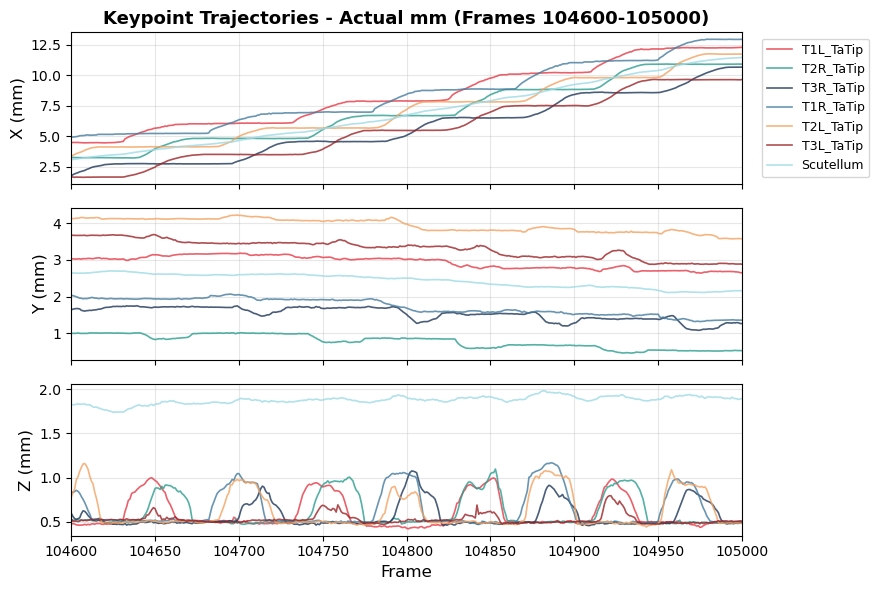

In [11]:
# --- USER CONFIGURATION ---
# Select which points to plot (use any keypoint name from the list above)
points_to_plot = [
    "T1L_TaTip",  # Front left tarsus
    "T2R_TaTip",
    "T3R_TaTip",
    "T1R_TaTip",  # Front right tarsus
    "T2L_TaTip",  # Middle left tarsus
    "T3L_TaTip",
    "Scutellum"  # Middle right tarsus
      # Hind left tarsus
      # Hind right tarsus
]
FRAME_START=104600
FRAME_END=105000
# JARVIS scale factor (JARVIS outputs are 10x actual mm)
JARVIS_SCALE = 10.0

# Optional: custom colors (if not specified, colors are auto-generated)
# Format: {"keypoint_name": "#hexcolor"}
CUSTOM_COLORS = {
    # Tarsus tips - left=warm, right=cool
    "T1L_TaTip": "#E63946",  "T1R_TaTip": "#457B9D",
    "T2L_TaTip": "#F4A261",  "T2R_TaTip": "#2A9D8F", 
    "T3L_TaTip": "#9B2226",  "T3R_TaTip": "#1D3557",
}
# --------------------------

# Generate colors for any keypoints not in CUSTOM_COLORS
def get_color(kp_name, idx, total):
    if kp_name in CUSTOM_COLORS:
        return CUSTOM_COLORS[kp_name]
    # Auto-generate using a colormap
    cmap = plt.cm.get_cmap('tab20')
    return cmap(idx / max(total - 1, 1))

def load_3d_data(csv_path: Path, frame_start: int, frame_end: int):
    """
    Load 3D keypoint data from JARVIS CSV format.
    """
    print(f"Loading 3D data from {csv_path}...")
    print(f"  Frame range: {frame_start} to {frame_end}")
    
    # Read header to get keypoint names
    header_df = pd.read_csv(csv_path, nrows=0)
    all_cols = header_df.columns.tolist()
    
    # Get unique keypoint names (each appears 4 times: x, y, z, confidence)
    keypoint_names = []
    for i in range(0, len(all_cols), 4):
        keypoint_names.append(all_cols[i])
    
    print(f"  Found {len(keypoint_names)} keypoints")
    
    # Load only the rows we need (skip header rows, then select frame range)
    df = pd.read_csv(csv_path, skiprows=[1], nrows=frame_end + 1)
    df = df.iloc[frame_start:frame_end + 1].reset_index(drop=True)
    
    print(f"  Loaded {len(df)} frames")
    return df, keypoint_names

# Load 3D data
df, keypoint_names = load_3d_data(DATA_3D_PATH, FRAME_START, FRAME_END)
# Extract data from keypoints 
def extract_keypoint_xyz(df, keypoint_name):
    """Extract x, y, z coordinates for a specific keypoint."""
    cols = df.columns.tolist()
    
    try:
        start_idx = cols.index(keypoint_name)
    except ValueError:
        raise ValueError(f"Keypoint '{keypoint_name}' not found in data")
    
    x = df.iloc[:, start_idx].values.astype(float)/JARVIS_SCALE
    y = df.iloc[:, start_idx + 1].values.astype(float)/JARVIS_SCALE
    z = df.iloc[:, start_idx + 2].values.astype(float)/JARVIS_SCALE

    return np.column_stack([x, y, z])

# Extract world coordinates for selected points 
selected_trajectories = []
selected_names = []
selected_colors = []

for idx, kp_name in enumerate(points_to_plot):
    if kp_name not in keypoint_names:
        print(f"⚠️  Warning: '{kp_name}' not found in keypoints, skipping.")
        continue
    world_pos = extract_keypoint_xyz(df, kp_name)
    selected_trajectories.append(world_pos)
    selected_names.append(kp_name)
    selected_colors.append(get_color(kp_name, idx, len(points_to_plot)))

# Create time axis (frame numbers)
n_frames = selected_trajectories[0].shape[0]
frames = np.arange(FRAME_START, FRAME_START + n_frames)

# Plot X, Y, Z separately for selected points
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

coord_labels = ['X (mm)', 'Y (mm)', 'Z (mm)']

for coord_idx, (ax, coord_label) in enumerate(zip(axes, coord_labels)):
    for traj, name, color in zip(selected_trajectories, selected_names, selected_colors):
        ax.plot(frames, traj[:, coord_idx], label=name, color=color, lw=1.2, alpha=0.8)
    
    ax.set_ylabel(coord_label, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(frames[0], frames[-1])

axes[0].set_title(f"Keypoint Trajectories - Actual mm (Frames {FRAME_START}-{FRAME_END})", 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Frame', fontsize=12)

# Legend outside the plot (to the right)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, frameon=True)

plt.tight_layout()
fig.subplots_adjust(right=0.82)

# Save figure
#output_xyz_path = OUTPUT_DIR / "keypoint_trajectories_xyz_mm.pdf"
#fig.savefig(output_xyz_path, format='pdf', dpi=300, bbox_inches='tight')
#print(f"✅ Saved to: {output_xyz_path}")

plt.show()

# Comprehensive Walking Bout Detection

This section implements a robust walking bout filter with 5 criteria:
1. Confidence >= 85% for all 50 keypoints
2. Upright posture (scutellum Z > all leg tips)
3. Floor threshold (leg tips Z >= 0.5 mm)
4. Each leg must have >= 5 swing phases
5. Total path distance >= 5 mm

Plus immobility tolerance (gap bridging up to 100 frames).

In [ ]:
# ============================================================================
# CONFIGURATION - Adjust these thresholds as needed
# ============================================================================


# PDF configuration for editable output
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'pdf.use14corefonts': True,
    'font.family': 'sans-serif',
    'axes.spines.right': False,
    'axes.spines.top': False,
})

# Data scaling
JARVIS_SCALE = 10.0          # Divide raw values by this to get mm

# Frame rate
FPS = 800                    # Video frame rate

# ============================================================================
# FILTER BEHAVIOR MODES
# ============================================================================
# Filter modes for "soft" filters:
#   "split_bout"      - break bout at violations (original behavior)
#   "exclude_frames"  - mark frames invalid but keep bout together  
#   "ignore"          - ignore the violation entirely

# --- HARD FILTERS (can be enabled/disabled) ---
# Confidence filter
CONFIDENCE_FILTER_ENABLED = True
CONFIDENCE_THRESHOLD = 0.85  # Minimum confidence (0-1) for ALL keypoints

# Upright posture filter (Scutellum Z > all leg tips)
UPRIGHT_FILTER_ENABLED = True

# --- SOFT FILTERS (enable/disable + mode) ---
# Floor Z filter
FLOOR_Z_FILTER_ENABLED = True
FLOOR_Z_FILTER_MODE = "split_bout"  # "split_bout", "exclude_frames", "ignore"
FLOOR_Z_THRESHOLD = 0.40                 # mm - minimum Z for leg tips

# Y-wall upper boundary filter (Y >= Y_WALL_MAX - margin)
Y_WALL_UPPER_ENABLED = True
Y_WALL_UPPER_MODE = "split_bout"        # "split_bout", "exclude_frames", "ignore"
Y_WALL_MAX = 5.8                        # mm - upper wall boundary
Y_WALL_UPPER_MARGIN = 0.1               # mm

# Y-wall lower boundary filter (Y <= Y_WALL_MIN + margin) - NEW
Y_WALL_LOWER_ENABLED = True
Y_WALL_LOWER_MODE = "split_bout"    # "split_bout", "exclude_frames", "ignore"
Y_WALL_MIN = 0.0                        # mm - lower wall boundary
Y_WALL_LOWER_MARGIN = 0.0               # mm (exclude if Y <= 0.1)

# Prolonged immobility filter
IMMOBILITY_FILTER_ENABLED = False
IMMOBILITY_FILTER_MODE = "split_bout"   # "split_bout", "exclude_frames", "ignore"
MAX_STATIONARY_FRAMES = 500             # Break if stationary for > this many frames
STATIONARY_SPEED_THRESHOLD = 0.5        # mm/s - speeds below this = stationary

# --- WALKING VALIDATION ---
MIN_WALKING_CYCLES = 2       # Minimum swing phases per leg
MIN_DISTANCE_MM = 3.0        # Minimum total path distance in mm
MAX_IMMOBILITY_FRAMES = 500  # Maximum gap to bridge (immobility tolerance)
MIN_BOUT_FRAMES = 50        # Minimum bout duration in frames

# Swing detection parameters
MAX_SWING_DURATION = 40      # Maximum frames for a swing phase
SWING_PROMINENCE = 0.05      # Peak prominence threshold (mm)

# Straightness filter
ENFORCE_STRAIGHTNESS = False  # Toggle: if True, only keep straight bouts
STRAIGHTNESS_THRESHOLD = 0.2  # net_displacement/total_distance ratio

# --- GAIT PHASE DIAGRAM ---
STANCE_Z_THRESHOLD = 0.59     # mm - leg is in stance when Z <= this
SHOW_GAIT_DIAGRAM = True     # Add gait phase diagram to bout figures

# --- DIAGNOSTICS ---
SHOW_BOUNDARY_DIAGNOSTICS = True   # Print which filters fail at bout boundaries
BOUNDARY_DIAGNOSTIC_FRAMES = 50    # How many frames before/after bout to analyze

# Arena dimensions (rectangular chamber)
ARENA_X_MM = 24.0            # Arena length in X (mm)
ARENA_Y_MM = 5.5             # Arena width in Y (mm)

# Visualization
PDF_DPI = 300                # Output resolution

# Keypoint names
LEG_TIPS = ["T1L_TaTip", "T1R_TaTip", "T2L_TaTip", "T2R_TaTip", "T3L_TaTip", "T3R_TaTip"]
SCUTELLUM = "Scutellum"

print("Configuration loaded.")
print(f"Arena: {ARENA_X_MM} x {ARENA_Y_MM} mm (rectangular)")
print(f"Output directory: {OUTPUT_DIR.absolute()}")
print(f"Data 3D directory: {DATA_3D_PATH.absolute()}")
print(f"\nFilter settings:")
print(f"  Confidence filter: {'ENABLED' if CONFIDENCE_FILTER_ENABLED else 'DISABLED'} (threshold: {CONFIDENCE_THRESHOLD})")
print(f"  Upright filter: {'ENABLED' if UPRIGHT_FILTER_ENABLED else 'DISABLED'}")
print(f"  Floor Z filter: {'ENABLED' if FLOOR_Z_FILTER_ENABLED else 'DISABLED'} (mode: {FLOOR_Z_FILTER_MODE}, threshold: {FLOOR_Z_THRESHOLD}mm)")
print(f"  Y-wall upper filter: {'ENABLED' if Y_WALL_UPPER_ENABLED else 'DISABLED'} (mode: {Y_WALL_UPPER_MODE})")
print(f"  Y-wall lower filter: {'ENABLED' if Y_WALL_LOWER_ENABLED else 'DISABLED'} (mode: {Y_WALL_LOWER_MODE})")
print(f"  Immobility filter: {'ENABLED' if IMMOBILITY_FILTER_ENABLED else 'DISABLED'} (mode: {IMMOBILITY_FILTER_MODE})")
print(f"  Gait diagram: {'ENABLED' if SHOW_GAIT_DIAGRAM else 'DISABLED'}")
print(f"  Boundary diagnostics: {'ENABLED' if SHOW_BOUNDARY_DIAGNOSTICS else 'DISABLED'}")

In [ ]:
# ============================================================================
# DATA EXTRACTION FUNCTIONS
# ============================================================================

def get_all_keypoint_names(df):
    """Get all unique keypoint names from dataframe columns."""
    cols = df.columns.tolist()
    # Each keypoint has 4 columns: name, name.1, name.2, name.3 (x, y, z, conf)
    kp_names = []
    seen = set()
    for col in cols:
        base_name = col.split('.')[0] if '.' in col else col
        if base_name not in seen:
            seen.add(base_name)
            kp_names.append(base_name)
    return kp_names


def extract_xyzc(df, kp_name, scale=JARVIS_SCALE):
    """
    Extract x, y, z coordinates and confidence for a keypoint.
    
    Args:
        df: DataFrame with tracking data
        kp_name: Keypoint name (e.g., "T1L_TaTip")
        scale: JARVIS_SCALE factor (default 10.0)
    
    Returns:
        x, y, z: Arrays of coordinates in mm
        conf: Array of confidence values (0-1)
    """
    cols = df.columns.tolist()
    start_idx = cols.index(kp_name)
    
    x = df.iloc[:, start_idx].values.astype(float) / scale
    y = df.iloc[:, start_idx + 1].values.astype(float) / scale
    z = df.iloc[:, start_idx + 2].values.astype(float) / scale
    conf = df.iloc[:, start_idx + 3].values.astype(float)  # Confidence NOT scaled
    
    return x, y, z, conf


def extract_all_data(df, scale=JARVIS_SCALE):
    """
    Extract xyz and confidence for all leg tips and scutellum.
    
    Returns:
        leg_tip_data: Dict mapping leg name -> {'x', 'y', 'z', 'conf'}
        scutellum_data: Dict with {'x', 'y', 'z', 'conf'}
        all_keypoint_conf: Dict mapping all kp names -> conf array
    """
    leg_tip_data = {}
    for tip in LEG_TIPS:
        x, y, z, conf = extract_xyzc(df, tip, scale)
        leg_tip_data[tip] = {'x': x, 'y': y, 'z': z, 'conf': conf}
    
    scut_x, scut_y, scut_z, scut_conf = extract_xyzc(df, SCUTELLUM, scale)
    scutellum_data = {'x': scut_x, 'y': scut_y, 'z': scut_z, 'conf': scut_conf}
    
    # Extract confidence for ALL keypoints
    all_kp_names = get_all_keypoint_names(df)
    all_keypoint_conf = {}
    for kp in all_kp_names:
        try:
            _, _, _, conf = extract_xyzc(df, kp, scale)
            all_keypoint_conf[kp] = conf
        except (ValueError, IndexError):
            pass  # Skip if keypoint not found
    
    return leg_tip_data, scutellum_data, all_keypoint_conf


print("Data extraction functions defined.")

In [ ]:
# ============================================================================
# FRAME-LEVEL FILTER FUNCTIONS
# ============================================================================

def apply_comprehensive_walking_filter(
    df,
    scale=JARVIS_SCALE,
    # Confidence filter
    confidence_filter_enabled=CONFIDENCE_FILTER_ENABLED,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    # Upright filter
    upright_filter_enabled=UPRIGHT_FILTER_ENABLED,
    # Floor Z filter
    floor_z_filter_enabled=FLOOR_Z_FILTER_ENABLED,
    floor_z_filter_mode=FLOOR_Z_FILTER_MODE,
    floor_z_threshold=FLOOR_Z_THRESHOLD,
    # Y-wall upper filter
    y_wall_upper_enabled=Y_WALL_UPPER_ENABLED,
    y_wall_upper_mode=Y_WALL_UPPER_MODE,
    y_wall_max=Y_WALL_MAX,
    y_wall_upper_margin=Y_WALL_UPPER_MARGIN,
    # Y-wall lower filter
    y_wall_lower_enabled=Y_WALL_LOWER_ENABLED,
    y_wall_lower_mode=Y_WALL_LOWER_MODE,
    y_wall_min=Y_WALL_MIN,
    y_wall_lower_margin=Y_WALL_LOWER_MARGIN
):
    """
    Apply comprehensive walking filter with all frame-level criteria.
    
    All filters can be enabled/disabled independently.
    "Soft" filters (floor, y-wall) have modes: "split_bout", "exclude_frames", "ignore"
    
    Returns:
        valid_mask: Boolean array (True = valid walking frame for bout detection)
        leg_tip_data: Dict of leg data
        scutellum_data: Dict of scutellum data  
        filter_masks: Dict of individual filter masks for downstream use
        diagnostics: Dict with per-criterion pass rates
    """
    n_frames = len(df)
    
    # Extract all data
    leg_tip_data, scutellum_data, all_keypoint_conf = extract_all_data(df, scale)
    
    # =========================================================================
    # COMPUTE INDIVIDUAL FILTER MASKS
    # =========================================================================
    
    # Criterion 1: Confidence filter (ALL keypoints >= threshold)
    confidence_mask = np.ones(n_frames, dtype=bool)
    if confidence_filter_enabled:
        for kp_name, conf_arr in all_keypoint_conf.items():
            confidence_mask &= (conf_arr >= confidence_threshold)
    
    # Criterion 2: Upright posture (scutellum Z > all leg tips)
    upright_mask = np.ones(n_frames, dtype=bool)
    if upright_filter_enabled:
        for tip in LEG_TIPS:
            upright_mask &= (scutellum_data['z'] > leg_tip_data[tip]['z'])
    
    # Criterion 3: Floor Z violations (any leg Z < threshold)
    floor_violation_mask = np.zeros(n_frames, dtype=bool)
    if floor_z_filter_enabled:
        for tip in LEG_TIPS:
            floor_violation_mask |= (leg_tip_data[tip]['z'] < floor_z_threshold)
    
    # Criterion 4: Y-wall UPPER violations (any leg Y >= max - margin)
    y_wall_upper_violation_mask = np.zeros(n_frames, dtype=bool)
    if y_wall_upper_enabled:
        for tip in LEG_TIPS:
            y = leg_tip_data[tip]['y']
            y_wall_upper_violation_mask |= (y >= y_wall_max - y_wall_upper_margin)
    
    # Criterion 5: Y-wall LOWER violations (any leg Y <= min + margin)
    y_wall_lower_violation_mask = np.zeros(n_frames, dtype=bool)
    if y_wall_lower_enabled:
        for tip in LEG_TIPS:
            y = leg_tip_data[tip]['y']
            y_wall_lower_violation_mask |= (y <= y_wall_min + y_wall_lower_margin)
    
    # =========================================================================
    # BUILD VALID MASK FOR BOUT DETECTION
    # =========================================================================
    # Start with hard filters (confidence, upright)
    valid_mask = confidence_mask & upright_mask
    
    # Apply soft filters based on mode
    # If mode is "ignore", don't apply to valid_mask
    # If mode is "split_bout" or "exclude_frames", apply to valid_mask
    
    if floor_z_filter_enabled and floor_z_filter_mode != "ignore":
        valid_mask &= ~floor_violation_mask
    
    if y_wall_upper_enabled and y_wall_upper_mode != "ignore":
        valid_mask &= ~y_wall_upper_violation_mask
    
    if y_wall_lower_enabled and y_wall_lower_mode != "ignore":
        valid_mask &= ~y_wall_lower_violation_mask
    
    # =========================================================================
    # STORE FILTER MASKS FOR DOWNSTREAM USE
    # =========================================================================
    filter_masks = {
        'confidence': confidence_mask,              # True = passes confidence
        'upright': upright_mask,                    # True = passes upright
        'floor_violation': floor_violation_mask,    # True = VIOLATION (Z < threshold)
        'y_wall_upper_violation': y_wall_upper_violation_mask,  # True = VIOLATION
        'y_wall_lower_violation': y_wall_lower_violation_mask,  # True = VIOLATION
    }
    
    # =========================================================================
    # DIAGNOSTICS
    # =========================================================================
    diagnostics = {
        'total_frames': n_frames,
        'confidence_pass': int(confidence_mask.sum()),
        'upright_pass': int(upright_mask.sum()),
        'floor_violations': int(floor_violation_mask.sum()),
        'y_wall_upper_violations': int(y_wall_upper_violation_mask.sum()),
        'y_wall_lower_violations': int(y_wall_lower_violation_mask.sum()),
        'combined_pass': int(valid_mask.sum()),
        'confidence_pass_pct': 100 * confidence_mask.sum() / n_frames,
        'upright_pass_pct': 100 * upright_mask.sum() / n_frames,
        'floor_violation_pct': 100 * floor_violation_mask.sum() / n_frames,
        'y_wall_upper_violation_pct': 100 * y_wall_upper_violation_mask.sum() / n_frames,
        'y_wall_lower_violation_pct': 100 * y_wall_lower_violation_mask.sum() / n_frames,
        'combined_pass_pct': 100 * valid_mask.sum() / n_frames,
        'n_keypoints_checked': len(all_keypoint_conf),
        # Filter settings
        'confidence_filter_enabled': confidence_filter_enabled,
        'upright_filter_enabled': upright_filter_enabled,
        'floor_z_filter_enabled': floor_z_filter_enabled,
        'floor_z_filter_mode': floor_z_filter_mode,
        'y_wall_upper_enabled': y_wall_upper_enabled,
        'y_wall_upper_mode': y_wall_upper_mode,
        'y_wall_lower_enabled': y_wall_lower_enabled,
        'y_wall_lower_mode': y_wall_lower_mode,
    }
    
    return valid_mask, leg_tip_data, scutellum_data, filter_masks, diagnostics


def diagnose_bout_boundaries(bout_start, bout_end, filter_masks, n_frames_context=BOUNDARY_DIAGNOSTIC_FRAMES):
    """
    Analyze frames around bout boundaries to show which filters fail.
    
    Helps identify WHY early frames are excluded from bouts.
    
    Args:
        bout_start: First frame index of detected bout
        bout_end: Last frame index of detected bout
        filter_masks: Dict of filter masks from apply_comprehensive_walking_filter
        n_frames_context: How many frames before/after to analyze
    
    Returns:
        dict with per-filter failure counts and identification of primary cause
    """
    total_frames = len(filter_masks['confidence'])
    
    # Analyze frames BEFORE bout start
    pre_start = max(0, bout_start - n_frames_context)
    pre_range = slice(pre_start, bout_start)
    
    # Analyze frames AFTER bout end
    post_end = min(total_frames, bout_end + n_frames_context + 1)
    post_range = slice(bout_end + 1, post_end)
    
    # Count failures before bout (why didn't it start earlier?)
    pre_failures = {
        'confidence': int((~filter_masks['confidence'][pre_range]).sum()),
        'upright': int((~filter_masks['upright'][pre_range]).sum()),
        'floor': int(filter_masks['floor_violation'][pre_range].sum()),
        'y_wall_upper': int(filter_masks['y_wall_upper_violation'][pre_range].sum()),
        'y_wall_lower': int(filter_masks['y_wall_lower_violation'][pre_range].sum()),
        'n_frames_analyzed': bout_start - pre_start,
    }
    
    # Count failures after bout (why didn't it continue?)
    post_failures = {
        'confidence': int((~filter_masks['confidence'][post_range]).sum()),
        'upright': int((~filter_masks['upright'][post_range]).sum()),
        'floor': int(filter_masks['floor_violation'][post_range].sum()),
        'y_wall_upper': int(filter_masks['y_wall_upper_violation'][post_range].sum()),
        'y_wall_lower': int(filter_masks['y_wall_lower_violation'][post_range].sum()),
        'n_frames_analyzed': post_end - bout_end - 1,
    }
    
    # Find primary cause (filter with most failures)
    pre_max = max(pre_failures.items(), key=lambda x: x[1] if x[0] != 'n_frames_analyzed' else 0)
    post_max = max(post_failures.items(), key=lambda x: x[1] if x[0] != 'n_frames_analyzed' else 0)
    
    return {
        'pre_bout_failures': pre_failures,
        'post_bout_failures': post_failures,
        'primary_cause_before': pre_max[0] if pre_max[1] > 0 else None,
        'primary_cause_after': post_max[0] if post_max[1] > 0 else None,
    }


def print_boundary_diagnostics(bout_idx, diagnostics):
    """Print formatted boundary diagnostics for a bout."""
    pre = diagnostics['pre_bout_failures']
    post = diagnostics['post_bout_failures']
    
    print(f"\n  Bout {bout_idx} boundary analysis:")
    print(f"    Before bout ({pre['n_frames_analyzed']} frames):")
    for name in ['confidence', 'upright', 'floor', 'y_wall_upper', 'y_wall_lower']:
        count = pre[name]
        if count > 0:
            marker = " <-- PRIMARY" if diagnostics['primary_cause_before'] == name else ""
            print(f"      {name}: {count} failures{marker}")
    
    if post['n_frames_analyzed'] > 0:
        print(f"    After bout ({post['n_frames_analyzed']} frames):")
        for name in ['confidence', 'upright', 'floor', 'y_wall_upper', 'y_wall_lower']:
            count = post[name]
            if count > 0:
                marker = " <-- PRIMARY" if diagnostics['primary_cause_after'] == name else ""
                print(f"      {name}: {count} failures{marker}")


print("Frame filter functions defined (with toggleable filters and boundary diagnostics).")

In [ ]:
# ============================================================================
# BOUT DETECTION WITH GAP BRIDGING
# ============================================================================

def find_contiguous_bouts_with_gap_bridging(
    valid_mask,
    min_frames=MIN_BOUT_FRAMES,
    max_gap=MAX_IMMOBILITY_FRAMES
):
    """
    Find contiguous walking bouts, bridging small gaps (immobility tolerance).
    
    Args:
        valid_mask: Boolean array of valid frames
        min_frames: Minimum bout length
        max_gap: Maximum gap to bridge (immobility tolerance)
    
    Returns:
        bouts: List of (start_idx, end_idx) tuples
    """
    # First, bridge gaps <= max_gap
    bridged = valid_mask.copy()
    
    # Find gaps and bridge them if they're bounded by valid frames
    in_gap = False
    gap_start = 0
    
    for i in range(len(bridged)):
        if not bridged[i]:
            if not in_gap:
                gap_start = i
                in_gap = True
        else:
            if in_gap:
                gap_len = i - gap_start
                # Bridge if gap is small and bounded by valid frames
                if gap_len <= max_gap and gap_start > 0 and bridged[gap_start - 1]:
                    bridged[gap_start:i] = True
                in_gap = False
    
    # Now find contiguous segments
    bouts = []
    in_bout = False
    start = 0
    
    for i, valid in enumerate(bridged):
        if valid and not in_bout:
            start = i
            in_bout = True
        elif not valid and in_bout:
            if i - start >= min_frames:
                bouts.append((start, i - 1))
            in_bout = False
    
    # Handle bout extending to end
    if in_bout and len(bridged) - start >= min_frames:
        bouts.append((start, len(bridged) - 1))
    
    return bouts


def split_bouts_at_violations(
    bouts, 
    leg_tip_data, 
    scutellum_data, 
    filter_masks,
    fps=FPS,
    # Floor filter config
    floor_z_filter_enabled=FLOOR_Z_FILTER_ENABLED,
    floor_z_filter_mode=FLOOR_Z_FILTER_MODE,
    # Y-wall upper config
    y_wall_upper_enabled=Y_WALL_UPPER_ENABLED,
    y_wall_upper_mode=Y_WALL_UPPER_MODE,
    # Y-wall lower config
    y_wall_lower_enabled=Y_WALL_LOWER_ENABLED,
    y_wall_lower_mode=Y_WALL_LOWER_MODE,
    # Immobility config
    immobility_filter_enabled=IMMOBILITY_FILTER_ENABLED,
    immobility_filter_mode=IMMOBILITY_FILTER_MODE,
    max_stationary=MAX_STATIONARY_FRAMES, 
    stationary_thresh=STATIONARY_SPEED_THRESHOLD,
    min_frames=MIN_BOUT_FRAMES
):
    """
    Split bouts at violation points based on filter modes.
    
    Only splits on violations where mode == "split_bout".
    Modes "exclude_frames" and "ignore" do NOT cause splits.
    
    Returns:
        split_bouts: List of (start, end) tuples for valid sub-bouts
        bout_excluded_masks: List of boolean arrays marking excluded frames per bout
    """
    split_bouts_list = []
    bout_excluded_masks = []
    
    for start, end in bouts:
        n = end - start + 1
        
        # Track violations that SPLIT bouts (only mode="split_bout")
        split_violation = np.zeros(n, dtype=bool)
        
        # Track frames to EXCLUDE from analysis (mode="exclude_frames")
        excluded_mask = np.zeros(n, dtype=bool)
        
        # =====================================================================
        # FLOOR VIOLATIONS
        # =====================================================================
        if floor_z_filter_enabled:
            floor_viol = filter_masks['floor_violation'][start:end+1]
            if floor_z_filter_mode == "split_bout":
                split_violation |= floor_viol
            elif floor_z_filter_mode == "exclude_frames":
                excluded_mask |= floor_viol
            # mode="ignore" - do nothing
        
        # =====================================================================
        # Y-WALL UPPER VIOLATIONS
        # =====================================================================
        if y_wall_upper_enabled:
            y_upper_viol = filter_masks['y_wall_upper_violation'][start:end+1]
            if y_wall_upper_mode == "split_bout":
                split_violation |= y_upper_viol
            elif y_wall_upper_mode == "exclude_frames":
                excluded_mask |= y_upper_viol
        
        # =====================================================================
        # Y-WALL LOWER VIOLATIONS
        # =====================================================================
        if y_wall_lower_enabled:
            y_lower_viol = filter_masks['y_wall_lower_violation'][start:end+1]
            if y_wall_lower_mode == "split_bout":
                split_violation |= y_lower_viol
            elif y_wall_lower_mode == "exclude_frames":
                excluded_mask |= y_lower_viol
        
        # =====================================================================
        # PROLONGED IMMOBILITY
        # =====================================================================
        if immobility_filter_enabled:
            speed, _, _ = compute_instant_speed(scutellum_data, start, end, fps)
            is_stationary = speed < stationary_thresh
            
            # Find runs of stationary frames > threshold
            immobility_viol = np.zeros(n, dtype=bool)
            run_len = 0
            run_start = 0
            for i, stat in enumerate(is_stationary):
                if stat:
                    if run_len == 0:
                        run_start = i
                    run_len += 1
                else:
                    if run_len > max_stationary:
                        immobility_viol[run_start:run_start + run_len] = True
                    run_len = 0
            # Handle run extending to end
            if run_len > max_stationary:
                immobility_viol[run_start:run_start + run_len] = True
            
            if immobility_filter_mode == "split_bout":
                split_violation |= immobility_viol
            elif immobility_filter_mode == "exclude_frames":
                excluded_mask |= immobility_viol
        
        # =====================================================================
        # SPLIT INTO SUB-BOUTS (only at split_violation points)
        # =====================================================================
        valid = ~split_violation
        in_valid = False
        sub_start = 0
        
        for i, v in enumerate(valid):
            if v and not in_valid:
                sub_start = i
                in_valid = True
            elif not v and in_valid:
                if i - sub_start >= min_frames:
                    split_bouts_list.append((start + sub_start, start + i - 1))
                    # Store excluded mask for this sub-bout
                    bout_excluded_masks.append(excluded_mask[sub_start:i].copy())
                in_valid = False
        
        if in_valid and (n - sub_start) >= min_frames:
            split_bouts_list.append((start + sub_start, end))
            bout_excluded_masks.append(excluded_mask[sub_start:].copy())
    
    return split_bouts_list, bout_excluded_masks


def get_excluded_frames_for_bout(start, end, filter_masks,
                                  floor_z_filter_mode=FLOOR_Z_FILTER_MODE,
                                  y_wall_upper_mode=Y_WALL_UPPER_MODE,
                                  y_wall_lower_mode=Y_WALL_LOWER_MODE,
                                  immobility_filter_mode=IMMOBILITY_FILTER_MODE):
    """
    Compute which frames within a bout should be excluded from analysis.
    
    Frames are excluded if they violate a filter with mode="exclude_frames".
    This is used for computing statistics on "clean" frames only.
    """
    n = end - start + 1
    excluded = np.zeros(n, dtype=bool)
    
    if floor_z_filter_mode == "exclude_frames":
        excluded |= filter_masks['floor_violation'][start:end+1]
    
    if y_wall_upper_mode == "exclude_frames":
        excluded |= filter_masks['y_wall_upper_violation'][start:end+1]
    
    if y_wall_lower_mode == "exclude_frames":
        excluded |= filter_masks['y_wall_lower_violation'][start:end+1]
    
    return excluded


print("Bout detection functions defined (with mode-aware violation splitting).")

In [ ]:
# ============================================================================
# SWING PHASE DETECTION
# ============================================================================

def detect_swing_phases(
    z_signal,
    max_swing_duration=MAX_SWING_DURATION,
    min_prominence=SWING_PROMINENCE
):
    """
    Detect swing phases as sharp Z peaks.
    
    A swing phase is:
    - A peak in the Z signal (leg lifted off ground)
    - Duration under max_swing_duration frames
    
    Args:
        z_signal: Z coordinate array for one leg tip
        max_swing_duration: Maximum frames for a valid swing
        min_prominence: Minimum peak prominence (mm)
    
    Returns:
        swing_peaks: Array of peak indices
        swing_count: Number of valid swing phases
    """
    # Handle NaN values
    z_clean = z_signal.copy()
    nan_mask = np.isnan(z_clean)
    
    if nan_mask.all():
        return np.array([]), 0
    
    if nan_mask.any():
        valid_idx = np.where(~nan_mask)[0]
        z_clean[nan_mask] = np.interp(
            np.where(nan_mask)[0],
            valid_idx,
            z_clean[valid_idx]
        )
    
    # Light smoothing
    z_smooth = uniform_filter1d(z_clean, size=5)
    
    # Find peaks with constraints
    peaks, properties = find_peaks(
        z_smooth,
        prominence=min_prominence,
        distance=8,  # Minimum distance between peaks
        width=(1, max_swing_duration)  # Width constraint for "sharp" peaks
    )
    
    return peaks, len(peaks)


def count_swing_phases_all_legs(
    leg_tip_data,
    start,
    end,
    max_swing_duration=MAX_SWING_DURATION,
    min_prominence=SWING_PROMINENCE
):
    """
    Count swing phases for all 6 legs.
    
    Args:
        leg_tip_data: Dict of leg data
        start, end: Bout boundaries
        max_swing_duration: Max frames for swing detection
        min_prominence: Peak prominence threshold
    
    Returns:
        per_leg_cycles: Dict of swing counts per leg
        min_cycles: Minimum across all legs
    """
    per_leg_cycles = {}
    
    for tip in LEG_TIPS:
        z_bout = leg_tip_data[tip]['z'][start:end+1]
        _, swing_count = detect_swing_phases(
            z_bout, max_swing_duration, min_prominence
        )
        per_leg_cycles[tip] = swing_count
    
    min_cycles = min(per_leg_cycles.values()) if per_leg_cycles else 0
    
    return per_leg_cycles, min_cycles


print("Swing detection functions defined.")

In [ ]:
# ============================================================================
# DISTANCE AND SPEED COMPUTATION
# ============================================================================

def compute_total_distance(scutellum_data, start, end):
    """
    Compute total path distance traveled using scutellum position.
    
    Uses cumulative displacement (not just start-to-end distance).
    
    Returns:
        total_distance: Total path length in mm
        net_displacement: Straight-line start-to-end distance in mm
    """
    x = scutellum_data['x'][start:end+1]
    y = scutellum_data['y'][start:end+1]
    
    # Handle NaN
    valid = ~np.isnan(x) & ~np.isnan(y)
    if valid.sum() < 2:
        return 0.0, 0.0
    
    x_valid = x[valid]
    y_valid = y[valid]
    
    # Total path distance (cumulative)
    dx = np.diff(x_valid)
    dy = np.diff(y_valid)
    step_distances = np.sqrt(dx**2 + dy**2)
    total_distance = np.sum(step_distances)
    
    # Net displacement (straight line)
    net_displacement = np.sqrt(
        (x_valid[-1] - x_valid[0])**2 + 
        (y_valid[-1] - y_valid[0])**2
    )
    
    return total_distance, net_displacement


def compute_instant_speed(scutellum_data, start, end, fps=FPS):
    """
    Compute instantaneous speed at each frame.
    
    Returns:
        speed: Array of speeds in mm/s (same length as bout)
        mean_speed: Mean speed over bout
        max_speed: Maximum speed
    """
    x = scutellum_data['x'][start:end+1]
    y = scutellum_data['y'][start:end+1]
    
    # Compute displacements
    dx = np.diff(x)
    dy = np.diff(y)
    displacement = np.sqrt(dx**2 + dy**2)
    
    # Speed = displacement * fps
    speed = displacement * fps  # mm/s
    
    # Pad to match original length
    speed = np.concatenate([[speed[0] if len(speed) > 0 else 0], speed])
    
    # Handle NaN
    mean_speed = np.nanmean(speed)
    max_speed = np.nanmax(speed)
    
    return speed, mean_speed, max_speed


print("Distance and speed functions defined.")

In [ ]:
# ============================================================================
# BOUT VALIDATION
# ============================================================================

def validate_walking_bouts(
    bouts,
    leg_tip_data,
    scutellum_data,
    min_cycles=MIN_WALKING_CYCLES,
    min_distance_mm=MIN_DISTANCE_MM,
    max_swing_duration=MAX_SWING_DURATION,
    min_prominence=SWING_PROMINENCE,
    enforce_straightness=ENFORCE_STRAIGHTNESS,
    straightness_threshold=STRAIGHTNESS_THRESHOLD
):
    """
    Validate candidate bouts against walking cycle, distance, and straightness criteria.
    
    Criteria:
    - Each leg must have >= min_cycles swing phases
    - Total path distance >= min_distance_mm
    - Straightness >= threshold (if enforce_straightness is True)
    
    Returns:
        valid_bouts: List of validated bout dicts with metadata
        rejected_bouts: List of rejected bout dicts with rejection reason
    """
    valid_bouts = []
    rejected_bouts = []
    
    for start, end in bouts:
        # Count swing phases for each leg
        per_leg_cycles, min_leg_cycles = count_swing_phases_all_legs(
            leg_tip_data, start, end, max_swing_duration, min_prominence
        )
        
        # Compute distance
        total_distance, net_displacement = compute_total_distance(
            scutellum_data, start, end
        )
        
        # Compute straightness (net_displacement / total_distance)
        straightness = net_displacement / total_distance if total_distance > 0 else 0
        
        bout_info = {
            'start': start,
            'end': end,
            'n_frames': end - start + 1,
            'min_cycles': min_leg_cycles,
            'per_leg_cycles': per_leg_cycles,
            'total_distance_mm': total_distance,
            'net_displacement_mm': net_displacement,
            'straightness': straightness
        }
        
        # Check if ALL legs have enough cycles
        all_legs_pass = all(
            cycles >= min_cycles for cycles in per_leg_cycles.values()
        )
        passes_distance = total_distance >= min_distance_mm
        
        # Check straightness (only if enforced)
        passes_straightness = (not enforce_straightness) or (straightness >= straightness_threshold)
        
        if all_legs_pass and passes_distance and passes_straightness:
            bout_info['valid'] = True
            valid_bouts.append(bout_info)
        else:
            bout_info['valid'] = False
            bout_info['rejection_reason'] = []
            if not all_legs_pass:
                failing_legs = [
                    f"{leg}:{c}" for leg, c in per_leg_cycles.items() 
                    if c < min_cycles
                ]
                bout_info['rejection_reason'].append(
                    f"legs with <{min_cycles} cycles: {failing_legs}"
                )
            if not passes_distance:
                bout_info['rejection_reason'].append(
                    f"distance: {total_distance:.2f}mm < {min_distance_mm}mm"
                )
            if not passes_straightness:
                bout_info['rejection_reason'].append(
                    f"straightness: {straightness:.2f} < {straightness_threshold}"
                )
            rejected_bouts.append(bout_info)
    
    return valid_bouts, rejected_bouts


print("Bout validation functions defined (including straightness filter).")

In [ ]:
# ============================================================================
# MAIN PIPELINE FUNCTION
# ============================================================================

def detect_walking_bouts(
    df,
    scale=JARVIS_SCALE,
    # Hard filter parameters
    confidence_filter_enabled=CONFIDENCE_FILTER_ENABLED,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    upright_filter_enabled=UPRIGHT_FILTER_ENABLED,
    # Floor filter parameters
    floor_z_filter_enabled=FLOOR_Z_FILTER_ENABLED,
    floor_z_filter_mode=FLOOR_Z_FILTER_MODE,
    floor_z_threshold=FLOOR_Z_THRESHOLD,
    # Y-wall upper parameters
    y_wall_upper_enabled=Y_WALL_UPPER_ENABLED,
    y_wall_upper_mode=Y_WALL_UPPER_MODE,
    y_wall_max=Y_WALL_MAX,
    y_wall_upper_margin=Y_WALL_UPPER_MARGIN,
    # Y-wall lower parameters
    y_wall_lower_enabled=Y_WALL_LOWER_ENABLED,
    y_wall_lower_mode=Y_WALL_LOWER_MODE,
    y_wall_min=Y_WALL_MIN,
    y_wall_lower_margin=Y_WALL_LOWER_MARGIN,
    # Immobility parameters
    immobility_filter_enabled=IMMOBILITY_FILTER_ENABLED,
    immobility_filter_mode=IMMOBILITY_FILTER_MODE,
    max_stationary_frames=MAX_STATIONARY_FRAMES,
    stationary_speed_threshold=STATIONARY_SPEED_THRESHOLD,
    # Bout detection parameters
    min_bout_frames=MIN_BOUT_FRAMES,
    max_immobility_gap=MAX_IMMOBILITY_FRAMES,
    # Validation parameters
    min_walking_cycles=MIN_WALKING_CYCLES,
    min_distance_mm=MIN_DISTANCE_MM,
    max_swing_duration=MAX_SWING_DURATION,
    swing_prominence=SWING_PROMINENCE,
    enforce_straightness=ENFORCE_STRAIGHTNESS,
    straightness_threshold=STRAIGHTNESS_THRESHOLD,
    # Diagnostics
    show_boundary_diagnostics=SHOW_BOUNDARY_DIAGNOSTICS,
    boundary_diagnostic_frames=BOUNDARY_DIAGNOSTIC_FRAMES,
    verbose=True
):
    """
    Complete walking bout detection pipeline with configurable filters.
    
    All filters can be enabled/disabled independently.
    Soft filters (floor, y-wall, immobility) have modes:
      - "split_bout": Break bout at violations
      - "exclude_frames": Mark frames as excluded but keep bout together
      - "ignore": Ignore violations entirely
    
    Returns:
        valid_bouts: List of validated bout dicts (with excluded_frame_mask)
        rejected_bouts: List of rejected bout dicts
        leg_tip_data: Extracted leg data
        scutellum_data: Extracted scutellum data
        filter_masks: Individual filter masks for analysis
        diagnostics: Filter statistics
    """
    if verbose:
        print("=" * 70)
        print("WALKING BOUT DETECTION PIPELINE")
        print("=" * 70)
        print(f"\nFilter settings:")
        print(f"  Confidence: {'ENABLED' if confidence_filter_enabled else 'DISABLED'} (threshold: {confidence_threshold})")
        print(f"  Upright: {'ENABLED' if upright_filter_enabled else 'DISABLED'}")
        print(f"  Floor Z: {'ENABLED' if floor_z_filter_enabled else 'DISABLED'} (mode: {floor_z_filter_mode}, threshold: {floor_z_threshold}mm)")
        print(f"  Y-wall upper: {'ENABLED' if y_wall_upper_enabled else 'DISABLED'} (mode: {y_wall_upper_mode}, Y >= {y_wall_max - y_wall_upper_margin}mm)")
        print(f"  Y-wall lower: {'ENABLED' if y_wall_lower_enabled else 'DISABLED'} (mode: {y_wall_lower_mode}, Y <= {y_wall_min + y_wall_lower_margin}mm)")
        print(f"  Immobility: {'ENABLED' if immobility_filter_enabled else 'DISABLED'} (mode: {immobility_filter_mode})")
        print(f"\nValidation:")
        print(f"  Min walking cycles: {min_walking_cycles}")
        print(f"  Min distance: {min_distance_mm} mm")
        print(f"  Min bout duration: {min_bout_frames} frames")
    
    # =========================================================================
    # STEP 1: Apply frame-level filters
    # =========================================================================
    valid_mask, leg_tip_data, scutellum_data, filter_masks, diagnostics = (
        apply_comprehensive_walking_filter(
            df, scale,
            confidence_filter_enabled, confidence_threshold,
            upright_filter_enabled,
            floor_z_filter_enabled, floor_z_filter_mode, floor_z_threshold,
            y_wall_upper_enabled, y_wall_upper_mode, y_wall_max, y_wall_upper_margin,
            y_wall_lower_enabled, y_wall_lower_mode, y_wall_min, y_wall_lower_margin
        )
    )
    
    if verbose:
        print(f"\n--- Frame-level filtering ---")
        print(f"  Total frames: {diagnostics['total_frames']}")
        print(f"  Confidence pass: {diagnostics['confidence_pass_pct']:.1f}%")
        print(f"  Upright pass: {diagnostics['upright_pass_pct']:.1f}%")
        print(f"  Floor violations: {diagnostics['floor_violation_pct']:.1f}%")
        print(f"  Y-wall upper violations: {diagnostics['y_wall_upper_violation_pct']:.1f}%")
        print(f"  Y-wall lower violations: {diagnostics['y_wall_lower_violation_pct']:.1f}%")
        print(f"  Combined valid: {diagnostics['combined_pass_pct']:.1f}%")
    
    # =========================================================================
    # STEP 2: Find contiguous bouts with gap bridging
    # =========================================================================
    candidate_bouts = find_contiguous_bouts_with_gap_bridging(
        valid_mask, min_bout_frames, max_immobility_gap
    )
    
    if verbose:
        print(f"\n--- Candidate bouts (after gap bridging) ---")
        print(f"  Found: {len(candidate_bouts)} candidate bouts")
    
    # =========================================================================
    # STEP 3: Split bouts at violations (mode="split_bout" only)
    # =========================================================================
    split_candidate_bouts, bout_excluded_masks = split_bouts_at_violations(
        candidate_bouts, leg_tip_data, scutellum_data, filter_masks, FPS,
        floor_z_filter_enabled, floor_z_filter_mode,
        y_wall_upper_enabled, y_wall_upper_mode,
        y_wall_lower_enabled, y_wall_lower_mode,
        immobility_filter_enabled, immobility_filter_mode,
        max_stationary_frames, stationary_speed_threshold,
        min_bout_frames
    )
    
    if verbose:
        print(f"\n--- After violation splitting ---")
        print(f"  Bouts after splitting: {len(split_candidate_bouts)}")
        if len(split_candidate_bouts) != len(candidate_bouts):
            print(f"  (Split {len(candidate_bouts)} → {len(split_candidate_bouts)} due to split_bout violations)")
    
    # =========================================================================
    # STEP 4: Validate bouts (cycles + distance + straightness)
    # =========================================================================
    valid_bouts, rejected_bouts = validate_walking_bouts(
        split_candidate_bouts,
        leg_tip_data,
        scutellum_data,
        min_walking_cycles,
        min_distance_mm,
        max_swing_duration,
        swing_prominence,
        enforce_straightness,
        straightness_threshold
    )
    
    if verbose:
        print(f"\n--- Bout validation ---")
        print(f"  Valid bouts: {len(valid_bouts)}")
        print(f"  Rejected bouts: {len(rejected_bouts)}")
    
    # =========================================================================
    # STEP 5: Add excluded frame masks and boundary diagnostics
    # =========================================================================
    for i, bout in enumerate(valid_bouts):
        # Add excluded frame mask
        excluded_mask = get_excluded_frames_for_bout(
            bout['start'], bout['end'], filter_masks,
            floor_z_filter_mode, y_wall_upper_mode, y_wall_lower_mode, immobility_filter_mode
        )
        bout['excluded_frame_mask'] = excluded_mask
        bout['n_excluded_frames'] = int(excluded_mask.sum())
        bout['n_valid_frames'] = bout['n_frames'] - bout['n_excluded_frames']
        bout['bout_idx'] = i + 1
        
        # Add boundary diagnostics
        if show_boundary_diagnostics:
            bout['boundary_diagnostics'] = diagnose_bout_boundaries(
                bout['start'], bout['end'], filter_masks, boundary_diagnostic_frames
            )
    
    # Print boundary diagnostics summary
    if verbose and show_boundary_diagnostics and valid_bouts:
        print(f"\n--- Boundary diagnostics (first 5 bouts) ---")
        for bout in valid_bouts[:5]:
            print_boundary_diagnostics(bout['bout_idx'], bout['boundary_diagnostics'])
    
    # Print valid bout summary
    if verbose and valid_bouts:
        print(f"\n--- Valid bout summary ---")
        for bout in valid_bouts[:10]:
            excl_info = f", {bout['n_excluded_frames']} excluded" if bout['n_excluded_frames'] > 0 else ""
            print(f"  Bout {bout['bout_idx']}: frames {bout['start']}-{bout['end']} "
                  f"({bout['n_frames']} frames, {bout['n_frames']/FPS:.2f}s, "
                  f"dist={bout['total_distance_mm']:.1f}mm{excl_info})")
        if len(valid_bouts) > 10:
            print(f"  ... and {len(valid_bouts) - 10} more bouts")
    
    return valid_bouts, rejected_bouts, leg_tip_data, scutellum_data, filter_masks, diagnostics


print("Main pipeline function defined (with configurable filters and diagnostics).")

In [ ]:
# ============================================================================
# VISUALIZATION FUNCTION
# ============================================================================

def plot_walking_bout_figure(
    bout_info,
    leg_tip_data,
    scutellum_data,
    frame_offset=0,
    fps=FPS,
    arena_x_mm=ARENA_X_MM,
    arena_y_mm=ARENA_Y_MM,
    save_path=None,
    dpi=PDF_DPI,
    show_gait_diagram=SHOW_GAIT_DIAGRAM,
    stance_threshold=STANCE_Z_THRESHOLD
):
    """
    Create 5-panel walking bout analysis figure.
    
    Panels:
    1. Leg tip Z trajectories (6 legs)
    2. Gait phase diagram (stance/swing for each leg)
    3. Scutellum Z (body height)
    4. Instantaneous speed
    5. XY trajectory in rectangular arena
    
    Returns:
        fig: matplotlib Figure object
    """
    start = bout_info['start']
    end = bout_info['end']
    bout_idx = bout_info.get('bout_idx', '?')
    
    # Create frame array (actual frame numbers)
    actual_start = start + frame_offset
    actual_end = end + frame_offset
    frames = np.arange(actual_start, actual_end + 1)
    n_frames = len(frames)
    
    # Get excluded frame mask if available
    excluded_mask = bout_info.get('excluded_frame_mask', None)
    
    # Extract bout data
    scut_x = scutellum_data['x'][start:end+1]
    scut_y = scutellum_data['y'][start:end+1]
    scut_z = scutellum_data['z'][start:end+1]
    
    # Compute speed
    speed, mean_speed, max_speed = compute_instant_speed(
        scutellum_data, start, end, fps
    )
    
    # Create figure with 5 panels (or 4 if gait diagram disabled)
    if show_gait_diagram:
        fig = plt.figure(figsize=(14, 17))
        gs = fig.add_gridspec(5, 1, height_ratios=[1, 0.5, 0.7, 0.7, 1.2], hspace=0.35)
        ax1 = fig.add_subplot(gs[0])      # Leg Z trajectories
        ax_gait = fig.add_subplot(gs[1], sharex=ax1)  # Gait phase diagram
        ax2 = fig.add_subplot(gs[2], sharex=ax1)      # Scutellum Z
        ax3 = fig.add_subplot(gs[3], sharex=ax1)      # Speed
        ax4 = fig.add_subplot(gs[4])                   # XY trajectory
    else:
        fig = plt.figure(figsize=(14, 14))
        gs = fig.add_gridspec(4, 1, height_ratios=[1, 0.7, 0.7, 1.2], hspace=0.35)
        ax1 = fig.add_subplot(gs[0])      # Leg Z trajectories
        ax_gait = None
        ax2 = fig.add_subplot(gs[1], sharex=ax1)      # Scutellum Z
        ax3 = fig.add_subplot(gs[2], sharex=ax1)      # Speed
        ax4 = fig.add_subplot(gs[3])                   # XY trajectory
    
    # Color scheme for legs
    leg_colors = {
        'T1L_TaTip': '#E63946',  # Front left - red
        'T1R_TaTip': '#457B9D',  # Front right - blue
        'T2L_TaTip': '#F4A261',  # Mid left - orange
        'T2R_TaTip': '#2A9D8F',  # Mid right - teal
        'T3L_TaTip': '#9B2226',  # Hind left - dark red
        'T3R_TaTip': '#1D3557',  # Hind right - navy
    }
    
    # ===== PANEL 1: Leg Tip Z Trajectories =====
    for tip, color in leg_colors.items():
        z_leg = leg_tip_data[tip]['z'][start:end+1]
        label = tip.replace('_TaTip', '')
        ax1.plot(frames, z_leg, label=label, color=color, lw=1.2, alpha=0.8)
    
    # Floor reference line
    ax1.axhline(y=FLOOR_Z_THRESHOLD, color='gray', ls=':', lw=1.5, 
                alpha=0.7, label=f'Floor ({FLOOR_Z_THRESHOLD}mm)')
    
    ax1.set_ylabel('Leg Tip Z (mm)', fontsize=12)
    ax1.set_title(f'Leg Tip Z Trajectories | Bout {bout_idx}', fontsize=13)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    # ===== PANEL 2: Gait Phase Diagram (NEW) =====
    if show_gait_diagram and ax_gait is not None:
        plot_gait_phase_diagram(
            leg_tip_data, start, end, frames,
            stance_threshold=stance_threshold,
            ax=ax_gait,
            excluded_mask=excluded_mask
        )
        plt.setp(ax_gait.get_xticklabels(), visible=False)
    
    # ===== PANEL 3: Scutellum Z (Body Height) =====
    ax2.plot(frames, scut_z, color='#2D3142', lw=1.8, label='Scutellum Z')
    ax2.fill_between(frames, np.nanmin(scut_z), scut_z, alpha=0.3, color='#2D3142')
    
    scut_z_mean = np.nanmean(scut_z)
    ax2.axhline(y=scut_z_mean, color='#E76F51', ls='--', lw=1.5, 
                label=f'Mean: {scut_z_mean:.2f} mm')
    
    ax2.set_ylabel('Body Height Z (mm)', fontsize=12)
    ax2.set_title('Scutellum Z (Body Height) - compare with speed below', fontsize=13)
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.get_xticklabels(), visible=False)
    
    # ===== PANEL 4: Instantaneous Speed =====
    ax3.plot(frames, speed, color='#264653', lw=1.2)
    ax3.axhline(y=mean_speed, color='#E76F51', ls='--', lw=1.5, 
                label=f'Mean: {mean_speed:.1f} mm/s')
    ax3.fill_between(frames, 0, speed, alpha=0.3, color='#264653')
    
    ax3.set_ylabel('Speed (mm/s)', fontsize=12)
    ax3.set_xlabel('Frame', fontsize=11)
    ax3.set_title(f'Instantaneous Speed | Max: {max_speed:.1f} mm/s', fontsize=13)
    ax3.legend(loc='upper right', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(bottom=0)
    
    # ===== PANEL 5: XY Trajectory in Rectangular Arena =====
    
    # Get valid trajectory points
    valid = ~np.isnan(scut_x) & ~np.isnan(scut_y)
    x_valid = scut_x[valid]
    y_valid = scut_y[valid]
    
    # Draw rectangular arena
    rect_x = [0, arena_x_mm, arena_x_mm, 0, 0]
    rect_y = [0, 0, arena_y_mm, arena_y_mm, 0]
    ax4.plot(rect_x, rect_y, 'k-', lw=2, label=f'Arena ({arena_x_mm}x{arena_y_mm}mm)')
    
    if len(x_valid) > 1:
        # Create line segments for color gradient
        points = np.array([x_valid, y_valid]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # Color by time (viridis colormap)
        t = np.linspace(0, 1, len(segments))
        lc = LineCollection(segments, cmap='viridis', 
                           norm=plt.Normalize(0, 1))
        lc.set_array(t)
        lc.set_linewidth(2.5)
        ax4.add_collection(lc)
        
        # Mark start and end
        ax4.plot(x_valid[0], y_valid[0], 'go', ms=12, label='Start', zorder=5)
        ax4.plot(x_valid[-1], y_valid[-1], 'r^', ms=12, label='End', zorder=5)
    
    # Set axis limits with padding around the arena
    padding_x = arena_x_mm * 0.05
    padding_y = arena_y_mm * 0.15
    ax4.set_xlim(-padding_x, arena_x_mm + padding_x)
    ax4.set_ylim(-padding_y, arena_y_mm + padding_y)
    ax4.set_aspect('equal')
    ax4.set_xlabel('X (mm)', fontsize=12)
    ax4.set_ylabel('Y (mm)', fontsize=12)
    ax4.set_title(f'XY Trajectory | Distance: {bout_info["total_distance_mm"]:.2f} mm', 
                  fontsize=13)
    ax4.legend(loc='upper right', fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    # Add colorbar for time gradient
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax4, shrink=0.6, pad=0.02, orientation='vertical')
    cbar.set_label('Time (normalized)', fontsize=10)
    
    # Overall title with excluded frames info
    duration_s = n_frames / fps
    excl_info = ""
    if excluded_mask is not None:
        n_excl = bout_info.get('n_excluded_frames', 0)
        if n_excl > 0:
            excl_info = f" | {n_excl} frames excluded"
    
    fig.suptitle(
        f'Walking Bout Analysis | Frames {actual_start}-{actual_end} | '
        f'{duration_s:.2f}s | {bout_info["min_cycles"]} min cycles{excl_info}',
        fontsize=14, fontweight='bold', y=0.995
    )
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        fig.savefig(
            save_path,
            format='pdf',
            dpi=dpi,
            bbox_inches='tight'
        )
        print(f"  Saved: {save_path}")
    
    return fig


print("Visualization function defined (5 panels: legs Z, gait diagram, body Z, speed, XY trajectory).")

In [ ]:
# ============================================================================
# GAIT PHASE DIAGRAM FUNCTION
# ============================================================================

def compute_stance_swing_phases(leg_tip_data, start, end, stance_threshold=STANCE_Z_THRESHOLD):
    """
    Compute stance (Z <= threshold) and swing (Z > threshold) phases for each leg.
    
    Args:
        leg_tip_data: Dict with leg tip z data
        start, end: Bout frame indices
        stance_threshold: Z threshold for stance detection (mm)
    
    Returns:
        phases: Dict mapping leg name -> boolean array (True = stance, False = swing)
    """
    phases = {}
    for tip in LEG_TIPS:
        z = leg_tip_data[tip]['z'][start:end+1]
        # Stance = leg is on ground (Z <= threshold)
        phases[tip] = z <= stance_threshold
    return phases


def plot_gait_phase_diagram(
    leg_tip_data, 
    start, 
    end, 
    frames,
    stance_threshold=STANCE_Z_THRESHOLD,
    ax=None,
    excluded_mask=None
):
    """
    Plot gait phase diagram showing stance/swing for each leg.
    
    Layout:
    - 6 rows (one per leg): R3, R2, R1, L3, L2, L1 (top to bottom)
    - Filled/black horizontal bars = STANCE (Z <= threshold, leg on ground)
    - Empty/white = SWING (Z > threshold, leg lifted)
    - Gray shading = excluded frames (optional)
    
    Args:
        leg_tip_data: Dict with leg tip data
        start, end: Bout frame indices
        frames: Frame number array for x-axis
        stance_threshold: Z threshold for stance (default: STANCE_Z_THRESHOLD)
        ax: Matplotlib axis (creates new if None)
        excluded_mask: Boolean array of frames to shade as excluded
    
    Returns:
        ax: Matplotlib axis
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))
    
    # Compute phases
    phases = compute_stance_swing_phases(leg_tip_data, start, end, stance_threshold)
    
    # Leg order (top to bottom): R3, R2, R1, L3, L2, L1
    leg_order = [
        'T3R_TaTip',  # R3 (top)
        'T2R_TaTip',  # R2
        'T1R_TaTip',  # R1
        'T3L_TaTip',  # L3
        'T2L_TaTip',  # L2
        'T1L_TaTip',  # L1 (bottom)
    ]
    leg_labels = ['R3', 'R2', 'R1', 'L3', 'L2', 'L1']
    
    n_frames = len(frames)
    bar_height = 0.6
    
    # Optional: shade excluded frames
    if excluded_mask is not None and excluded_mask.any():
        # Find contiguous excluded regions
        in_excluded = False
        excl_start = 0
        for i in range(n_frames):
            if excluded_mask[i] and not in_excluded:
                excl_start = i
                in_excluded = True
            elif not excluded_mask[i] and in_excluded:
                ax.axvspan(frames[excl_start], frames[i-1], 
                          color='lightgray', alpha=0.5, zorder=0)
                in_excluded = False
        # Handle excluded extending to end
        if in_excluded:
            ax.axvspan(frames[excl_start], frames[-1], 
                      color='lightgray', alpha=0.5, zorder=0)
    
    # Plot each leg
    for y_pos, (leg, label) in enumerate(zip(leg_order, leg_labels)):
        stance_mask = phases[leg]
        
        # Find contiguous stance periods
        in_stance = False
        stance_start_idx = 0
        
        for i, is_stance in enumerate(stance_mask):
            if is_stance and not in_stance:
                stance_start_idx = i
                in_stance = True
            elif not is_stance and in_stance:
                # Draw stance bar
                ax.barh(
                    y_pos, 
                    frames[i-1] - frames[stance_start_idx] + 1,
                    left=frames[stance_start_idx],
                    height=bar_height,
                    color='black',
                    edgecolor='black',
                    linewidth=0.5
                )
                in_stance = False
        
        # Handle stance extending to end
        if in_stance:
            ax.barh(
                y_pos,
                frames[-1] - frames[stance_start_idx] + 1,
                left=frames[stance_start_idx],
                height=bar_height,
                color='black',
                edgecolor='black',
                linewidth=0.5
            )
    
    # Formatting
    ax.set_yticks(range(len(leg_order)))
    ax.set_yticklabels(leg_labels, fontsize=10)
    ax.set_ylabel('Leg', fontsize=11)
    ax.set_title(f'Gait Phase Diagram (black = stance, Z ≤ {stance_threshold}mm)', fontsize=12)
    ax.set_xlim(frames[0] - 5, frames[-1] + 5)
    ax.set_ylim(-0.5, len(leg_order) - 0.5)
    ax.grid(True, axis='x', alpha=0.3, linestyle=':')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='black', edgecolor='black', label='Stance (on ground)'),
        Patch(facecolor='white', edgecolor='black', label='Swing (in air)'),
    ]
    if excluded_mask is not None and excluded_mask.any():
        legend_elements.append(
            Patch(facecolor='lightgray', alpha=0.5, edgecolor='gray', label='Excluded frames')
        )
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=len(legend_elements))
    
    return ax


print("Gait phase diagram functions defined.")

In [ ]:
# ============================================================================
# BATCH ANALYSIS FUNCTION
# ============================================================================

from scipy.stats import pearsonr, spearmanr

def analyze_and_plot_all_bouts(
    valid_bouts,
    leg_tip_data,
    scutellum_data,
    frame_offset=0,
    output_dir=OUTPUT_DIR,
    fps=FPS,
    arena_x_mm=ARENA_X_MM,
    arena_y_mm=ARENA_Y_MM,
    dpi=PDF_DPI,
    show_plots=True,
    max_bouts=None,  # None = all bouts, or integer for N longest bouts
    sort_by_distance=True  # If max_bouts is set, sort by distance (longest first)
):
    """
    Analyze and create figures for walking bouts.
    
    Parameters:
        max_bouts: None to plot all bouts, or integer (e.g., 5) to plot only N longest bouts
        sort_by_distance: If True and max_bouts is set, select the N longest bouts by distance
    
    Returns:
        figures: List of figure objects
        summary: Summary DataFrame
    """
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
    
    # Select bouts to analyze
    bouts_to_analyze = valid_bouts.copy()
    
    if max_bouts is not None and max_bouts < len(valid_bouts):
        if sort_by_distance:
            # Sort by total_distance_mm descending and take top N
            bouts_to_analyze = sorted(valid_bouts, key=lambda b: b['total_distance_mm'], reverse=True)[:max_bouts]
            print(f"\nSelected {max_bouts} longest bouts (by distance) out of {len(valid_bouts)} total")
        else:
            bouts_to_analyze = valid_bouts[:max_bouts]
            print(f"\nSelected first {max_bouts} bouts out of {len(valid_bouts)} total")
    
    figures = []
    summary_data = []
    
    print(f"\n" + "=" * 70)
    print(f"GENERATING FIGURES FOR {len(bouts_to_analyze)} WALKING BOUTS")
    print("=" * 70)
    
    for i, bout in enumerate(bouts_to_analyze):
        bout['bout_idx'] = i + 1
        
        # Compute additional metrics
        speed, mean_speed, max_speed = compute_instant_speed(
            scutellum_data, bout['start'], bout['end'], fps
        )
        bout['mean_speed_mm_s'] = mean_speed
        bout['max_speed_mm_s'] = max_speed
        bout['duration_s'] = bout['n_frames'] / fps
        
        # Compute scutellum Z stats for correlation analysis
        scut_z_bout = scutellum_data['z'][bout['start']:bout['end']+1]
        bout['scut_z_mean'] = np.nanmean(scut_z_bout)
        bout['scut_z_std'] = np.nanstd(scut_z_bout)
        bout['scut_z_min'] = np.nanmin(scut_z_bout)
        bout['scut_z_max'] = np.nanmax(scut_z_bout)
        
        # Compute frame-by-frame height-speed correlation within this bout
        valid_mask = ~np.isnan(scut_z_bout) & ~np.isnan(speed)
        if np.sum(valid_mask) > 10:
            r_pearson, p_pearson = pearsonr(scut_z_bout[valid_mask], speed[valid_mask])
            r_spearman, p_spearman = spearmanr(scut_z_bout[valid_mask], speed[valid_mask])
        else:
            r_pearson, p_pearson = np.nan, np.nan
            r_spearman, p_spearman = np.nan, np.nan
        bout['height_speed_pearson_r'] = r_pearson
        bout['height_speed_pearson_p'] = p_pearson
        bout['height_speed_spearman_r'] = r_spearman
        bout['height_speed_spearman_p'] = p_spearman
        
        # Generate save path
        save_path = None
        if output_dir:
            actual_start = bout['start'] + frame_offset
            actual_end = bout['end'] + frame_offset
            save_path = output_dir / f"walking_bout_{i+1:03d}_frames_{actual_start}-{actual_end}.pdf"
        
        print(f"\nBout {i+1}/{len(bouts_to_analyze)}: frames {bout['start']+frame_offset}-{bout['end']+frame_offset}")
        print(f"    Distance: {bout['total_distance_mm']:.2f} mm")
        print(f"    Mean speed: {mean_speed:.1f} mm/s, Mean height: {bout['scut_z_mean']:.2f} mm")
        print(f"    Height-Speed correlation (Pearson r): {r_pearson:.3f} (p={p_pearson:.4f})")
        
        # Create figure
        fig = plot_walking_bout_figure(
            bout,
            leg_tip_data,
            scutellum_data,
            frame_offset=frame_offset,
            fps=fps,
            arena_x_mm=arena_x_mm,
            arena_y_mm=arena_y_mm,
            save_path=save_path,
            dpi=dpi
        )
        
        figures.append(fig)
        
        # Collect summary data (including Z correlation metrics)
        summary_data.append({
            'bout_idx': i + 1,
            'start_frame': bout['start'] + frame_offset,
            'end_frame': bout['end'] + frame_offset,
            'n_frames': bout['n_frames'],
            'duration_s': bout['duration_s'],
            'min_cycles': bout['min_cycles'],
            'total_distance_mm': bout['total_distance_mm'],
            'net_displacement_mm': bout['net_displacement_mm'],
            'mean_speed_mm_s': mean_speed,
            'max_speed_mm_s': max_speed,
            'scut_z_mean': bout['scut_z_mean'],
            'scut_z_std': bout['scut_z_std'],
            'scut_z_min': bout['scut_z_min'],
            'scut_z_max': bout['scut_z_max'],
            'height_speed_pearson_r': r_pearson,
            'height_speed_pearson_p': p_pearson,
            'height_speed_spearman_r': r_spearman,
            'height_speed_spearman_p': p_spearman
        })
        
        if show_plots:
            plt.show()
        else:
            plt.close(fig)
    
    # Create summary DataFrame
    summary = pd.DataFrame(summary_data)
    
    if output_dir and len(summary_data) > 0:
        summary_path = output_dir / "walking_bouts_summary.csv"
        summary.to_csv(summary_path, index=False)
        print(f"\nSummary saved: {summary_path}")
    
    return figures, summary


print("Batch analysis function defined (with bout selection and height-speed correlation).")

## Run Walking Bout Detection

Execute the cell below to run the walking bout detection on your data.
Make sure to set the correct `DATA_3D_PATH` before running.

In [ ]:
# ============================================================================
# RUN WALKING BOUT DETECTION
# ============================================================================

# Optional: specify frame range (set to None for full video)
FRAME_START = None  # e.g., 0
FRAME_END = None    # e.g., 100000


# Apply frame range if specified
frame_offset = 0
if FRAME_START is not None or FRAME_END is not None:
    start = FRAME_START if FRAME_START is not None else 0
    end = FRAME_END if FRAME_END is not None else len(df_full)
    df = df_full.iloc[start:end].reset_index(drop=True)
    frame_offset = start
    print(f"Using frame range: {start} to {end} ({len(df)} frames)")
else:
    df = df_full
    print(f"Using full data: {len(df)} frames")

# Run walking bout detection (uses configuration constants from Cell 23)
valid_bouts, rejected_bouts, leg_tip_data, scutellum_data, filter_masks, diagnostics = detect_walking_bouts(
    df,
    verbose=True
)

print(f"\n" + "=" * 70)
print(f"DETECTION COMPLETE: {len(valid_bouts)} valid walking bouts found")
print("=" * 70)

In [ ]:
# ============================================================================
# GENERATE AND SAVE FIGURES
# ============================================================================

# Configuration for bout selection
PLOT_ALL_BOUTS = True  # Set to True to plot all bouts, False to plot only longest N
N_LONGEST_BOUTS = 5     # Number of longest bouts to plot (only used if PLOT_ALL_BOUTS=False)

if len(valid_bouts) > 0:
    figures, summary = analyze_and_plot_all_bouts(
        valid_bouts,
        leg_tip_data,
        scutellum_data,
        frame_offset=frame_offset,
        output_dir=OUTPUT_DIR,
        fps=FPS,
        arena_x_mm=ARENA_X_MM,
        arena_y_mm=ARENA_Y_MM,
        dpi=PDF_DPI,
        show_plots=True,  # Set to False to only save without displaying
        max_bouts=None if PLOT_ALL_BOUTS else N_LONGEST_BOUTS,
        sort_by_distance=True
    )
    
    # Display summary
    print("\n" + "=" * 70)
    print("WALKING BOUTS SUMMARY")
    print("=" * 70)
    display(summary)
else:
    print("No valid walking bouts found. Try adjusting the filter thresholds.")

In [ ]:
# ============================================================================
# HEIGHT-SPEED CORRELATION ANALYSIS (uses ALL valid bouts)
# ============================================================================

def analyze_height_speed_correlation(scutellum_data, valid_bouts, fps=FPS, output_dir=OUTPUT_DIR):
    """
    Comprehensive analysis of body height vs speed correlation.
    Uses ALL valid bouts for robust statistical analysis.
    Creates visualizations and statistical summaries.
    """
    from scipy.stats import pearsonr, spearmanr, linregress
    
    # First, compute metrics for ALL valid bouts
    all_bout_metrics = []
    all_heights_frames = []
    all_speeds_frames = []
    
    print(f"Computing height-speed metrics for ALL {len(valid_bouts)} valid bouts...")
    
    for bout in valid_bouts:
        start, end = bout['start'], bout['end']
        scut_z_bout = scutellum_data['z'][start:end+1]
        speed, mean_speed, max_speed = compute_instant_speed(scutellum_data, start, end, fps)
        
        # Bout-level metrics
        scut_z_mean = np.nanmean(scut_z_bout)
        scut_z_std = np.nanstd(scut_z_bout)
        
        # Within-bout correlation
        valid_mask = ~np.isnan(scut_z_bout) & ~np.isnan(speed)
        if np.sum(valid_mask) > 10:
            r_pearson, p_pearson = pearsonr(scut_z_bout[valid_mask], speed[valid_mask])
        else:
            r_pearson, p_pearson = np.nan, np.nan
        
        all_bout_metrics.append({
            'scut_z_mean': scut_z_mean,
            'scut_z_std': scut_z_std,
            'mean_speed_mm_s': mean_speed,
            'max_speed_mm_s': max_speed,
            'height_speed_pearson_r': r_pearson,
            'height_speed_pearson_p': p_pearson,
            'total_distance_mm': bout['total_distance_mm']
        })
        
        # Collect frame-level data
        all_heights_frames.extend(scut_z_bout[valid_mask])
        all_speeds_frames.extend(speed[valid_mask])
    
    # Convert to DataFrame for easy analysis
    all_bouts_df = pd.DataFrame(all_bout_metrics)
    all_heights = np.array(all_heights_frames)
    all_speeds = np.array(all_speeds_frames)
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # ===== Panel 1: Bout-level correlation (mean height vs mean speed) - ALL BOUTS =====
    ax1 = axes[0, 0]
    mean_heights = all_bouts_df['scut_z_mean'].values
    mean_speeds = all_bouts_df['mean_speed_mm_s'].values
    
    valid_mask = ~np.isnan(mean_heights) & ~np.isnan(mean_speeds)
    if np.sum(valid_mask) > 2:
        h_valid = mean_heights[valid_mask]
        s_valid = mean_speeds[valid_mask]
        
        ax1.scatter(h_valid, s_valid, s=80, c='#264653', alpha=0.7, edgecolor='white', lw=1.5)
        
        # Regression line
        slope, intercept, r_val, p_val, std_err = linregress(h_valid, s_valid)
        x_line = np.linspace(h_valid.min(), h_valid.max(), 100)
        ax1.plot(x_line, slope * x_line + intercept, 'r--', lw=2, 
                 label=f'r={r_val:.3f}, p={p_val:.4f}')
        
        ax1.set_xlabel('Mean Body Height (mm)', fontsize=12)
        ax1.set_ylabel('Mean Speed (mm/s)', fontsize=12)
        ax1.set_title(f'Bout-Level: Mean Height vs Mean Speed (n={len(h_valid)} bouts)', fontsize=13)
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)
    
    # ===== Panel 2: Distribution of within-bout correlations =====
    ax2 = axes[0, 1]
    correlations = all_bouts_df['height_speed_pearson_r'].dropna().values
    
    if len(correlations) > 0:
        ax2.hist(correlations, bins=min(20, len(correlations)), color='#457B9D', edgecolor='white', alpha=0.8)
        ax2.axvline(x=0, color='gray', ls='--', lw=1.5, alpha=0.7)
        ax2.axvline(x=np.mean(correlations), color='#E63946', ls='-', lw=2, 
                    label=f'Mean r = {np.mean(correlations):.3f}')
        ax2.set_xlabel('Pearson r (Height vs Speed)', fontsize=12)
        ax2.set_ylabel('Number of Bouts', fontsize=12)
        ax2.set_title(f'Distribution of Within-Bout Correlations (n={len(correlations)})', fontsize=13)
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
    
    # ===== Panel 3: Pooled frame-by-frame correlation (all bouts combined) =====
    ax3 = axes[1, 0]
    
    if len(all_heights) > 100:
        # Subsample for visualization if too many points
        if len(all_heights) > 5000:
            idx = np.random.choice(len(all_heights), 5000, replace=False)
            h_plot, s_plot = all_heights[idx], all_speeds[idx]
        else:
            h_plot, s_plot = all_heights, all_speeds
        
        ax3.scatter(h_plot, s_plot, s=5, alpha=0.3, c='#264653')
        
        # Compute correlation on all data
        r_pooled, p_pooled = pearsonr(all_heights, all_speeds)
        slope, intercept, _, _, _ = linregress(all_heights, all_speeds)
        x_line = np.linspace(all_heights.min(), all_heights.max(), 100)
        ax3.plot(x_line, slope * x_line + intercept, 'r-', lw=2, 
                 label=f'r={r_pooled:.3f}, p={p_pooled:.2e}\nn={len(all_heights):,} frames')
        
        ax3.set_xlabel('Body Height (mm)', fontsize=12)
        ax3.set_ylabel('Instantaneous Speed (mm/s)', fontsize=12)
        ax3.set_title('Frame-Level: All Bouts Pooled', fontsize=13)
        ax3.legend(loc='best', fontsize=10)
        ax3.grid(True, alpha=0.3)
    else:
        r_pooled, p_pooled = np.nan, np.nan
    
    # ===== Panel 4: Summary statistics table =====
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate summary statistics
    n_positive = (all_bouts_df['height_speed_pearson_r'] > 0).sum()
    n_negative = (all_bouts_df['height_speed_pearson_r'] < 0).sum()
    n_significant = (all_bouts_df['height_speed_pearson_p'] < 0.05).sum()
    
    stats_text = f"""
HEIGHT-SPEED CORRELATION SUMMARY
{'='*45}

BOUT-LEVEL ANALYSIS (n={len(all_bouts_df)} bouts):
  Mean body height:     {all_bouts_df['scut_z_mean'].mean():.2f} ± {all_bouts_df['scut_z_mean'].std():.2f} mm
  Mean speed:           {all_bouts_df['mean_speed_mm_s'].mean():.1f} ± {all_bouts_df['mean_speed_mm_s'].std():.1f} mm/s
  Bout-level r:         {r_val:.3f} (p={p_val:.4f})
  
WITHIN-BOUT CORRELATIONS:
  Mean Pearson r:       {all_bouts_df['height_speed_pearson_r'].mean():.3f}
  Median Pearson r:     {all_bouts_df['height_speed_pearson_r'].median():.3f}
  Range:                [{all_bouts_df['height_speed_pearson_r'].min():.3f}, {all_bouts_df['height_speed_pearson_r'].max():.3f}]
  
  Positive correlations: {n_positive} bouts ({100*n_positive/len(all_bouts_df):.1f}%)
  Negative correlations: {n_negative} bouts ({100*n_negative/len(all_bouts_df):.1f}%)
  Significant (p<0.05):  {n_significant} bouts ({100*n_significant/len(all_bouts_df):.1f}%)

POOLED FRAME-LEVEL (n={len(all_heights):,} frames):
  Pearson r:            {r_pooled:.3f} (p={p_pooled:.2e})
  
INTERPRETATION:
  {'Higher body = faster walking' if r_pooled > 0.1 else 'Lower body = faster walking' if r_pooled < -0.1 else 'No strong height-speed relationship'}
"""
    
    ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Body Height vs Walking Speed Correlation Analysis (ALL BOUTS)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    if output_dir:
        save_path = Path(output_dir) / "height_speed_correlation_analysis.pdf"
        fig.savefig(save_path, format='pdf', dpi=PDF_DPI, bbox_inches='tight')
        print(f"\nCorrelation analysis saved: {save_path}")
    
    plt.show()
    
    return fig, all_bouts_df

# Run the correlation analysis on ALL valid bouts
if 'valid_bouts' in dir() and len(valid_bouts) > 0:
    print("\n" + "=" * 70)
    print("HEIGHT-SPEED CORRELATION ANALYSIS (ALL VALID BOUTS)")
    print("=" * 70)
    correlation_fig, all_bouts_correlation_df = analyze_height_speed_correlation(
        scutellum_data, valid_bouts, fps=FPS, output_dir=OUTPUT_DIR
    )
else:
    print("No valid bouts available. Run the bout detection first.")

In [ ]:
# ============================================================================
# VIEW REJECTED BOUTS (OPTIONAL)
# ============================================================================

if len(rejected_bouts) > 0:
    print(f"\nRejected bouts: {len(rejected_bouts)}")
    print("-" * 70)
    for i, bout in enumerate(rejected_bouts):  # Show first 10
        print(f"\nBout {i+1}: frames {bout['start'] + frame_offset}-{bout['end'] + frame_offset}")
        print(f"  Duration: {bout['n_frames']} frames")
        print(f"  Min cycles: {bout['min_cycles']}")
        print(f"  Distance: {bout['total_distance_mm']:.2f} mm")
        print(f"  Rejection: {bout['rejection_reason']}")
    
    if len(rejected_bouts) > 10:
        print(f"\n... and {len(rejected_bouts) - 10} more rejected bouts")
else:
    print("No rejected bouts.")

In [ ]:
# ============================================================================
# CONFIDENCE OVERVIEW: Mean confidence per keypoint
# ============================================================================
# Quick overview of prediction quality across all 50 keypoints

def plot_confidence_overview(df, output_dir=None):
    """
    Plot mean confidence value for each keypoint across all frames.
    """
    # Get all keypoint names
    all_kp_names = get_all_keypoint_names(df)
    print(f"Found {len(all_kp_names)} keypoints")
    
    # Extract confidence for each keypoint
    kp_conf_stats = []
    all_conf_arrays = []  # Store all confidence arrays for time series
    
    for kp in all_kp_names:
        try:
            _, _, _, conf = extract_xyzc(df, kp, scale=1.0)  # scale doesn't affect conf
            all_conf_arrays.append(conf)
            kp_conf_stats.append({
                'keypoint': kp,
                'mean_conf': np.nanmean(conf),
                'std_conf': np.nanstd(conf),
                'min_conf': np.nanmin(conf),
                'median_conf': np.nanmedian(conf),
                'pct_above_85': 100 * np.nanmean(conf >= 0.85),
                'pct_above_90': 100 * np.nanmean(conf >= 0.90),
            })
        except Exception as e:
            print(f"  Warning: Could not extract {kp}: {e}")
    
    conf_df = pd.DataFrame(kp_conf_stats)
    conf_df = conf_df.sort_values('mean_conf', ascending=True).reset_index(drop=True)
    
    # Compute mean confidence across all keypoints per frame
    all_conf_matrix = np.array(all_conf_arrays)  # shape: (n_keypoints, n_frames)
    mean_conf_per_frame = np.nanmean(all_conf_matrix, axis=0)  # shape: (n_frames,)
    frame_numbers = np.arange(len(mean_conf_per_frame))
    
    # === VISUALIZATION ===
    fig = plt.figure(figsize=(16, 14))
    
    # Create grid: top row for time series (spans full width), bottom 2x2 for other plots
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], hspace=0.3, wspace=0.3)
    
    # Panel 0 (top, full width): Time series of mean confidence
    ax0 = fig.add_subplot(gs[0, :])
    # Only plot where we have valid values
    valid_mask = ~np.isnan(mean_conf_per_frame)
    ax0.plot(frame_numbers[valid_mask], mean_conf_per_frame[valid_mask], 
             color='#264653', linewidth=0.5, alpha=0.8)
    ax0.axhline(y=0.85, color='red', ls='--', lw=2, alpha=0.7, label='Threshold (0.85)')
    ax0.axhline(y=np.nanmean(mean_conf_per_frame), color='blue', ls='-', lw=1.5, alpha=0.7,
                label=f'Overall mean: {np.nanmean(mean_conf_per_frame):.3f}')
    ax0.set_xlabel('Frame Number', fontsize=11)
    ax0.set_ylabel('Mean Confidence\n(across all keypoints)', fontsize=11)
    ax0.set_title('Mean Confidence Over Time', fontsize=12)
    ax0.set_ylim(0, 1.05)
    ax0.legend(loc='lower right', fontsize=9)
    ax0.grid(True, alpha=0.3)
    
    # Panel 1: Bar chart of mean confidence per keypoint
    ax1 = fig.add_subplot(gs[1, 0])
    colors = plt.cm.RdYlGn(conf_df['mean_conf'])  # Red=low, Green=high
    bars = ax1.barh(range(len(conf_df)), conf_df['mean_conf'], color=colors, edgecolor='white', linewidth=0.5)
    ax1.set_yticks(range(len(conf_df)))
    ax1.set_yticklabels(conf_df['keypoint'], fontsize=7)
    ax1.set_xlabel('Mean Confidence', fontsize=11)
    ax1.set_title('Mean Confidence per Keypoint (sorted)', fontsize=12)
    ax1.axvline(x=0.85, color='red', ls='--', lw=2, alpha=0.7, label='Threshold (0.85)')
    ax1.axvline(x=conf_df['mean_conf'].mean(), color='blue', ls='-', lw=2, alpha=0.7, 
                label=f'Overall mean: {conf_df["mean_conf"].mean():.3f}')
    ax1.set_xlim(0, 1)
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Panel 2: Distribution of mean confidences
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.hist(conf_df['mean_conf'], bins=20, color='#2A9D8F', edgecolor='white', alpha=0.8)
    ax2.axvline(x=0.85, color='red', ls='--', lw=2, alpha=0.7, label='Threshold (0.85)')
    ax2.axvline(x=conf_df['mean_conf'].mean(), color='blue', ls='-', lw=2, 
                label=f'Mean: {conf_df["mean_conf"].mean():.3f}')
    ax2.set_xlabel('Mean Confidence', fontsize=11)
    ax2.set_ylabel('Number of Keypoints', fontsize=11)
    ax2.set_title('Distribution of Mean Confidences', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: % frames above threshold per keypoint
    ax3 = fig.add_subplot(gs[2, 0])
    colors_pct = plt.cm.RdYlGn(conf_df['pct_above_85'] / 100)
    ax3.barh(range(len(conf_df)), conf_df['pct_above_85'], color=colors_pct, edgecolor='white', linewidth=0.5)
    ax3.set_yticks(range(len(conf_df)))
    ax3.set_yticklabels(conf_df['keypoint'], fontsize=7)
    ax3.set_xlabel('% Frames with Confidence ≥ 0.85', fontsize=11)
    ax3.set_title('Percentage of High-Confidence Frames per Keypoint', fontsize=12)
    ax3.axvline(x=conf_df['pct_above_85'].mean(), color='blue', ls='-', lw=2, alpha=0.7,
                label=f'Mean: {conf_df["pct_above_85"].mean():.1f}%')
    ax3.set_xlim(0, 100)
    ax3.legend(loc='lower right', fontsize=9)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Panel 4: Summary statistics
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis('off')
    
    # Identify worst keypoints
    worst_5 = conf_df.head(5)
    best_5 = conf_df.tail(5).iloc[::-1]
    
    summary_text = f"""
PREDICTION CONFIDENCE OVERVIEW
{'='*50}

Total keypoints analyzed: {len(conf_df)}
Total frames: {len(df):,}

OVERALL STATISTICS:
  Mean confidence:     {conf_df['mean_conf'].mean():.3f}
  Median confidence:   {conf_df['mean_conf'].median():.3f}
  Min mean conf:       {conf_df['mean_conf'].min():.3f}
  Max mean conf:       {conf_df['mean_conf'].max():.3f}

THRESHOLD ANALYSIS (0.85):
  Keypoints with mean ≥ 0.85:  {(conf_df['mean_conf'] >= 0.85).sum()}/{len(conf_df)}
  Mean % frames above 0.85:    {conf_df['pct_above_85'].mean():.1f}%

5 LOWEST CONFIDENCE KEYPOINTS:
{chr(10).join([f"  {row['keypoint']:20s}  {row['mean_conf']:.3f}" for _, row in worst_5.iterrows()])}

5 HIGHEST CONFIDENCE KEYPOINTS:
{chr(10).join([f"  {row['keypoint']:20s}  {row['mean_conf']:.3f}" for _, row in best_5.iterrows()])}
"""
    ax4.text(0.02, 0.98, summary_text, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle('SLEAP 3D Prediction Confidence Analysis', fontsize=14, fontweight='bold')
    
    # Save
    if output_dir:
        save_path = Path(output_dir) / 'confidence_overview.pdf'
        fig.savefig(save_path, format='pdf', dpi=PDF_DPI, bbox_inches='tight')
        print(f"\nSaved: {save_path}")
    
    plt.show()
    
    return conf_df, mean_conf_per_frame


# Run the confidence overview
if 'df' in dir():
    print("\n" + "=" * 70)
    print("CONFIDENCE OVERVIEW")
    print("=" * 70)
    conf_overview_df, mean_conf_timeseries = plot_confidence_overview(df, output_dir=OUTPUT_DIR)
    
    # Save the data
    conf_csv = OUTPUT_DIR / 'confidence_per_keypoint.csv'
    conf_overview_df.to_csv(conf_csv, index=False)
    print(f"Confidence data saved: {conf_csv}")
else:
    print("DataFrame 'df' not found. Run data loading cell first.")

In [ ]:
# ============================================================================
# WALKING BOUTS SUMMARY STATISTICS
# ============================================================================
# Comprehensive overview of all detected walking bouts

def plot_bout_statistics(summary_csv_path, scutellum_data=None, valid_bouts=None, fps=FPS, output_dir=None):
    """
    Generate comprehensive statistics and visualizations for walking bouts.
    """
    # Load summary data
    bout_df = pd.read_csv(summary_csv_path)
    n_bouts = len(bout_df)
    
    print(f"Loaded {n_bouts} walking bouts from summary")
    print("=" * 70)
    
    # Calculate additional metrics
    bout_df['mid_frame'] = (bout_df['start_frame'] + bout_df['end_frame']) / 2
    bout_df['time_in_video_s'] = bout_df['mid_frame'] / fps
    bout_df['time_in_video_min'] = bout_df['time_in_video_s'] / 60
    bout_df['straightness'] = bout_df['net_displacement_mm'] / bout_df['total_distance_mm']
    
    # Get X position for left/right analysis (from scutellum data if available)
    if scutellum_data is not None and valid_bouts is not None:
        bout_x_positions = []
        for bout in valid_bouts:
            start, end = bout['start'], bout['end']
            mean_x = np.nanmean(scutellum_data['x'][start:end])
            bout_x_positions.append(mean_x)
        bout_df['mean_x_mm'] = bout_x_positions
        
        # Determine chamber center (assume center is at median X)
        chamber_center_x = np.nanmedian(bout_df['mean_x_mm'])
        bout_df['side'] = np.where(bout_df['mean_x_mm'] < chamber_center_x, 'Left', 'Right')
    
    # === CREATE FIGURE ===
    fig = plt.figure(figsize=(18, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    # --- Row 1 ---
    
    # Panel 1: Temporal distribution of bouts
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(bout_df['time_in_video_min'], bins=30, color='#264653', edgecolor='white', alpha=0.8)
    ax1.set_xlabel('Time in Video (minutes)', fontsize=10)
    ax1.set_ylabel('Number of Bouts', fontsize=10)
    ax1.set_title('Temporal Distribution of Bouts', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Bout duration distribution
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(bout_df['duration_s'], bins=30, color='#2A9D8F', edgecolor='white', alpha=0.8)
    ax2.axvline(bout_df['duration_s'].mean(), color='red', ls='--', lw=2, 
                label=f'Mean: {bout_df["duration_s"].mean():.2f}s')
    ax2.axvline(bout_df['duration_s'].median(), color='orange', ls='--', lw=2,
                label=f'Median: {bout_df["duration_s"].median():.2f}s')
    ax2.set_xlabel('Duration (seconds)', fontsize=10)
    ax2.set_ylabel('Number of Bouts', fontsize=10)
    ax2.set_title('Bout Duration Distribution', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Mean speed distribution
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(bout_df['mean_speed_mm_s'], bins=30, color='#E9C46A', edgecolor='white', alpha=0.8)
    ax3.axvline(bout_df['mean_speed_mm_s'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["mean_speed_mm_s"].mean():.1f} mm/s')
    ax3.set_xlabel('Mean Speed (mm/s)', fontsize=10)
    ax3.set_ylabel('Number of Bouts', fontsize=10)
    ax3.set_title('Mean Speed Distribution', fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # --- Row 2 ---
    
    # Panel 4: Max speed distribution
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(bout_df['max_speed_mm_s'], bins=30, color='#F4A261', edgecolor='white', alpha=0.8)
    ax4.axvline(bout_df['max_speed_mm_s'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["max_speed_mm_s"].mean():.1f} mm/s')
    ax4.set_xlabel('Max Speed (mm/s)', fontsize=10)
    ax4.set_ylabel('Number of Bouts', fontsize=10)
    ax4.set_title('Max Speed Distribution', fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # Panel 5: Total distance distribution
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(bout_df['total_distance_mm'], bins=30, color='#E76F51', edgecolor='white', alpha=0.8)
    ax5.axvline(bout_df['total_distance_mm'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["total_distance_mm"].mean():.1f} mm')
    ax5.set_xlabel('Total Distance (mm)', fontsize=10)
    ax5.set_ylabel('Number of Bouts', fontsize=10)
    ax5.set_title('Total Distance Distribution', fontsize=11)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # Panel 6: Net displacement distribution
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(bout_df['net_displacement_mm'], bins=30, color='#457B9D', edgecolor='white', alpha=0.8)
    ax6.axvline(bout_df['net_displacement_mm'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["net_displacement_mm"].mean():.1f} mm')
    ax6.set_xlabel('Net Displacement (mm)', fontsize=10)
    ax6.set_ylabel('Number of Bouts', fontsize=10)
    ax6.set_title('Net Displacement Distribution', fontsize=11)
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    # --- Row 3 ---
    
    # Panel 7: Left/Right distribution (if X data available)
    ax7 = fig.add_subplot(gs[2, 0])
    if 'side' in bout_df.columns:
        side_counts = bout_df['side'].value_counts()
        colors = ['#1D3557', '#A8DADC']
        ax7.bar(side_counts.index, side_counts.values, color=colors, edgecolor='white')
        ax7.set_xlabel('Side of Chamber', fontsize=10)
        ax7.set_ylabel('Number of Bouts', fontsize=10)
        ax7.set_title(f'Left vs Right Distribution\n(center at X={chamber_center_x:.1f}mm)', fontsize=11)
        for i, (side, count) in enumerate(side_counts.items()):
            ax7.text(i, count + 1, f'{count}\n({100*count/n_bouts:.0f}%)', ha='center', fontsize=10)
        ax7.grid(True, alpha=0.3, axis='y')
    else:
        ax7.text(0.5, 0.5, 'X position data\nnot available', ha='center', va='center', 
                 fontsize=12, transform=ax7.transAxes)
        ax7.set_title('Left vs Right Distribution', fontsize=11)
    
    # Panel 8: Straightness index distribution
    ax8 = fig.add_subplot(gs[2, 1])
    ax8.hist(bout_df['straightness'], bins=30, color='#6A994E', edgecolor='white', alpha=0.8)
    ax8.axvline(bout_df['straightness'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["straightness"].mean():.2f}')
    ax8.set_xlabel('Straightness Index (net/total)', fontsize=10)
    ax8.set_ylabel('Number of Bouts', fontsize=10)
    ax8.set_title('Path Straightness Distribution\n(1.0 = perfectly straight)', fontsize=11)
    ax8.legend(fontsize=9)
    ax8.grid(True, alpha=0.3)
    
    # Panel 9: Walking cycles distribution
    ax9 = fig.add_subplot(gs[2, 2])
    ax9.hist(bout_df['min_cycles'], bins=range(int(bout_df['min_cycles'].min()), 
             int(bout_df['min_cycles'].max()) + 2), color='#BC6C25', edgecolor='white', alpha=0.8)
    ax9.axvline(bout_df['min_cycles'].mean(), color='red', ls='--', lw=2,
                label=f'Mean: {bout_df["min_cycles"].mean():.1f}')
    ax9.set_xlabel('Minimum Walking Cycles', fontsize=10)
    ax9.set_ylabel('Number of Bouts', fontsize=10)
    ax9.set_title('Walking Cycles per Bout', fontsize=11)
    ax9.legend(fontsize=9)
    ax9.grid(True, alpha=0.3)
    
    # --- Row 4 ---
    
    # Panel 10: Speed vs Duration scatter
    ax10 = fig.add_subplot(gs[3, 0])
    scatter = ax10.scatter(bout_df['duration_s'], bout_df['mean_speed_mm_s'], 
                           c=bout_df['time_in_video_min'], cmap='viridis', 
                           s=50, alpha=0.7, edgecolor='white')
    ax10.set_xlabel('Duration (s)', fontsize=10)
    ax10.set_ylabel('Mean Speed (mm/s)', fontsize=10)
    ax10.set_title('Speed vs Duration\n(color = time in video)', fontsize=11)
    plt.colorbar(scatter, ax=ax10, label='Time (min)')
    ax10.grid(True, alpha=0.3)
    
    # Panel 11: Body height distribution
    ax11 = fig.add_subplot(gs[3, 1])
    ax11.hist(bout_df['scut_z_mean'], bins=30, color='#9B2335', edgecolor='white', alpha=0.8)
    ax11.axvline(bout_df['scut_z_mean'].mean(), color='blue', ls='--', lw=2,
                 label=f'Mean: {bout_df["scut_z_mean"].mean():.3f} mm')
    ax11.set_xlabel('Mean Body Height (mm)', fontsize=10)
    ax11.set_ylabel('Number of Bouts', fontsize=10)
    ax11.set_title('Body Height During Bouts', fontsize=11)
    ax11.legend(fontsize=9)
    ax11.grid(True, alpha=0.3)
    
    # Panel 12: Summary statistics text
    ax12 = fig.add_subplot(gs[3, 2])
    ax12.axis('off')
    
    total_walking_time = bout_df['duration_s'].sum()
    total_distance = bout_df['total_distance_mm'].sum()
    video_duration = bout_df['end_frame'].max() / fps
    
    summary_text = f"""
WALKING BOUTS SUMMARY
{'='*45}

GENERAL:
  Total bouts detected:    {n_bouts}
  Video duration:          {video_duration/60:.1f} min
  Total walking time:      {total_walking_time:.1f} s ({100*total_walking_time/video_duration:.1f}%)
  Total distance walked:   {total_distance:.1f} mm ({total_distance/10:.1f} cm)

DURATION (seconds):
  Mean ± Std:   {bout_df['duration_s'].mean():.2f} ± {bout_df['duration_s'].std():.2f}
  Median:       {bout_df['duration_s'].median():.2f}
  Range:        {bout_df['duration_s'].min():.2f} - {bout_df['duration_s'].max():.2f}

SPEED (mm/s):
  Mean speed:   {bout_df['mean_speed_mm_s'].mean():.1f} ± {bout_df['mean_speed_mm_s'].std():.1f}
  Max speed:    {bout_df['max_speed_mm_s'].mean():.1f} ± {bout_df['max_speed_mm_s'].std():.1f}
  Peak max:     {bout_df['max_speed_mm_s'].max():.1f}

DISTANCE (mm):
  Per bout:     {bout_df['total_distance_mm'].mean():.1f} ± {bout_df['total_distance_mm'].std():.1f}
  Net displ.:   {bout_df['net_displacement_mm'].mean():.1f} ± {bout_df['net_displacement_mm'].std():.1f}
  Straightness: {bout_df['straightness'].mean():.2f} ± {bout_df['straightness'].std():.2f}

BODY HEIGHT (mm):
  Mean:         {bout_df['scut_z_mean'].mean():.3f} ± {bout_df['scut_z_mean'].std():.3f}
  Range:        {bout_df['scut_z_mean'].min():.3f} - {bout_df['scut_z_mean'].max():.3f}
"""
    ax12.text(0.02, 0.98, summary_text, transform=ax12.transAxes, fontsize=9,
              verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    
    plt.suptitle(f'Walking Bouts Statistics Overview (n={n_bouts} bouts)', fontsize=14, fontweight='bold')
    
    # Save
    if output_dir:
        save_path = Path(output_dir) / 'bout_statistics_overview.pdf'
        fig.savefig(save_path, format='pdf', dpi=PDF_DPI, bbox_inches='tight')
        print(f"\nSaved: {save_path}")
    
    plt.show()
    
    # Print detailed statistics
    print("\n" + "=" * 70)
    print("DETAILED STATISTICS")
    print("=" * 70)
    
    print("\nDuration (seconds):")
    print(bout_df['duration_s'].describe())
    
    print("\nMean Speed (mm/s):")
    print(bout_df['mean_speed_mm_s'].describe())
    
    print("\nTotal Distance (mm):")
    print(bout_df['total_distance_mm'].describe())
    
    if 'side' in bout_df.columns:
        print("\n" + "=" * 70)
        print("LEFT vs RIGHT COMPARISON")
        print("=" * 70)
        for side in ['Left', 'Right']:
            side_data = bout_df[bout_df['side'] == side]
            print(f"\n{side} side ({len(side_data)} bouts):")
            print(f"  Mean duration:  {side_data['duration_s'].mean():.2f}s")
            print(f"  Mean speed:     {side_data['mean_speed_mm_s'].mean():.1f} mm/s")
            print(f"  Mean distance:  {side_data['total_distance_mm'].mean():.1f} mm")
    
    return bout_df


# Run the bout statistics analysis
summary_path = Path(OUTPUT_DIR) / 'walking_bouts_summary.csv'

if summary_path.exists():
    print("\n" + "=" * 70)
    print("WALKING BOUTS STATISTICS OVERVIEW")
    print("=" * 70)
    
    # Pass scutellum_data and valid_bouts if available for X position analysis
    if 'scutellum_data' in dir() and 'valid_bouts' in dir():
        bout_stats_df = plot_bout_statistics(
            summary_path, 
            scutellum_data=scutellum_data, 
            valid_bouts=valid_bouts,
            fps=FPS,
            output_dir=OUTPUT_DIR
        )
    else:
        bout_stats_df = plot_bout_statistics(
            summary_path,
            fps=FPS,
            output_dir=OUTPUT_DIR
        )
else:
    print(f"Summary file not found: {summary_path}")
    print("Run bout detection and analysis first.")

In [ ]:
# ============================================================================
# GAIT PHASE EXTRACTION & SCUTELLUM Z OSCILLATION ANALYSIS
# ============================================================================
# Analyze the rhythm of vertical body oscillations (Scutellum Z) during walking
# and its relationship to leg step phases.
#
# Key questions:
# 1. Does the Scutellum show periodic vertical oscillations during walking?
# 2. How do these oscillations relate to leg step phases?
# 3. Does the oscillation amplitude/frequency correlate with walking speed?

from scipy.signal import hilbert, butter, filtfilt, find_peaks, welch
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt


def extract_gait_phase_from_leg(z_signal, fps=FPS, smooth_window=5):
    """
    Extract instantaneous phase from a leg's Z trajectory using Hilbert transform.
    
    The phase indicates where the leg is in its step cycle:
    - Phase ~0: Swing phase start (leg lifting off)
    - Phase ~π/2: Mid-swing (leg at peak height)
    - Phase ~π: Swing phase end / stance start (leg touching down)
    - Phase ~3π/2: Mid-stance (leg on ground)
    
    Returns:
        phase: Instantaneous phase (0 to 2π) for each frame
        amplitude: Instantaneous amplitude (oscillation strength)
        z_detrended: Detrended Z signal used for analysis
    """
    # Handle NaN values
    z_clean = z_signal.copy()
    nan_mask = np.isnan(z_clean)
    if nan_mask.all():
        return np.full_like(z_signal, np.nan), np.full_like(z_signal, np.nan), z_clean
    
    if nan_mask.any():
        valid_idx = np.where(~nan_mask)[0]
        z_clean[nan_mask] = np.interp(np.where(nan_mask)[0], valid_idx, z_clean[valid_idx])
    
    # Smooth to reduce noise
    z_smooth = uniform_filter1d(z_clean, size=smooth_window)
    
    # Detrend by subtracting low-pass filtered signal (removes drift)
    # Butterworth low-pass at ~1 Hz to capture baseline
    nyq = fps / 2
    low_cutoff = 1.0 / nyq  # 1 Hz normalized
    if low_cutoff < 1.0:  # Only apply if valid
        b, a = butter(2, low_cutoff, btype='low')
        baseline = filtfilt(b, a, z_smooth, padlen=min(len(z_smooth)-1, 100))
    else:
        baseline = np.mean(z_smooth) * np.ones_like(z_smooth)
    
    z_detrended = z_smooth - baseline
    
    # Apply Hilbert transform to get analytic signal
    analytic_signal = hilbert(z_detrended)
    
    # Extract instantaneous amplitude and phase
    amplitude = np.abs(analytic_signal)
    phase = np.angle(analytic_signal)  # Range: -π to π
    
    # Convert to 0 to 2π range
    phase = np.mod(phase, 2 * np.pi)
    
    return phase, amplitude, z_detrended


def compute_composite_gait_phase(leg_tip_data, start, end, fps=FPS):
    """
    Compute composite gait phase from all 6 legs.
    
    For tripod gait, legs alternate in two groups:
    - Group A (tripod 1): T1L, T2R, T3L
    - Group B (tripod 2): T1R, T2L, T3R
    
    Returns:
        tripod1_phase: Average phase of tripod 1 legs
        tripod2_phase: Average phase of tripod 2 legs
        all_phases: Dict of individual leg phases
        gait_cycle_frames: Estimated frames per gait cycle
    """
    tripod1_legs = ["T1L_TaTip", "T2R_TaTip", "T3L_TaTip"]
    tripod2_legs = ["T1R_TaTip", "T2L_TaTip", "T3R_TaTip"]
    
    all_phases = {}
    tripod1_phases = []
    tripod2_phases = []
    
    for tip in LEG_TIPS:
        z_bout = leg_tip_data[tip]['z'][start:end+1]
        phase, amplitude, _ = extract_gait_phase_from_leg(z_bout, fps)
        all_phases[tip] = {'phase': phase, 'amplitude': amplitude}
        
        if tip in tripod1_legs:
            tripod1_phases.append(phase)
        else:
            tripod2_phases.append(phase)
    
    # Average phases using circular mean
    def circular_mean(phases_list):
        sin_sum = np.mean([np.sin(p) for p in phases_list], axis=0)
        cos_sum = np.mean([np.cos(p) for p in phases_list], axis=0)
        return np.arctan2(sin_sum, cos_sum) % (2 * np.pi)
    
    tripod1_phase = circular_mean(tripod1_phases)
    tripod2_phase = circular_mean(tripod2_phases)
    
    # Estimate gait cycle duration from phase unwrapping
    phase_unwrapped = np.unwrap(tripod1_phase)
    total_cycles = (phase_unwrapped[-1] - phase_unwrapped[0]) / (2 * np.pi)
    n_frames = end - start + 1
    gait_cycle_frames = n_frames / max(total_cycles, 1) if total_cycles > 0 else np.nan
    
    return tripod1_phase, tripod2_phase, all_phases, gait_cycle_frames


def analyze_scutellum_z_periodicity(scutellum_data, start, end, fps=FPS):
    """
    Analyze periodicity in Scutellum Z signal using FFT.
    
    Returns:
        freqs: Frequency array (Hz)
        psd: Power spectral density
        dominant_freq: Dominant oscillation frequency (Hz)
        dominant_period_ms: Dominant period in milliseconds
        z_oscillation: Detrended Scutellum Z showing oscillations
    """
    scut_z = scutellum_data['z'][start:end+1].copy()
    
    # Handle NaN
    nan_mask = np.isnan(scut_z)
    if nan_mask.any():
        valid_idx = np.where(~nan_mask)[0]
        if len(valid_idx) < 10:
            return None, None, np.nan, np.nan, scut_z
        scut_z[nan_mask] = np.interp(np.where(nan_mask)[0], valid_idx, scut_z[valid_idx])
    
    # Detrend
    z_smooth = uniform_filter1d(scut_z, size=5)
    nyq = fps / 2
    low_cutoff = 1.0 / nyq
    if low_cutoff < 1.0 and len(z_smooth) > 20:
        b, a = butter(2, low_cutoff, btype='low')
        baseline = filtfilt(b, a, z_smooth, padlen=min(len(z_smooth)-1, 100))
    else:
        baseline = np.mean(z_smooth) * np.ones_like(z_smooth)
    
    z_oscillation = z_smooth - baseline
    
    # Compute power spectral density using Welch's method
    nperseg = min(len(z_oscillation) // 2, 256)
    if nperseg < 16:
        return None, None, np.nan, np.nan, z_oscillation
    
    freqs, psd = welch(z_oscillation, fs=fps, nperseg=nperseg)
    
    # Find dominant frequency (exclude DC component, focus on gait-relevant range 5-40 Hz)
    gait_mask = (freqs >= 5) & (freqs <= 40)
    if gait_mask.sum() > 0:
        gait_freqs = freqs[gait_mask]
        gait_psd = psd[gait_mask]
        dominant_idx = np.argmax(gait_psd)
        dominant_freq = gait_freqs[dominant_idx]
        dominant_period_ms = 1000 / dominant_freq if dominant_freq > 0 else np.nan
    else:
        dominant_freq = np.nan
        dominant_period_ms = np.nan
    
    return freqs, psd, dominant_freq, dominant_period_ms, z_oscillation


print("Gait phase and periodicity functions defined.")


In [ ]:
# ============================================================================
# VISUALIZE SCUTELLUM Z OSCILLATIONS ALIGNED WITH GAIT PHASE
# ============================================================================
# Analyze a single bout in detail to see the relationship between
# Scutellum Z and leg step phases.

def plot_gait_phase_analysis(bout_info, leg_tip_data, scutellum_data, 
                              frame_offset=0, fps=FPS, save_path=None):
    """
    Create detailed visualization of gait phase vs Scutellum Z oscillations.
    
    Panels:
    1. Leg Z trajectories with detected swing phases
    2. Gait phase (tripod groups)
    3. Scutellum Z oscillations (detrended) vs gait phase
    4. Power spectrum of Scutellum Z
    """
    start = bout_info['start']
    end = bout_info['end']
    bout_idx = bout_info.get('bout_idx', '?')
    
    actual_start = start + frame_offset
    actual_end = end + frame_offset
    frames = np.arange(actual_start, actual_end + 1)
    n_frames = len(frames)
    time_ms = np.arange(n_frames) / fps * 1000  # Time in ms
    
    # Extract gait phases
    tripod1_phase, tripod2_phase, all_phases, gait_cycle_frames = \
        compute_composite_gait_phase(leg_tip_data, start, end, fps)
    
    # Analyze Scutellum Z periodicity
    freqs, psd, dominant_freq, dominant_period_ms, z_oscillation = \
        analyze_scutellum_z_periodicity(scutellum_data, start, end, fps)
    
    # Get raw Scutellum Z for comparison
    scut_z_raw = scutellum_data['z'][start:end+1]
    
    # Compute speed
    speed, mean_speed, _ = compute_instant_speed(scutellum_data, start, end, fps)
    
    # Create figure
    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(5, 2, height_ratios=[1, 0.8, 1, 0.8, 1], width_ratios=[2, 1], hspace=0.35, wspace=0.3)
    
    # Color scheme
    leg_colors = {
        'T1L_TaTip': '#E63946', 'T1R_TaTip': '#457B9D',
        'T2L_TaTip': '#F4A261', 'T2R_TaTip': '#2A9D8F',
        'T3L_TaTip': '#9B2226', 'T3R_TaTip': '#1D3557',
    }
    tripod1_color = '#8B0000'  # Dark red
    tripod2_color = '#00008B'  # Dark blue
    
    # ===== PANEL 1: Leg Z trajectories =====
    ax1 = fig.add_subplot(gs[0, :])
    for tip, color in leg_colors.items():
        z = leg_tip_data[tip]['z'][start:end+1]
        label = tip.replace('_TaTip', '')
        linestyle = '-' if tip in ["T1L_TaTip", "T2R_TaTip", "T3L_TaTip"] else '--'
        ax1.plot(time_ms, z, label=label, color=color, lw=1.2, alpha=0.8, ls=linestyle)
    ax1.set_ylabel('Leg tip Z (mm)', fontsize=11)
    ax1.legend(loc='upper right', ncol=6, fontsize=8)
    ax1.set_title(f'Bout {bout_idx}: Leg Step Patterns (solid=Tripod1, dashed=Tripod2)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # ===== PANEL 2: Tripod gait phases =====
    ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
    ax2.plot(time_ms, tripod1_phase, color=tripod1_color, lw=1.5, alpha=0.8, label='Tripod 1 (T1L,T2R,T3L)')
    ax2.plot(time_ms, tripod2_phase, color=tripod2_color, lw=1.5, alpha=0.8, label='Tripod 2 (T1R,T2L,T3R)')
    ax2.set_ylabel('Phase (rad)', fontsize=11)
    ax2.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax2.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
    ax2.legend(loc='upper right', fontsize=9)
    ax2.set_title('Gait Phase (Hilbert transform)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # ===== PANEL 3: Scutellum Z (raw and oscillation) =====
    ax3 = fig.add_subplot(gs[2, :], sharex=ax1)
    ax3_twin = ax3.twinx()
    
    # Raw Scutellum Z
    ax3.plot(time_ms, scut_z_raw, color='#5C4D7D', lw=1.5, alpha=0.6, label='Scutellum Z (raw)')
    ax3.set_ylabel('Scutellum Z (mm)', fontsize=11, color='#5C4D7D')
    ax3.tick_params(axis='y', labelcolor='#5C4D7D')
    
    # Detrended oscillation (scaled for visibility)
    osc_scale = (np.nanmax(scut_z_raw) - np.nanmin(scut_z_raw)) / (2 * np.nanstd(z_oscillation) + 1e-6)
    z_osc_scaled = z_oscillation * min(osc_scale, 5) + np.nanmean(scut_z_raw)
    ax3_twin.plot(time_ms, z_oscillation * 1000, color='#2D8F5C', lw=1.2, alpha=0.8, label='Oscillation (μm)')
    ax3_twin.set_ylabel('Oscillation (μm)', fontsize=11, color='#2D8F5C')
    ax3_twin.tick_params(axis='y', labelcolor='#2D8F5C')
    ax3_twin.axhline(0, color='#2D8F5C', ls=':', alpha=0.5)
    
    ax3.set_title(f'Scutellum Z Vertical Motion (dominant freq: {dominant_freq:.1f} Hz, period: {dominant_period_ms:.1f} ms)', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    # ===== PANEL 4: Speed =====
    ax4 = fig.add_subplot(gs[3, :], sharex=ax1)
    ax4.plot(time_ms, speed, color='#2D3142', lw=1.2)
    ax4.axhline(mean_speed, color='red', ls='--', lw=1, alpha=0.7, label=f'Mean: {mean_speed:.1f} mm/s')
    ax4.set_ylabel('Speed (mm/s)', fontsize=11)
    ax4.set_xlabel('Time (ms)', fontsize=11)
    ax4.legend(loc='upper right', fontsize=9)
    ax4.set_title('Walking Speed', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # ===== PANEL 5: Power Spectrum =====
    ax5 = fig.add_subplot(gs[4, 0])
    if freqs is not None and psd is not None:
        ax5.semilogy(freqs, psd, color='#5C4D7D', lw=1.5)
        if not np.isnan(dominant_freq):
            ax5.axvline(dominant_freq, color='red', ls='--', lw=1.5, alpha=0.7, 
                       label=f'Peak: {dominant_freq:.1f} Hz')
        ax5.set_xlabel('Frequency (Hz)', fontsize=11)
        ax5.set_ylabel('Power Spectral Density', fontsize=11)
        ax5.set_xlim(0, 50)
        ax5.legend(loc='upper right', fontsize=9)
        ax5.set_title('Scutellum Z Power Spectrum', fontsize=12)
        ax5.grid(True, alpha=0.3)
    
    # ===== PANEL 6: Phase-locked average =====
    ax6 = fig.add_subplot(gs[4, 1])
    
    # Bin oscillation by gait phase
    n_bins = 36  # 10-degree bins
    phase_bins = np.linspace(0, 2*np.pi, n_bins + 1)
    phase_centers = (phase_bins[:-1] + phase_bins[1:]) / 2
    
    # Use tripod 1 phase as reference
    osc_by_phase = []
    for i in range(n_bins):
        mask = (tripod1_phase >= phase_bins[i]) & (tripod1_phase < phase_bins[i+1])
        if mask.sum() > 0:
            osc_by_phase.append(np.nanmean(z_oscillation[mask]))
        else:
            osc_by_phase.append(np.nan)
    
    osc_by_phase = np.array(osc_by_phase) * 1000  # Convert to μm
    ax6.plot(np.degrees(phase_centers), osc_by_phase, 'o-', color='#2D8F5C', lw=2, markersize=4)
    ax6.axhline(0, color='gray', ls=':', alpha=0.5)
    ax6.set_xlabel('Gait Phase (degrees)', fontsize=11)
    ax6.set_ylabel('Mean Z oscillation (μm)', fontsize=11)
    ax6.set_xticks([0, 90, 180, 270, 360])
    ax6.set_title('Scutellum Z vs Gait Phase', fontsize=12)
    ax6.grid(True, alpha=0.3)
    
    # Overall title
    gait_freq = fps / gait_cycle_frames if gait_cycle_frames > 0 else np.nan
    fig.suptitle(f'Walking Bout {bout_idx}: Gait Phase Analysis\n'
                 f'Frames {actual_start}-{actual_end} | Duration: {n_frames/fps*1000:.0f} ms | '
                 f'Speed: {mean_speed:.1f} mm/s | Gait freq: {gait_freq:.1f} Hz',
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    return {
        'dominant_freq_hz': dominant_freq,
        'dominant_period_ms': dominant_period_ms,
        'gait_freq_hz': gait_freq,
        'gait_cycle_ms': gait_cycle_frames / fps * 1000 if not np.isnan(gait_cycle_frames) else np.nan,
        'mean_speed_mm_s': mean_speed,
        'z_oscillation_std_um': np.nanstd(z_oscillation) * 1000
    }


print("Gait phase visualization function defined.")


In [ ]:
# ============================================================================
# RUN GAIT PHASE ANALYSIS ON WALKING BOUTS
# ============================================================================
# Analyze selected bouts and aggregate results across all bouts

# Analyze a few example bouts in detail
N_EXAMPLE_BOUTS = 15  # Number of bouts to visualize in detail

if len(valid_bouts) > 0:
    # Select bouts with good walking characteristics (long duration, high speed)
    sorted_bouts = sorted(valid_bouts, key=lambda b: b['total_distance_mm'], reverse=True)
    example_bouts = sorted_bouts[:N_EXAMPLE_BOUTS]
    
    print(f"\nAnalyzing {N_EXAMPLE_BOUTS} example bouts in detail...")
    print("=" * 70)
    
    for i, bout in enumerate(example_bouts):
        bout['bout_idx'] = i + 1
        print(f"\n--- Bout {i+1}: frames {bout['start'] + frame_offset}-{bout['end'] + frame_offset} ---")
        
        save_path = OUTPUT_DIR / f"gait_phase_bout_{i+1:03d}.pdf"
        metrics = plot_gait_phase_analysis(
            bout, leg_tip_data, scutellum_data,
            frame_offset=frame_offset, fps=FPS, save_path=save_path
        )
        
        print(f"  Dominant Z freq: {metrics['dominant_freq_hz']:.1f} Hz")
        print(f"  Gait freq: {metrics['gait_freq_hz']:.1f} Hz") 
        print(f"  Z oscillation amplitude: {metrics['z_oscillation_std_um']:.1f} μm (std)")
        print(f"  Mean speed: {metrics['mean_speed_mm_s']:.1f} mm/s")
else:
    print("No valid bouts to analyze. Run bout detection first.")


In [ ]:
# ============================================================================
# AGGREGATE ANALYSIS: Z OSCILLATIONS VS WALKING SPEED (ALL BOUTS)
# ============================================================================
# Analyze the relationship between Scutellum Z oscillation characteristics
# and walking speed across ALL valid bouts.

def analyze_all_bouts_oscillations(valid_bouts, leg_tip_data, scutellum_data, 
                                    fps=FPS, output_dir=OUTPUT_DIR):
    """
    Compute oscillation metrics for all bouts and analyze correlations with speed.
    """
    from scipy.stats import pearsonr, spearmanr
    
    print(f"\nAnalyzing Z oscillations for ALL {len(valid_bouts)} valid bouts...")
    print("=" * 70)
    
    all_metrics = []
    
    for i, bout in enumerate(valid_bouts):
        start, end = bout['start'], bout['end']
        
        # Analyze Scutellum Z periodicity
        freqs, psd, dominant_freq, dominant_period, z_oscillation = \
            analyze_scutellum_z_periodicity(scutellum_data, start, end, fps)
        
        # Get gait cycle info
        _, _, _, gait_cycle_frames = compute_composite_gait_phase(leg_tip_data, start, end, fps)
        gait_freq = fps / gait_cycle_frames if gait_cycle_frames > 0 and not np.isnan(gait_cycle_frames) else np.nan
        
        # Compute speed
        _, mean_speed, max_speed = compute_instant_speed(scutellum_data, start, end, fps)
        
        # Compute oscillation metrics
        z_osc_std = np.nanstd(z_oscillation) * 1000  # μm
        z_osc_range = (np.nanmax(z_oscillation) - np.nanmin(z_oscillation)) * 1000  # μm
        
        all_metrics.append({
            'bout_idx': i + 1,
            'start_frame': start,
            'end_frame': end,
            'n_frames': end - start + 1,
            'duration_ms': (end - start + 1) / fps * 1000,
            'mean_speed_mm_s': mean_speed,
            'max_speed_mm_s': max_speed,
            'dominant_z_freq_hz': dominant_freq,
            'dominant_z_period_ms': dominant_period,
            'gait_freq_hz': gait_freq,
            'z_oscillation_std_um': z_osc_std,
            'z_oscillation_range_um': z_osc_range,
            'total_distance_mm': bout['total_distance_mm'],
        })
        
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(valid_bouts)} bouts...")
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(all_metrics)
    
    # Remove invalid entries
    valid_mask = (~np.isnan(metrics_df['dominant_z_freq_hz'])) & \
                 (~np.isnan(metrics_df['gait_freq_hz'])) & \
                 (metrics_df['z_oscillation_std_um'] > 0)
    metrics_clean = metrics_df[valid_mask].copy()
    
    print(f"\nValid bouts for correlation analysis: {len(metrics_clean)}/{len(metrics_df)}")
    
    # ===== CREATE FIGURE =====
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Panel 1: Speed vs Z oscillation amplitude
    ax = axes[0, 0]
    ax.scatter(metrics_clean['mean_speed_mm_s'], metrics_clean['z_oscillation_std_um'], 
               alpha=0.6, c='#5C4D7D', s=30)
    
    # Correlation
    r, p = pearsonr(metrics_clean['mean_speed_mm_s'], metrics_clean['z_oscillation_std_um'])
    ax.set_xlabel('Mean Walking Speed (mm/s)', fontsize=11)
    ax.set_ylabel('Z Oscillation Amplitude (μm, std)', fontsize=11)
    ax.set_title(f'Speed vs Z Oscillation\nPearson r = {r:.3f}, p = {p:.2e}', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Speed vs dominant Z frequency
    ax = axes[0, 1]
    ax.scatter(metrics_clean['mean_speed_mm_s'], metrics_clean['dominant_z_freq_hz'], 
               alpha=0.6, c='#2D8F5C', s=30)
    r, p = pearsonr(metrics_clean['mean_speed_mm_s'], metrics_clean['dominant_z_freq_hz'])
    ax.set_xlabel('Mean Walking Speed (mm/s)', fontsize=11)
    ax.set_ylabel('Dominant Z Frequency (Hz)', fontsize=11)
    ax.set_title(f'Speed vs Z Oscillation Frequency\nPearson r = {r:.3f}, p = {p:.2e}', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Gait freq vs Z oscillation freq
    ax = axes[0, 2]
    ax.scatter(metrics_clean['gait_freq_hz'], metrics_clean['dominant_z_freq_hz'], 
               alpha=0.6, c='#E63946', s=30)
    
    # Add identity line
    max_freq = max(metrics_clean['gait_freq_hz'].max(), metrics_clean['dominant_z_freq_hz'].max())
    ax.plot([0, max_freq], [0, max_freq], 'k--', alpha=0.5, label='1:1 line')
    ax.plot([0, max_freq], [0, 2*max_freq], 'b--', alpha=0.3, label='2:1 line')
    
    r, p = pearsonr(metrics_clean['gait_freq_hz'], metrics_clean['dominant_z_freq_hz'])
    ax.set_xlabel('Gait Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Dominant Z Frequency (Hz)', fontsize=11)
    ax.set_title(f'Gait vs Z Frequency\nPearson r = {r:.3f}, p = {p:.2e}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Panel 4: Histogram of Z oscillation amplitudes
    ax = axes[1, 0]
    ax.hist(metrics_clean['z_oscillation_std_um'], bins=30, color='#5C4D7D', alpha=0.7, edgecolor='white')
    ax.axvline(metrics_clean['z_oscillation_std_um'].median(), color='red', ls='--', lw=2, 
               label=f'Median: {metrics_clean["z_oscillation_std_um"].median():.1f} μm')
    ax.set_xlabel('Z Oscillation Amplitude (μm, std)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Distribution of Z Oscillation Amplitudes', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Panel 5: Histogram of dominant frequencies
    ax = axes[1, 1]
    ax.hist(metrics_clean['dominant_z_freq_hz'], bins=30, color='#2D8F5C', alpha=0.7, edgecolor='white')
    ax.axvline(metrics_clean['dominant_z_freq_hz'].median(), color='red', ls='--', lw=2,
               label=f'Median: {metrics_clean["dominant_z_freq_hz"].median():.1f} Hz')
    ax.set_xlabel('Dominant Z Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Distribution of Z Oscillation Frequencies', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Panel 6: Ratio of Z freq to gait freq
    ax = axes[1, 2]
    freq_ratio = metrics_clean['dominant_z_freq_hz'] / metrics_clean['gait_freq_hz']
    ax.hist(freq_ratio.dropna(), bins=30, color='#E63946', alpha=0.7, edgecolor='white')
    ax.axvline(1.0, color='blue', ls='--', lw=2, alpha=0.7, label='1:1')
    ax.axvline(2.0, color='green', ls='--', lw=2, alpha=0.7, label='2:1')
    ax.axvline(freq_ratio.median(), color='red', ls='-', lw=2, 
               label=f'Median: {freq_ratio.median():.2f}')
    ax.set_xlabel('Z Freq / Gait Freq Ratio', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Z Oscillation to Gait Frequency Ratio', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'Scutellum Z Oscillation Analysis Across {len(metrics_clean)} Walking Bouts', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    if output_dir:
        save_path = output_dir / "z_oscillation_speed_correlation.pdf"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nSaved: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    print(f"\nZ Oscillation Amplitude (μm, std):")
    print(f"  Mean: {metrics_clean['z_oscillation_std_um'].mean():.2f}")
    print(f"  Median: {metrics_clean['z_oscillation_std_um'].median():.2f}")
    print(f"  Range: {metrics_clean['z_oscillation_std_um'].min():.2f} - {metrics_clean['z_oscillation_std_um'].max():.2f}")
    
    print(f"\nDominant Z Frequency (Hz):")
    print(f"  Mean: {metrics_clean['dominant_z_freq_hz'].mean():.1f}")
    print(f"  Median: {metrics_clean['dominant_z_freq_hz'].median():.1f}")
    print(f"  Range: {metrics_clean['dominant_z_freq_hz'].min():.1f} - {metrics_clean['dominant_z_freq_hz'].max():.1f}")
    
    print(f"\nZ Freq / Gait Freq Ratio:")
    print(f"  Mean: {freq_ratio.mean():.2f}")
    print(f"  Median: {freq_ratio.median():.2f}")
    print(f"  This suggests Z oscillations occur at ~{freq_ratio.median():.1f}x the gait frequency")
    
    # Save metrics to CSV
    if output_dir:
        csv_path = output_dir / "z_oscillation_metrics.csv"
        metrics_df.to_csv(csv_path, index=False)
        print(f"\nSaved metrics: {csv_path}")
    
    return metrics_df


# Run the aggregate analysis
if len(valid_bouts) > 0:
    oscillation_metrics = analyze_all_bouts_oscillations(
        valid_bouts, leg_tip_data, scutellum_data, fps=FPS, output_dir=OUTPUT_DIR
    )
else:
    print("No valid bouts. Run bout detection first.")


In [ ]:
# ============================================================================
# PHASE-LOCKED AVERAGE: SCUTELLUM Z ACROSS GAIT CYCLE (ALL BOUTS)
# ============================================================================
# Create a grand average of Scutellum Z oscillations aligned to gait phase
# This reveals the stereotyped vertical motion pattern during walking.

def compute_phase_locked_average_all_bouts(valid_bouts, leg_tip_data, scutellum_data, 
                                            fps=FPS, n_bins=72, output_dir=OUTPUT_DIR):
    """
    Compute grand phase-locked average of Scutellum Z across all bouts.
    
    This aligns all Z oscillation data to gait phase and averages,
    revealing the consistent vertical motion pattern during walking.
    """
    from scipy.stats import sem
    
    print(f"\nComputing phase-locked average across {len(valid_bouts)} bouts...")
    
    # Collect all (phase, z_oscillation) pairs across all bouts
    all_phases = []
    all_z_osc = []
    all_speeds = []  # Track speed for each data point
    
    for bout in valid_bouts:
        start, end = bout['start'], bout['end']
        
        # Get gait phase (using tripod 1 as reference)
        tripod1_phase, _, _, _ = compute_composite_gait_phase(leg_tip_data, start, end, fps)
        
        # Get Z oscillation
        _, _, _, _, z_oscillation = analyze_scutellum_z_periodicity(scutellum_data, start, end, fps)
        
        # Get speed
        speed, _, _ = compute_instant_speed(scutellum_data, start, end, fps)
        
        # Collect valid data points
        valid_mask = ~np.isnan(tripod1_phase) & ~np.isnan(z_oscillation) & ~np.isnan(speed)
        all_phases.extend(tripod1_phase[valid_mask])
        all_z_osc.extend(z_oscillation[valid_mask] * 1000)  # Convert to μm
        all_speeds.extend(speed[valid_mask])
    
    all_phases = np.array(all_phases)
    all_z_osc = np.array(all_z_osc)
    all_speeds = np.array(all_speeds)
    
    print(f"  Total data points: {len(all_phases)}")
    
    # Bin by phase
    phase_bins = np.linspace(0, 2*np.pi, n_bins + 1)
    phase_centers = (phase_bins[:-1] + phase_bins[1:]) / 2
    
    z_mean = np.zeros(n_bins)
    z_sem = np.zeros(n_bins)
    z_std = np.zeros(n_bins)
    n_per_bin = np.zeros(n_bins)
    
    # Also compute for slow vs fast walking
    speed_median = np.median(all_speeds)
    z_mean_slow = np.zeros(n_bins)
    z_mean_fast = np.zeros(n_bins)
    
    for i in range(n_bins):
        mask = (all_phases >= phase_bins[i]) & (all_phases < phase_bins[i+1])
        n_per_bin[i] = mask.sum()
        
        if n_per_bin[i] > 0:
            z_mean[i] = np.nanmean(all_z_osc[mask])
            z_std[i] = np.nanstd(all_z_osc[mask])
            z_sem[i] = sem(all_z_osc[mask], nan_policy='omit')
            
            # Slow vs fast
            slow_mask = mask & (all_speeds < speed_median)
            fast_mask = mask & (all_speeds >= speed_median)
            
            if slow_mask.sum() > 0:
                z_mean_slow[i] = np.nanmean(all_z_osc[slow_mask])
            if fast_mask.sum() > 0:
                z_mean_fast[i] = np.nanmean(all_z_osc[fast_mask])
    
    # ===== CREATE FIGURE =====
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Panel 1: Grand average with confidence band
    ax = axes[0, 0]
    phase_deg = np.degrees(phase_centers)
    ax.fill_between(phase_deg, z_mean - z_sem, z_mean + z_sem, alpha=0.3, color='#5C4D7D')
    ax.plot(phase_deg, z_mean, 'o-', color='#5C4D7D', lw=2, markersize=4, label='Mean ± SEM')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    
    # Add phase labels
    ax.axvline(90, color='red', ls='--', alpha=0.3, label='Swing peak (~90°)')
    ax.axvline(270, color='blue', ls='--', alpha=0.3, label='Stance mid (~270°)')
    
    ax.set_xlabel('Gait Phase (degrees)', fontsize=12)
    ax.set_ylabel('Scutellum Z Oscillation (μm)', fontsize=12)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_title('Phase-Locked Average of Scutellum Z\n(All Walking Bouts)', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Slow vs Fast comparison
    ax = axes[0, 1]
    ax.plot(phase_deg, z_mean_slow, 'o-', color='#457B9D', lw=2, markersize=4, 
            label=f'Slow (<{speed_median:.1f} mm/s)')
    ax.plot(phase_deg, z_mean_fast, 's-', color='#E63946', lw=2, markersize=4,
            label=f'Fast (≥{speed_median:.1f} mm/s)')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('Gait Phase (degrees)', fontsize=12)
    ax.set_ylabel('Scutellum Z Oscillation (μm)', fontsize=12)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_title('Slow vs Fast Walking Comparison', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Samples per phase bin
    ax = axes[1, 0]
    ax.bar(phase_deg, n_per_bin, width=360/n_bins * 0.8, color='#2D8F5C', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Gait Phase (degrees)', fontsize=12)
    ax.set_ylabel('Sample Count', fontsize=12)
    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_title('Data Points per Phase Bin', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    # Panel 4: Polar plot
    ax = axes[1, 1]
    ax = fig.add_subplot(2, 2, 4, projection='polar')
    
    # Plot mean oscillation as polar radius (offset to be positive)
    z_offset = z_mean - z_mean.min() + 1  # Offset to positive values
    ax.plot(phase_centers, z_offset, 'o-', color='#5C4D7D', lw=2, markersize=4)
    ax.fill(phase_centers, z_offset, alpha=0.3, color='#5C4D7D')
    ax.set_theta_zero_location('N')  # 0° at top
    ax.set_theta_direction(-1)  # Clockwise
    ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['0°', '45°', '90°\nSwing', '135°', '180°', '225°', '270°\nStance', '315°'])
    ax.set_title('Z Oscillation Pattern (Polar)', fontsize=13, pad=15)
    
    fig.suptitle(f'Scutellum Z Phase-Locked to Gait Cycle\n'
                 f'N = {len(all_phases):,} samples from {len(valid_bouts)} bouts',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save figure
    if output_dir:
        save_path = output_dir / "phase_locked_z_oscillation.pdf"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nSaved: {save_path}")
    
    plt.show()
    
    # Quantify the oscillation pattern
    z_peak_to_trough = z_mean.max() - z_mean.min()
    peak_phase = phase_deg[np.argmax(z_mean)]
    trough_phase = phase_deg[np.argmin(z_mean)]
    
    print("\n" + "=" * 70)
    print("PHASE-LOCKED OSCILLATION SUMMARY")
    print("=" * 70)
    print(f"\nOscillation amplitude (peak-to-trough): {z_peak_to_trough:.2f} μm")
    print(f"Peak Z at phase: {peak_phase:.0f}°")
    print(f"Trough Z at phase: {trough_phase:.0f}°")
    
    # Interpretation
    print("\n--- Interpretation ---")
    if 60 < peak_phase < 120:
        print("Body is HIGHEST during swing phase (legs in air)")
        print("This suggests the body rises when legs are lifted.")
    elif 240 < peak_phase < 300:
        print("Body is HIGHEST during stance phase (legs on ground)")
        print("This suggests legs actively push the body up.")
    
    # Compare slow vs fast
    slow_amp = z_mean_slow.max() - z_mean_slow.min()
    fast_amp = z_mean_fast.max() - z_mean_fast.min()
    print(f"\nSlow walking oscillation amplitude: {slow_amp:.2f} μm")
    print(f"Fast walking oscillation amplitude: {fast_amp:.2f} μm")
    if fast_amp > slow_amp:
        print("→ Faster walking shows LARGER vertical oscillations")
    else:
        print("→ Faster walking shows SMALLER vertical oscillations")
    
    return {
        'phase_centers': phase_centers,
        'z_mean': z_mean,
        'z_sem': z_sem,
        'z_mean_slow': z_mean_slow,
        'z_mean_fast': z_mean_fast,
        'peak_to_trough_um': z_peak_to_trough,
        'peak_phase_deg': peak_phase,
        'trough_phase_deg': trough_phase,
    }


# Run the phase-locked analysis
if len(valid_bouts) > 0:
    phase_locked_results = compute_phase_locked_average_all_bouts(
        valid_bouts, leg_tip_data, scutellum_data, fps=FPS, output_dir=OUTPUT_DIR
    )
else:
    print("No valid bouts. Run bout detection first.")


# PCA Things

In [13]:
import sys
from pathlib import Path
import seaborn as sns


# Add project root to Python path FIRST to ensure our modules take priority
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to Python path")
elif sys.path.index(str(project_root)) != 0:
    # Move to front if it exists but isn't first
    sys.path.remove(str(project_root))
    sys.path.insert(0, str(project_root))
    print(f"Moved {project_root} to front of Python path")

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ["XLA_FLAGS"] = "--xla_gpu_triton_gemm_any=True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Use GPU 0

# JAX setup
import jax
jax.print_environment_info()

jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
# Note: jax_persistent_cache_enable_xla_caches may not be available in all JAX versions
try:
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")
except AttributeError:
    pass  # Skip if not available in this JAX version
jax.config.update("jax_default_matmul_precision", "high")
# Matplotlib setups
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 10,
    'axes.linewidth': 2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'pdf.fonttype': 42,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'pdf.use14corefonts': True,
    'svg.fonttype': 'none',
    'font.family': 'sans-serif',
    'font.serif': 'Arial',
})


jax:    0.7.2
jaxlib: 0.7.2
numpy:  2.2.6
python: 3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]
device info: NVIDIA RTX 4000 Ada Generation-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='bench-demo', release='6.5.0-18-generic', version='#18~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb  7 11:40:03 UTC 2', machine='x86_64')
XLA_PYTHON_CLIENT_PREALLOCATE=false
XLA_FLAGS=--xla_gpu_triton_gemm_any=True

$ nvidia-smi
Tue Feb  3 15:10:17 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
# tool to print structure of bout dictionaries

from typing import Dict, List, Union 
import jax.numpy as jnp

def print_bout_dict_structure(
    bout_dict: Dict[str, Dict[str, Union[np.ndarray, jnp.ndarray, List[str]]]],
    max_depth: int = 2,
    show_values: bool = False
) -> None:
    """
    Print the structure, shapes, and types of data in a nested bout dictionary.
    
    Displays a hierarchical view of the dictionary structure with array shapes,
    data types, and optionally list/string values for metadata.
    
    Args:
        bout_dict: Nested dictionary with bout-based structure (output of reorganize_stac_by_bouts).
        max_depth: Maximum nesting depth to print (default: 2).
        show_values: If True, show first few elements of lists and strings (default: False).
    
    Examples:
        >>> bout_dict = reorganize_stac_by_bouts(stac_data, [100, 150])
        >>> print_bout_dict_structure(bout_dict)
        
        >>> # Show with metadata values
        >>> print_bout_dict_structure(bout_dict, show_values=True)
    """
    def _format_value(value, indent=""):
        """Format value based on type."""
        if isinstance(value, (np.ndarray, jnp.ndarray)):
            array_type = "jax" if isinstance(value, jnp.ndarray) else "numpy"
            return f"<{array_type} array: shape={value.shape}, dtype={value.dtype}>"
        elif isinstance(value, list):
            if len(value) == 0:
                return "[]"
            elif show_values:
                if len(value) <= 3:
                    return f"{value}"
                else:
                    return f"[{value[0]}, {value[1]}, ..., {value[-1]}] (len={len(value)})"
            else:
                return f"<list: len={len(value)}>"
        elif isinstance(value, str):
            if show_values:
                return f"'{value}'"
            else:
                return f"<str: len={len(value)}>"
        elif isinstance(value, dict):
            return f"<dict: {len(value)} keys>"
        elif isinstance(value, (int, float)):
            return f"{value}"
        else:
            return f"<{type(value).__name__}>"
    
    def _print_dict(d, prefix="", depth=0):
        """Recursively print dictionary structure."""
        if depth > max_depth:
            return
        
        keys = list(d.keys())
        for i, key in enumerate(keys):
            is_last = (i == len(keys) - 1)
            connector = "└── " if is_last else "├── "
            extension = "    " if is_last else "│   "
            
            value = d[key]
            value_str = _format_value(value)
            
            print(f"{prefix}{connector}{key}: {value_str}")
            
            # Recursively print nested dicts
            if isinstance(value, dict) and depth < max_depth:
                _print_dict(value, prefix + extension, depth + 1)
    
    # Print header
    print("=" * 80)
    print("BOUT DICTIONARY STRUCTURE")
    print("=" * 80)
    
    # Count bouts and info
    n_bouts = len([k for k in bout_dict.keys() if k != 'info'])
    has_info = 'info' in bout_dict
    
    print(f"Total keys: {len(bout_dict)} ({'info' + ' + ' if has_info else ''}{n_bouts} bouts)")
    print()
    
    # Print structure
    _print_dict(bout_dict)
    
    # Print summary statistics
    print()
    print("=" * 80)
    print("SUMMARY")
    print("=" * 80)
    
    # Info summary
    if 'info' in bout_dict:
        print(f"📋 Metadata ('info' key): {len(bout_dict['info'])} items")
        for key in bout_dict['info'].keys():
            value_str = _format_value(bout_dict['info'][key])
            print(f"   - {key}: {value_str}")
        print()
    
    # Bout summaries
    bout_keys = sorted([k for k in bout_dict.keys() if k != 'info'])
    if bout_keys:
        print(f"🎬 Bouts: {len(bout_keys)} total")
        for bout_name in bout_keys:
            bout_data = bout_dict[bout_name]
            
            # Get frame count from first array
            n_frames = None
            for value in bout_data.values():
                if isinstance(value, (np.ndarray, jnp.ndarray)) and len(value.shape) > 0:
                    n_frames = value.shape[0]
                    break
            
            # Count data types
            array_keys = [k for k, v in bout_data.items() 
                         if isinstance(v, (np.ndarray, jnp.ndarray))]
            other_keys = [k for k in bout_data.keys() if k not in array_keys]
            
            frame_str = f"{n_frames} frames" if n_frames else "no frames"
            print(f"   - {bout_name}: {frame_str}, {len(array_keys)} arrays, {len(other_keys)} other")
    
    print("=" * 80)

In [3]:
import utils.io_dict_to_hdf5 as ioh5

df_ik = ioh5.load('/home/user/src/JARVIS-HybridNet/projects/fly50_V4/predictions/predictions3D/Predictions_3D_20260114-145343/ik_output.h5')

In [60]:
print_bout_dict_structure(df_ik)

BOUT DICTIONARY STRUCTURE
Total keys: 131 (info + 130 bouts)

├── bout_000: <dict: 7 keys>
│   ├── egocentric_site_pos: <numpy array: shape=(198, 50, 3), dtype=float32>
│   ├── kp_data: <numpy array: shape=(198, 150), dtype=float32>
│   ├── marker_sites: <numpy array: shape=(198, 50, 3), dtype=float32>
│   ├── qpos: <numpy array: shape=(198, 93), dtype=float32>
│   ├── qvel: <numpy array: shape=(198, 92), dtype=float32>
│   ├── xpos: <numpy array: shape=(198, 68, 3), dtype=float32>
│   └── xquat: <numpy array: shape=(198, 68, 4), dtype=float32>
├── bout_001: <dict: 7 keys>
│   ├── egocentric_site_pos: <numpy array: shape=(214, 50, 3), dtype=float32>
│   ├── kp_data: <numpy array: shape=(214, 150), dtype=float32>
│   ├── marker_sites: <numpy array: shape=(214, 50, 3), dtype=float32>
│   ├── qpos: <numpy array: shape=(214, 93), dtype=float32>
│   ├── qvel: <numpy array: shape=(214, 92), dtype=float32>
│   ├── xpos: <numpy array: shape=(214, 68, 3), dtype=float32>
│   └── xquat: <numpy ar

In [84]:
qpos_all = np.concatenate([df_ik[key]['qpos'] for key in df_ik.keys() if key != 'info'], axis=0)
qvel_smooth = np.concatenate([np.convolve(np.abs(df_ik[key]['qvel'][:,0]), np.ones(10)/10, mode='same') for key in df_ik.keys() if key != 'info'], axis=0)

# Create bout index array (same length as qpos_all)                                                                                                                                                  
bout_keys = [key for key in df_ik.keys() if key != 'info']                                                                                                                                           
bout_idx = np.concatenate([np.full(df_ik[key]['qpos'].shape[0], i) for i, key in enumerate(bout_keys)], axis=0)   


In [5]:
PCA_substring =  ['coxa', 'femur', 'tibia']
PCA_idxs = np.asarray([idx for idx, name in enumerate(df_ik['info']['names_qpos']) if any(sub in name for sub in PCA_substring)])
# T1R_idxs.shape
# T1R_idxs = np.asarray([idx for idx, name in enumerate(df_ik['names_qpos']) if ('tarsus1' in name) or ('coxa_T1_left' in name)])


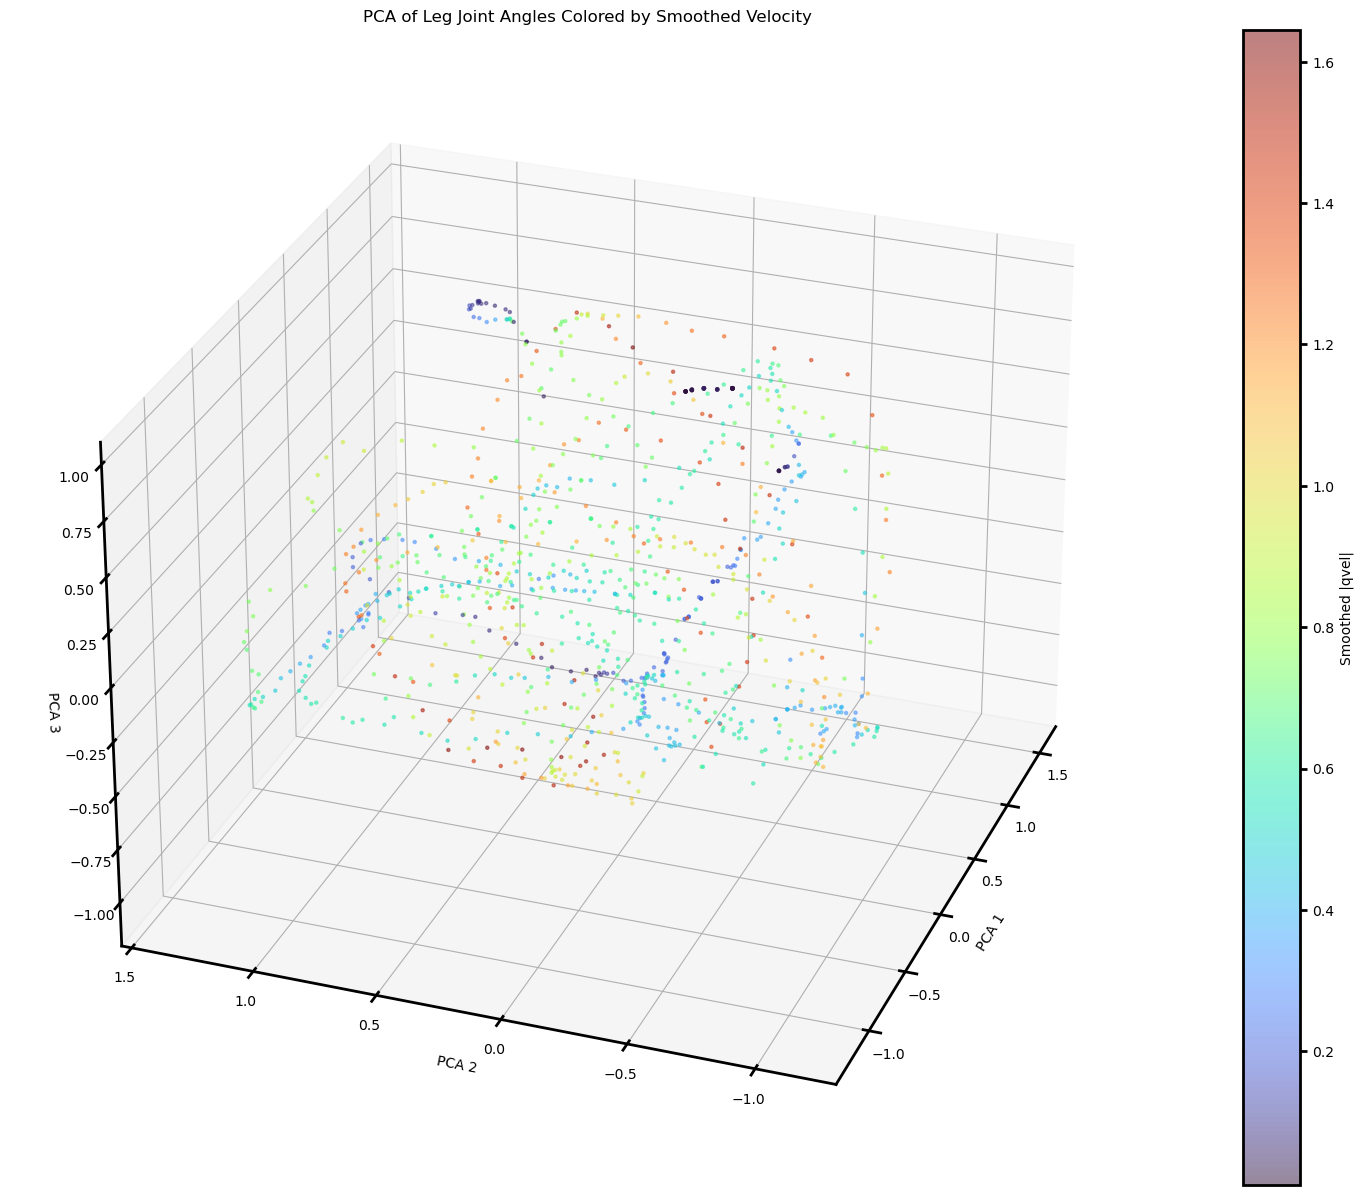

In [75]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
qpos_PCA = pca.fit_transform(qpos_all[:, PCA_idxs])
fig = plt.figure(figsize=(20,15))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(qpos_PCA[1:1000,0], qpos_PCA[1:1000,1], qpos_PCA[1:1000,2], c=qvel_smooth[1:1000], cmap='turbo', s=5
                , alpha=0.5)
plt.colorbar(sc, label='Smoothed |qvel|')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('PCA of Leg Joint Angles Colored by Smoothed Velocity') 
ax.view_init(elev=28, azim=200)

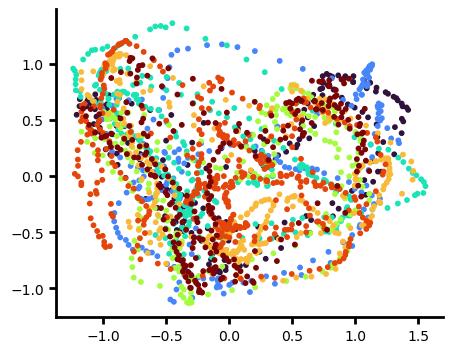

In [85]:
plt.figure(figsize=(5,4))
plt.scatter(qpos_PCA[0:2000,0], qpos_PCA[0:2000,1], c=bout_idx[0:2000], cmap='turbo', s=10)
#plt.plot(pca_df['fnum'].iloc[:205]/0.3, pca_df['PC74'].iloc[:205]
sns.despine()

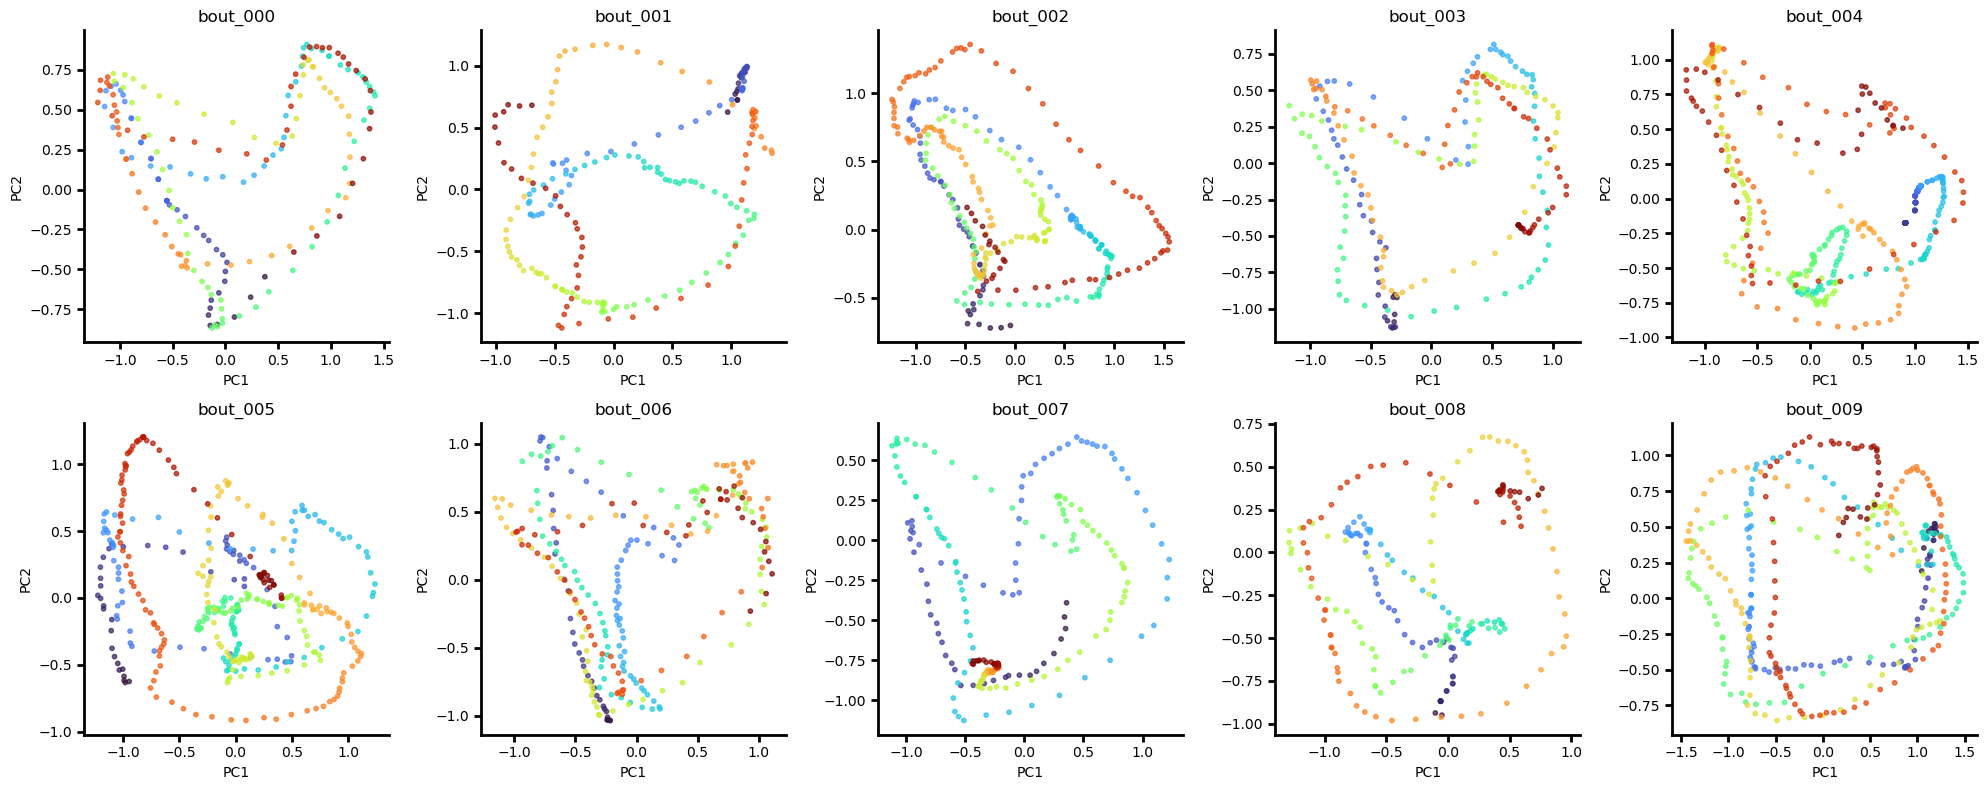

In [86]:
n_bouts = min(10, len(bout_keys))  # Show up to 10 bouts                                                                                                                                             
n_cols = 5                                                                                                                                                                                           
n_rows = (n_bouts + n_cols - 1) // n_cols  # Ceiling division                                                                                                                                        
                                                                                                                                                                                                     
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))                                                                                                                               
axes = axes.flatten()                                                                                                                                                                                
                                                                                                                                                                                                     
# Track cumulative frame index                                                                                                                                                                       
frame_start = 0                                                                                                                                                                                      
for i, key in enumerate(bout_keys[:n_bouts]):                                                                                                                                                        
    n_frames = df_ik[key]['qpos'].shape[0]                                                                                                                                                           
    frame_end = frame_start + n_frames                                                                                                                                                               
                                                                                                                                                                                                     
    axes[i].scatter(qpos_PCA[frame_start:frame_end, 0],                                                                                                                                              
                    qpos_PCA[frame_start:frame_end, 1],                                                                                                                                              
                    c=np.arange(n_frames), cmap='turbo', s=10, alpha=0.7)                                                                                                                            
    axes[i].set_title(f'{key}')                                                                                                                                                                      
    axes[i].set_xlabel('PC1')                                                                                                                                                                        
    axes[i].set_ylabel('PC2')                                                                                                                                                                        
    sns.despine(ax=axes[i])                                                                                                                                                                          
                                                                                                                                                                                                     
    frame_start = frame_end                                                                                                                                                                          
                                                                                                                                                                                                     
# Hide unused subplots                                                                                                                                                                               
for j in range(n_bouts, len(axes)):                                                                                                                                                                  
    axes[j].axis('off')                                                                                                                                                                              
                                                                                                                                                                                                     
plt.tight_layout()      

In [7]:
import cupy
import cuml

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(qpos_all[:, PCA_idxs])
umap = cuml.manifold.UMAP(n_components=6, n_neighbors=15, min_dist=0.01, metric='euclidean', random_state=42)
reduced_data = umap.fit_transform(X_scaled)  # Example with random data

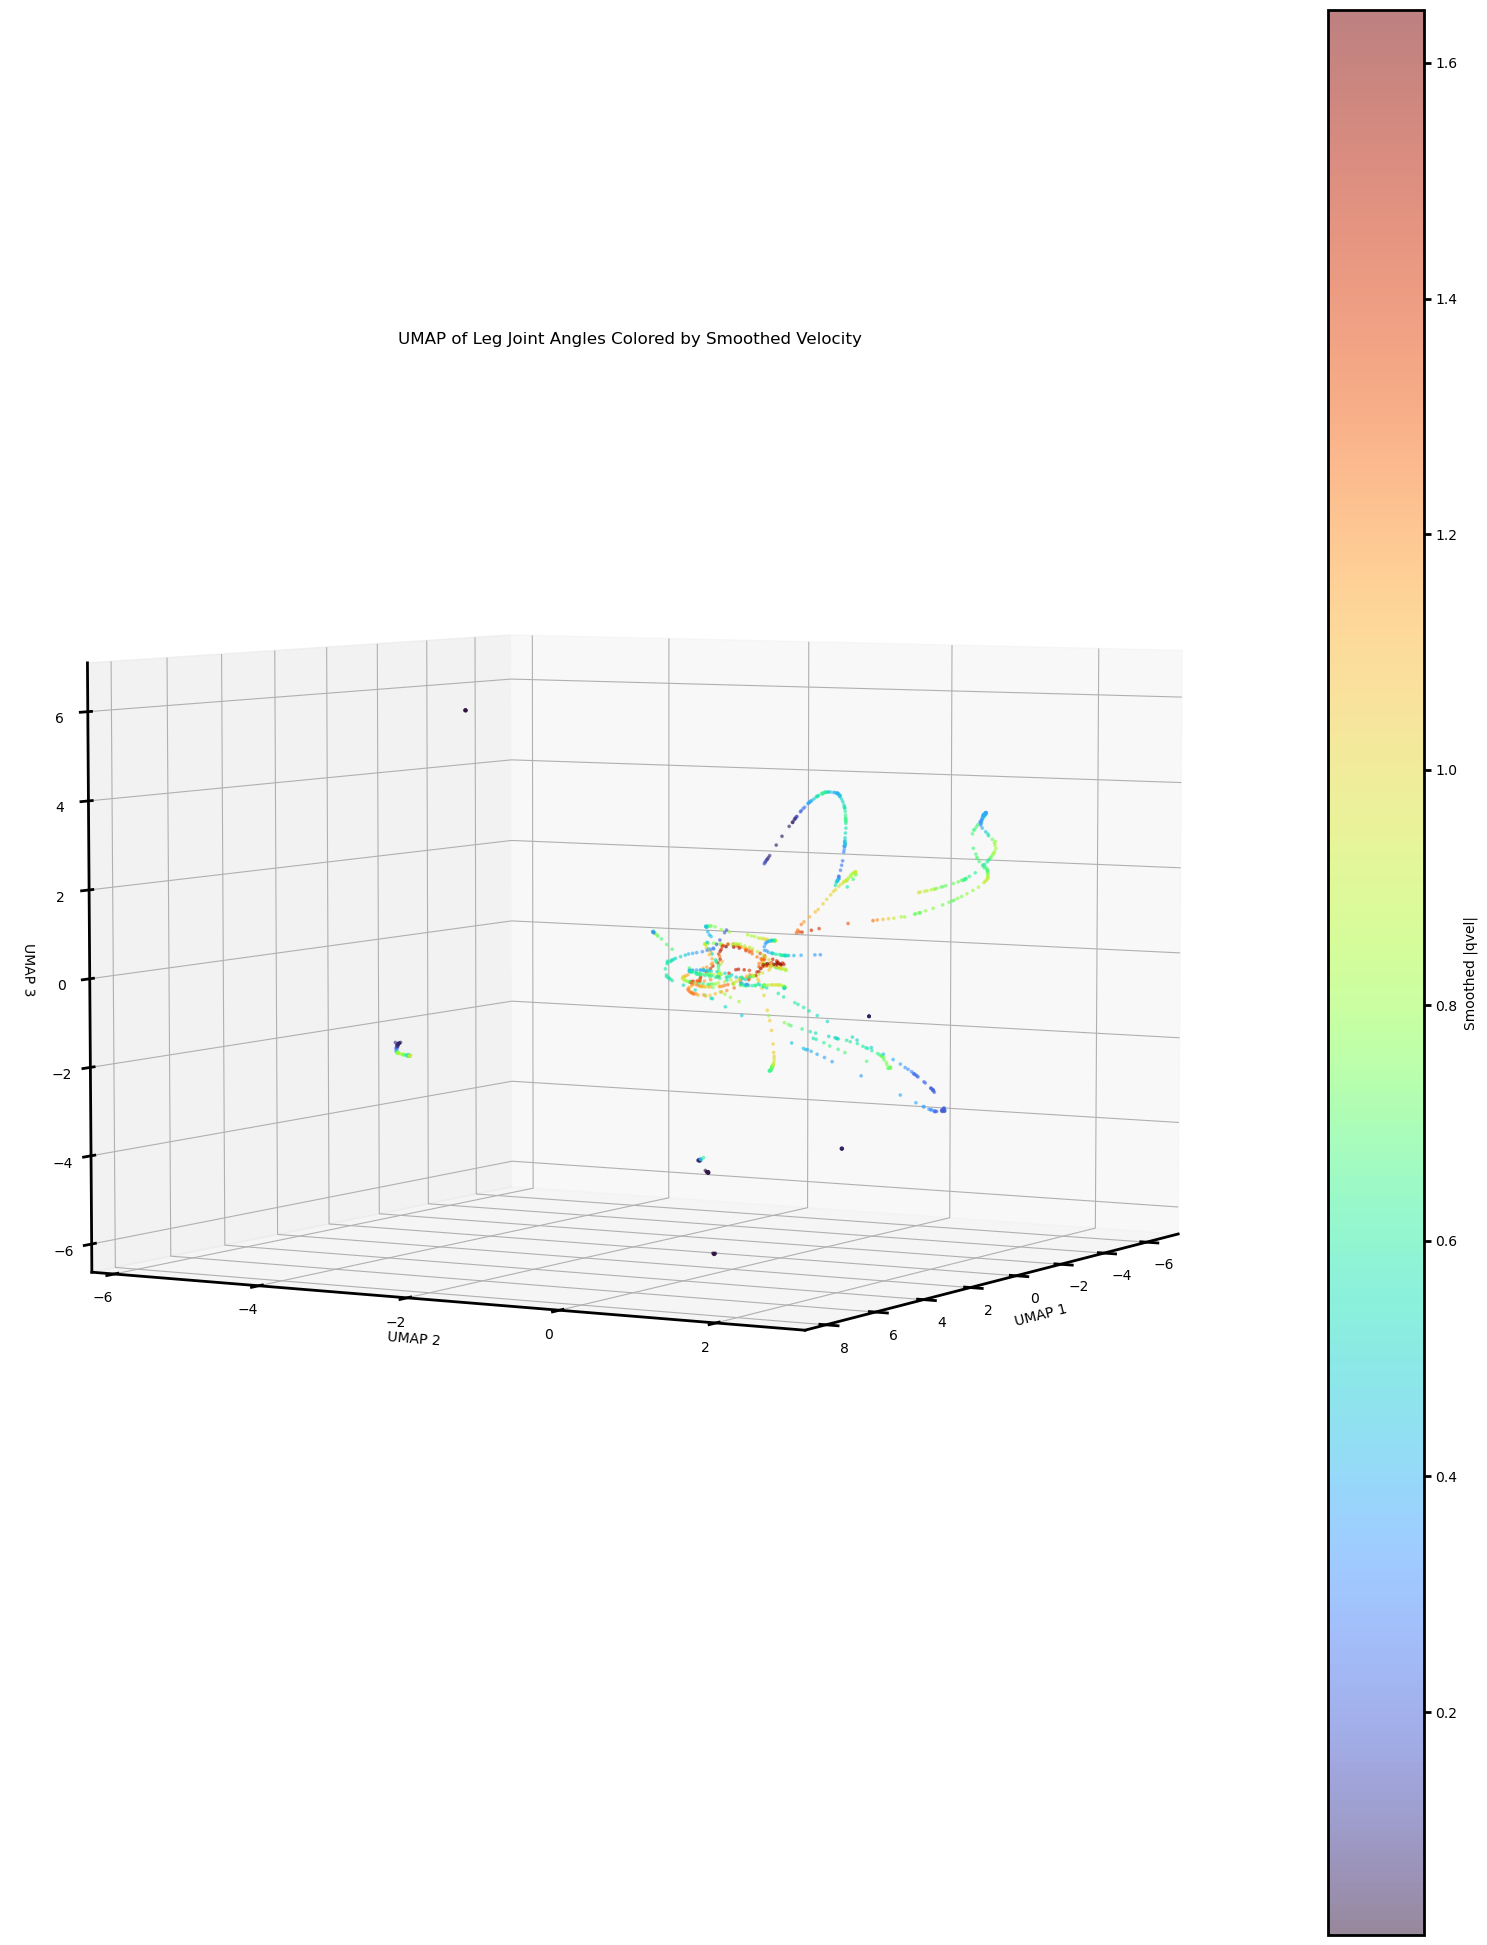

In [56]:
fig = plt.figure(figsize=(20,25))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(reduced_data[0:1000,0], reduced_data[0:1000,1], reduced_data[0:1000,2], c=qvel_smooth[0:1000], cmap='turbo', s=3, alpha=0.5)
plt.colorbar(sc, label='Smoothed |qvel|')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP of Leg Joint Angles Colored by Smoothed Velocity') 
ax.view_init(elev=5, azim=30)
plt.show()

In [9]:
import jax

In [10]:
jax.print_environment_info()

jax:    0.7.2
jaxlib: 0.7.2
numpy:  2.2.6
python: 3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]
device info: NVIDIA RTX 4000 Ada Generation-1, 1 local devices"
process_count: 1
platform: uname_result(system='Linux', node='bench-demo', release='6.5.0-18-generic', version='#18~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb  7 11:40:03 UTC 2', machine='x86_64')
XLA_PYTHON_CLIENT_PREALLOCATE=false
XLA_FLAGS=--xla_gpu_triton_gemm_any=True

$ nvidia-smi
Tue Feb  3 15:05:06 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                    